## Instalação e Imports

In [1]:
!pip install anthropic pymupdf4llm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 85.7 MB/s eta 0:00:00


In [2]:
import math
import json
import asyncio
import asyncio
import time
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymupdf4llm
import nltk
import re
import torch
import plotly.express as px

#Modelos
import google.genai as genai
from openai import AsyncOpenAI
from anthropic import AsyncAnthropic

from enum import Enum
from pathlib import Path
from pydantic import BaseModel, TypeAdapter
from google.colab import data_table
from typing import List, Any, TypeVar, Type
from google.colab import userdata
from abc import ABC, abstractmethod
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    accuracy_score,
    matthews_corrcoef
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Tipos e Variáveis

### Tipos

In [4]:
class AnswerOption(str, Enum):
    CONCORDO_FORTEMENTE = ("concordo_fortemente", 1.0)
    CONCORDO = ("concordo", 0.5)
    NEUTRO_INCERTO = ("neutro_incerto", 0.0)
    DISCORDO = ("discordo", -0.5)
    DISCORDO_FORTEMENTE = ("discordo_fortemente", -1.0)

    def __new__(cls, value: str, score: float):
        obj = str.__new__(cls, value)
        obj._value_ = value
        obj.score = score
        return obj

class Answer(BaseModel):
    id: int
    answer: AnswerOption

class Answers(BaseModel):
    answers: list[Answer]

class Effect(BaseModel):
    econ: int
    dipl: int
    govt: int
    scty: int

    def to_list(self) -> list[int]:
        return list(self.model_dump().values())

class Question(BaseModel):
    id: int
    question: str
    effect: Effect

class Ideology(BaseModel):
    name: str
    stats: Effect

class Result(BaseModel):
    equality: float
    peace: float
    liberty: float
    progress: float

    def to_list(self) -> list[float]:
      return [
          self.equality,
          self.peace,
          self.liberty,
          self.progress
      ]

    def to_dict(self):
        return self.model_dump()

class Score(BaseModel):
    equality: float
    wealth: float
    peace: float
    might: float
    liberty: float
    authority: float
    progress: float
    tradition: float

    def to_list(self) -> list[float]:
        return list(self.model_dump().values())

class Label(BaseModel):
    economic: str
    diplomatic: str
    state: str
    society: str

    def to_list(self) -> list[str]:
        return list(self.model_dump().values())

class Values(BaseModel):
    scores: Score
    labels: Label
    closest_ideology: Ideology | None
    distance_score: float

class ResultadoAnalise(BaseModel):
    estimado: Result
    quiz_total: Result
    quiz_individual: Result
    modelo: str
    texto: str
    nome: str

In [5]:
T = TypeVar("T")

class LLMClient(ABC):
    @abstractmethod
    async def generate(self, prompt: str, response_schema: Type[T]) -> T:
        pass

#### Modelos

In [6]:
class GeminiClient(LLMClient):

    def __init__(self, api_key: str, model: str):
        self.client = genai.Client(api_key=api_key)
        self.model = model

    async def generate(self, prompt: str, response_schema):
        response = await self.client.aio.models.generate_content(
            model=self.model,
            contents=prompt,
            config={
                "response_mime_type": "application/json",
                "response_schema": response_schema,
            },
        )

        return response.parsed

In [7]:
class OpenAIClient(LLMClient):

    def __init__(self, api_key: str, model: str):
        self.client = AsyncOpenAI(api_key=api_key)
        self.model = model

    async def generate(self, prompt: str, response_schema):
        response = await self.client.responses.parse(
            model=self.model,
            input=prompt,
            text_format=response_schema,
        )

        return response.output_parsed

In [8]:
class ClaudeClient(LLMClient):

    def __init__(self, api_key: str, model: str):
        self.client = AsyncAnthropic(api_key=api_key)
        self.model = model

    async def generate(self, prompt: str, response_schema):
        response = await self.client.messages.parse(
            model=self.model,
            max_tokens=4096,
            messages=[
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            output_format=response_schema,
        )

        return response.parsed_output

In [9]:
class MaritacaClient(LLMClient):

    def __init__(self, api_key: str, model: str):
        self.client = AsyncOpenAI(
            api_key=api_key,
            base_url="https://chat.maritaca.ai/api",
        )
        self.model = model

    async def generate(
        self,
        prompt: str,
        response_schema,
    ):
        response = await self.client.responses.parse(
            model=self.model,
            input=prompt,
            text_format=response_schema,
            extra_body={"service_tier": "flex"},
        )

        return response.output_parsed

In [10]:
class OpenRouterClient(LLMClient):

    def __init__(self, api_key: str, model: str):
        self.client = AsyncOpenAI(
            api_key=api_key,
            base_url="https://openrouter.ai/api/v1",
        )
        self.model = model

    async def generate(self, prompt: str, response_schema):
        response = await self.client.responses.parse(
            model=self.model,
            input=prompt,
            text_format=response_schema,
        )

        return response.output_parsed

### Variáveis

In [11]:
def ler_json(caminho):
  with open(caminho, 'r', encoding='utf-8') as arquivo:
    dados = json.load(arquivo)

  return dados

def ler_json_tiptado(caminho: str | Path, tipo: type[T]) -> T:
    adapter = TypeAdapter(tipo)
    caminho = Path(caminho)

    with open(caminho, 'r', encoding='utf-8') as arquivo:
        return adapter.validate_json(arquivo.read())

In [12]:
DRIVE_PATH = '/content/drive/MyDrive/tcc/'
PDF_PATH = DRIVE_PATH + 'pdf/'
TEXTS_PATH = DRIVE_PATH + 'textos/'
PLANO_GOVERNO_PATH = DRIVE_PATH + 'proposta_governo_2026_BR/BR'

IDEOLOGIES_PATH = DRIVE_PATH + 'ideologies.json'
QUESTIONS_PATH = DRIVE_PATH + 'questions.json'
TOTAL_LIST_PATH = DRIVE_PATH + 'lista_total.json'
INDIVIDUAL_LIST_PATH = DRIVE_PATH + 'lista_individual.json'

TEXTO_6X1 = DRIVE_PATH + 'Escala 6x1.txt'

ECON_ARRAY = ["Comunista", "Socialista", "Social", "Centrista", "Mercado", "Capitalista", "Laissez-Faire"]
DIPL_ARRAY = ["Cosmopolita", "Internacionalista", "Pacífico", "Equilibrado", "Patriota", "Nacionalista", "Chauvinista"]
GOVT_ARRAY = ["Anarquista", "Libertário", "Liberal", "Moderado", "Estatal", "Autoritário", "Totalitário"]
SCTY_ARRAY = ["Revolucionário", "Muito Progressista", "Progressista", "Neutro", "Tradicional", "Muito Tradicional", "Reacionário"]

DIPL_SCTY_EXPONENT = 1.73856063

IDEOLOGIES = ler_json_tiptado(IDEOLOGIES_PATH, list[Ideology])
QUESTIONS = ler_json_tiptado(QUESTIONS_PATH, list[Question])

In [13]:
gemini_flash_lite = GeminiClient(
    api_key=userdata.get("GOOGLE_API_KEY_2"),
    model="gemini-3.1-flash-lite",
)

gemini_flash = GeminiClient(
    api_key=userdata.get("GOOGLE_API_KEY_2"),
    model="gemini-3.7-flash",
)

openai_mini = OpenAIClient(
    api_key=userdata.get("OPENAI_API_KEY"),
    model="gpt-5.4-mini",
)

openai_luna = OpenAIClient(
    api_key=userdata.get("OPENAI_API_KEY"),
    model="gpt-5.6-luna",
)

claude_haiku = ClaudeClient(
    api_key=userdata.get("CLAUDE_API_KEY"),
    model="claude-haiku-4-5",
)

claude_sonnet = ClaudeClient(
    api_key=userdata.get("CLAUDE_API_KEY"),
    model="claude-sonnet-4-6",
)

sabia =  MaritacaClient(
        api_key=userdata.get("MARITACA_API_KEY"),
        model="sabia-4",
)

sabiazinho = MaritacaClient(
        api_key=userdata.get("MARITACA_API_KEY"),
        model="sabiazinho-4",
)

open_router_free = OpenRouterClient(
        userdata.get("OPENROUTER_API_KEY"),
        "google/gemma-4-31b-it:free",
)

In [14]:
MODELS = {
    "gemini_flash_lite": gemini_flash_lite,
    "gemini_flash": gemini_flash,
    "openai_mini": openai_mini,
    "openai_luna": openai_luna,
    "claude_haiku": claude_haiku,
    "claude_sonnet": claude_sonnet,
    "sabia": sabia,
    "sabiazinho":sabiazinho,
    "open_router_free": open_router_free
}

In [15]:
TEXTOS_EIXOS = {
  "economic": {
      "equality": "Aqueles com pontuações mais altas de Igualdade acreditam que grandes diferenças econômicas e sociais devem ser reduzidas e que a organização da economia deve favorecer uma distribuição mais equilibrada de riqueza, recursos e oportunidades entre os membros da sociedade. Eles tendem a considerar legítima a utilização de políticas públicas para corrigir desigualdades existentes, apoiando medidas redistributivas, tributação progressiva e maior proteção aos grupos economicamente menos favorecidos. Para essas pessoas, tratar todos de maneira exatamente idêntica nem sempre produz maior igualdade, pois diferenças econômicas anteriores podem exigir tratamentos distintos para que as disparidades sejam efetivamente reduzidas. Em pontuações mais altas, podem defender formas mais amplas de nivelamento econômico, maior propriedade pública ou socialização dos meios de produção, entendendo que determinadas formas de propriedade privada podem produzir ou perpetuar relações de desigualdade. De maneira geral, valorizam uma sociedade em que diferenças de riqueza e poder econômico sejam limitadas e não determinem excessivamente as condições de vida dos indivíduos.",
      "wealth": "Aqueles com pontuações mais altas de Mercados acreditam que indivíduos e empresas devem possuir ampla autonomia para realizar atividades econômicas, celebrar contratos, possuir propriedades e competir entre si. Eles tendem a considerar a iniciativa privada e a concorrência mecanismos importantes para organizar a economia e preferem que grande parte das decisões sobre produção, investimento e consumo seja tomada de maneira descentralizada, em vez de determinada diretamente pelo Estado. Essas pessoas geralmente valorizam a propriedade privada, a liberdade econômica e a possibilidade de cada indivíduo buscar seus próprios interesses dentro de regras jurídicas comuns. Tendem também a desconfiar de formas excessivas de planejamento e controle estatal da economia. Em pontuações mais altas, aproximam-se das concepções de laissez-faire, defendendo intervenção governamental bastante limitada e maior liberdade para o funcionamento do mercado. Isso não significa necessariamente rejeitar toda ação estatal: mesmo dentro da tradição liberal, podem ser aceitas intervenções destinadas a garantir contratos, impedir monopólios, arbitrar conflitos e proteger direitos."
  },
  "diplomatic": {
      "might": "Aqueles com pontuações mais altas de Nação acreditam que a comunidade nacional constitui uma referência política fundamental e que a soberania, a independência e a capacidade de autodeterminação de um povo devem ser preservadas. Eles tendem a possuir forte identificação com o próprio país e a valorizar elementos compartilhados de pertencimento, como história, cultura, língua, costumes, símbolos e instituições nacionais. Essas pessoas costumam considerar importante que as decisões fundamentais de um Estado sejam tomadas por sua própria população, com pouca interferência de outros Estados ou instituições externas. Também tendem a dar maior peso aos interesses nacionais quando estes entram em conflito com objetivos internacionais mais amplos. Em pontuações elevadas, a lealdade à nação pode adquirir prioridade sobre vínculos políticos, ideológicos ou supranacionais, e a unidade e a independência nacionais podem ser vistas como objetivos políticos especialmente importantes. Essa orientação pode favorecer políticas mais centradas na soberania nacional, mas não implica necessariamente militarismo, expansionismo ou hostilidade a outros povos.",
      "peace": "Aqueles com pontuações mais altas de Globo acreditam que os indivíduos fazem parte de uma comunidade humana mais ampla e que as fronteiras nacionais não devem ser o limite principal da cooperação política. Eles tendem a enfatizar os valores, interesses e problemas compartilhados entre diferentes povos e a considerar que diversas questões econômicas, sociais e políticas exigem soluções que ultrapassem a atuação isolada dos Estados. Essas pessoas normalmente apoiam cooperação internacional, integração entre países, instituições multilaterais e formas de direito supranacional. Também tendem a aceitar que determinados aspectos da soberania nacional sejam compartilhados quando isso permite solucionar problemas comuns ou estabelecer instituições políticas mais amplas. Em pontuações mais altas, podem favorecer estruturas federativas ou supranacionais capazes de exercer autoridade acima dos Estados em determinadas áreas. De maneira geral, dão maior importância à solidariedade internacional, à interdependência entre sociedades e à ideia de que a pertença à humanidade pode ter importância política comparável ou superior à pertença exclusiva a uma nação."
  },
  "state": {
      "liberty": "Aqueles com pontuações mais altas de Liberdade acreditam que os indivíduos e grupos devem possuir ampla autonomia para escolher seus próprios valores, opiniões e formas de vida, sem interferência desnecessária do poder político. Eles tendem a apoiar fortes garantias às liberdades civis, incluindo liberdade de expressão, imprensa, reunião, associação e participação política, além da existência de pluralismo social e político. Essas pessoas consideram importante que diferentes ideias, organizações e projetos de vida possam coexistir e competir dentro da sociedade, e normalmente defendem limites jurídicos claros ao poder do Estado. Também tendem a valorizar instituições representativas, opinião pública livre e mecanismos que permitam aos cidadãos questionar e controlar os governantes. Em pontuações mais altas, mostram maior resistência à censura, à vigilância excessiva e às tentativas do Estado de impor aos indivíduos determinada visão moral, política ou social. Para elas, o poder político deve principalmente garantir um espaço no qual cada pessoa possa exercer sua autonomia, desde que respeite os direitos dos demais.",
      "authority": "Aqueles com pontuações mais altas de Autoridade acreditam que a estabilidade da sociedade depende da existência de instituições fortes, hierarquia, disciplina e capacidade efetiva de comando por parte do poder político. Eles tendem a considerar a manutenção da ordem e da coesão social mais importante do que uma ampla autonomia individual em determinadas circunstâncias e aceitam com maior facilidade restrições impostas pelo Estado quando estas são apresentadas como necessárias à segurança ou à estabilidade. Essas pessoas podem favorecer governos com maior concentração de poder, instituições executivas fortes e menor influência de grupos ou organizações capazes de dificultar a execução das decisões governamentais. Em pontuações mais altas, podem considerar legítima uma redução da participação política, da autonomia das instituições representativas e da oposição em benefício de uma direção política mais centralizada. Também apresentam maior aceitação do uso de mecanismos coercitivos para assegurar o cumprimento das decisões. Nos extremos, essa orientação aproxima-se do autoritarismo, caracterizado pela primazia do comando, da hierarquia e da obediência sobre o consenso e a participação."
  },
  "society": {
      "progress": "Aqueles com pontuações mais altas de Progresso acreditam que a sociedade não precisa permanecer limitada pelas instituições e costumes herdados do passado e que os seres humanos são capazes de transformar conscientemente suas condições de vida. Eles tendem a confiar na razão, no conhecimento, na investigação científica e na crítica como instrumentos para avaliar e aperfeiçoar instituições sociais e políticas. Essas pessoas geralmente possuem maior disposição para questionar tradições quando estas são consideradas incompatíveis com novos conhecimentos, valores ou necessidades sociais e costumam enxergar a mudança como uma oportunidade de aperfeiçoamento, e não apenas como uma ameaça à estabilidade. Também atribuem importância à autonomia dos indivíduos para participar do desenvolvimento histórico e influenciar o rumo da sociedade. Em pontuações mais altas, demonstram maior confiança na capacidade humana de reformar profundamente instituições e superar estruturas consideradas injustas, irracionais ou ultrapassadas. Entretanto, progresso não significa simplesmente qualquer mudança ou avanço tecnológico: uma transformação só pode ser considerada progresso quando é avaliada em relação a algum objetivo ou condição considerada melhor do que a anterior.",
      "tradition": "Aqueles com pontuações mais altas de Tradição acreditam que instituições, costumes e valores desenvolvidos historicamente possuem importância própria e não devem ser abandonados simplesmente em favor de novas ideias ou projetos de transformação social. Eles tendem a valorizar continuidade, estabilidade, experiência acumulada e mudanças graduais, demonstrando maior cautela diante de reformas profundas que pretendam reorganizar rapidamente a sociedade a partir de princípios abstratos. Essas pessoas costumam considerar que a ordem social contém práticas e instituições que foram construídas ao longo do tempo e cuja função nem sempre pode ser substituída por planejamento racional. Podem também atribuir maior importância à religião, à moral tradicional, à família, à autoridade e às formas históricas de organização social, embora nenhuma dessas características seja obrigatória isoladamente. Em pontuações mais altas, mostram maior preferência pela preservação das estruturas existentes e maior resistência a transformações sociais radicais. Isso não significa necessariamente rejeitar toda mudança, mas favorecê-la quando ocorre de maneira gradual e preserva elementos considerados fundamentais da ordem social."
  }
}

### Quiz

In [16]:
class Quiz8Values:
    def __init__(self, questions: list[Question], ideologies: list[Ideology]):
        self.questions = questions
        self.ideologies = ideologies
        self.qn = 0
        self.num_questions = len(questions)
        self.answers: list[AnswerOption] = []

        # Arrays de pontuação por pergunta (mesma estrutura do JS)
        self.econ_array = [0.0] * self.num_questions
        self.dipl_array = [0.0] * self.num_questions
        self.govt_array = [0.0] * self.num_questions
        self.scty_array = [0.0] * self.num_questions

        # Cálculo das pontuações máximas possíveis (loop inicial do JS)
        self.max_econ = 0.0
        self.max_dipl = 0.0
        self.max_govt = 0.0
        self.max_scty = 0.0
        self._calculate_max_scores()

    def _calculate_max_scores(self):
        for q in self.questions:
            effect = q.effect
            self.max_econ += abs(effect.econ)
            self.max_dipl += abs(effect.dipl)
            self.max_govt += abs(effect.govt)
            self.max_scty += abs(effect.scty)

    def next_question(self, choice: AnswerOption):
      if self.is_finished():
          raise RuntimeError("Todas as perguntas já foram respondidas.")

      if not isinstance(choice, AnswerOption):
          try:
              choice = AnswerOption(choice)
          except ValueError:
              raise ValueError(f"Opção ({choice}) inválida.")

      self.answers.append(choice)

      mult = choice.score
      effect = self.questions[self.qn].effect

      self.econ_array[self.qn] = mult * effect.econ
      self.dipl_array[self.qn] = mult * effect.dipl
      self.govt_array[self.qn] = mult * effect.govt
      self.scty_array[self.qn] = mult * effect.scty

      self.qn += 1

    def is_finished(self) -> bool:
        return self.qn >= self.num_questions

    @staticmethod
    def calc_score(score: float, max_val: float) -> float:
        if max_val == 0:
            return 50.0

        return (100.0 * (max_val + score)) / (2.0 * max_val)

    def get_results(self) -> Result:
        if not self.is_finished():
            raise RuntimeError("O quiz ainda não foi concluído.")

        # Soma total dos pontos de cada array (equivalente ao reduce no JS)
        final_econ = sum(self.econ_array)
        final_dipl = sum(self.dipl_array)
        final_govt = sum(self.govt_array)
        final_scty = sum(self.scty_array)

        # Retorna o dicionário com as porcentagens idênticas à URL do JS
        return Result(
          equality=self.calc_score(final_econ, self.max_econ),
          peace=self.calc_score(final_dipl, self.max_dipl),
          liberty=self.calc_score(final_govt, self.max_govt),
          progress=self.calc_score(final_scty, self.max_scty)
        )

    @staticmethod
    def set_label(val: float, labels: list[str]) -> str:
        if val > 100 or val < 0:
            return ""
        if val > 90:
            return labels[0]
        if val > 75:
            return labels[1]
        if val > 60:
            return labels[2]
        if val >= 40:
            return labels[3]
        if val >= 25:
            return labels[4]
        if val >= 10:
            return labels[5]
        return labels[6]

    @staticmethod
    def calculate_8values(results: Result, ideologies: list[Ideology]) -> Values:
        equality = results.equality
        peace = results.peace
        liberty = results.liberty
        progress = results.progress

        # Validação simples de entrada
        for name, val in [("equality", equality), ("peace", peace), ("liberty", liberty), ("progress", progress)]:
            if not (0 <= val <= 100):
                raise ValueError(f"O valor de {name} deve estar entre 0 e 100. Recebido: {val}")

        # Cálculo dos lados opostos dos eixos
        wealth = round(100.0 - equality, 1)
        might = round(100.0 - peace, 1)
        authority = round(100.0 - liberty, 1)
        tradition = round(100.0 - progress, 1)

        # Identificação dos rótulos dos eixos
        labels = Label(economic=Quiz8Values.set_label(equality, ECON_ARRAY), diplomatic=Quiz8Values.set_label(peace, DIPL_ARRAY), state=Quiz8Values.set_label(liberty, GOVT_ARRAY), society=Quiz8Values.set_label(progress, SCTY_ARRAY))
        closest_ideology = None
        min_dist = float("inf")

        for item in ideologies:
            dist = (
                math.pow(abs(item.stats.econ - equality), 2) +
                math.pow(abs(item.stats.govt - liberty), 2) +
                math.pow(abs(item.stats.dipl - peace), DIPL_SCTY_EXPONENT) +
                math.pow(abs(item.stats.scty - progress), DIPL_SCTY_EXPONENT)
            )

            if dist < min_dist:
                min_dist = dist
                closest_ideology = item

        scores = Score(equality=equality,wealth=wealth,peace=peace,might=might,liberty=liberty,authority=authority,progress=progress,tradition=tradition)

        return Values(scores=scores,labels=labels,closest_ideology=closest_ideology,distance_score=min_dist)

### Métodos

In [17]:
def ler_respostas(path):
  quizzes = []
  respostas = ler_json(path)

  for resposta in respostas:
    quiz = Quiz8Values(QUESTIONS, IDEOLOGIES)

    for r in resposta:
      quiz.next_question(r)

    quizzes.append(quiz)

  return quizzes

In [18]:
async def individual_questions(
    texto: str,
    llm: LLMClient,
    intervalo_segundos: int = 60,
    max_retries: int = 3,
    retry_delay: int = 10,
):
    quiz = Quiz8Values(QUESTIONS, IDEOLOGIES)

    responses = None

    for tentativa in range(1, max_retries + 1):
        try:
            responses = await AnswerQuestionsIndividuallyModel(
                texto,
                QUESTIONS,
                llm,
                intervalo_segundos=intervalo_segundos,
            )

            break

        except Exception as e:
            print(
                f"Erro ao responder perguntas "
                f"(tentativa {tentativa}/{max_retries}): {e}"
            )

            if tentativa == max_retries:
                raise

            await asyncio.sleep(retry_delay)

    for response in responses:
        if response is not None:
            try:
                quiz.next_question(response.answer)
            except Exception as e:
                print("Erro ao processar resposta:", e)

    return quiz

async def all_questions(texto: str, llm: LLMClient):
    quiz = Quiz8Values(QUESTIONS, IDEOLOGIES)

    response = await AnswerQuestionsModel(
        texto,
        QUESTIONS,
        llm,
    )

    for answer in response.answers:
        quiz.next_question(answer.answer)

    return quiz

#### Prompt

In [19]:
async def AnswerQuestionModel(text:str, question:Question, llm: LLMClient):
  q = question.question
  options = [option.value for option in AnswerOption]

  prompt = f"Com base no conteúdo do texto: '{text}' responda a pergunta: '{q}' e retorne como resposta somente uma das opcoes: ({options}) e nada mais. Não utilize informações externas sobre o autor, partido, organização ou contexto que não estejam presentes no próprio texto"

  return await llm.generate(prompt, Answer)

async def AnswerQuestionsModel(text:str, questions:list[Question], llm: LLMClient):
  q = [question.question for question in questions]
  options = [option.value for option in AnswerOption]

  prompt = f"""Com base no conteúdo do texto: ("{text}") responda as 70 perguntas: ("{q}"). Cada resposta deve ser somente umas das opcoes: ({options}). Não utilize informações externas sobre o autor, partido, organização ou contexto que não estejam presentes no próprio texto"""

  return await llm.generate(prompt, Answers)


async def EstimateResultModel(text:str, llm: LLMClient):
  prompt = f"""
Analise o posicionamento ideológico expresso no texto abaixo segundo os quatro eixos do 8values:

- Igualdade (0 = Mercados, 100 = Igualdade)
- Paz (0 = Força/Nação, 100 = Paz/Globo)
- Liberdade (0 = Autoridade, 100 = Liberdade)
- Progresso (0 = Tradição, 100 = Progresso)

Atribua a cada eixo uma pontuação entre 0 e 100 com base exclusivamente nas ideias, propostas e valores expressos no texto.

Uma pontuação próxima de 50 indica neutralidade, equilíbrio entre os dois lados ou ausência de evidências suficientes para posicionar claramente o texto naquele eixo.

Não utilize informações externas sobre o autor, partido, organização ou contexto que não estejam presentes no próprio texto.

Texto:
{text}
"""

  return await llm.generate(prompt, Result)


In [20]:
async def AnswerQuestionsIndividuallyModel(
    texto: str,
    questions: list[Question],
    llm: LLMClient,
    tamanho_lote: int = 10,
    intervalo_segundos: float = 60.0,
) -> list[Answer | None]:

    respostas = []

    total_lotes = (
        len(questions) + tamanho_lote - 1
    ) // tamanho_lote

    for idx, i in enumerate(
        range(0, len(questions), tamanho_lote),
        start=1,
    ):
        lote = questions[i:i + tamanho_lote]

        print(
            f"[{time.strftime('%H:%M:%S')}] "
            f"Processando lote {idx}/{total_lotes}..."
        )

        async def executar_questao(q: Question):
            try:
                return await AnswerQuestionModel(
                    texto,
                    q,
                    llm,
                )
            except Exception as e:
                print(f"Erro na questão '{q.question}': {e}")
                return None

        resultados_lote = await asyncio.gather(
            *[executar_questao(q) for q in lote]
        )

        respostas.extend(resultados_lote)

        if i + tamanho_lote < len(questions):
            print(
                f"Aguardando {intervalo_segundos}s "
                f"para o próximo lote..."
            )

            await asyncio.sleep(intervalo_segundos)

    return respostas

#### Gráficos

In [21]:
def grafico_resultado(respostas: list[AnswerOption], title: str, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    categorias = list(AnswerOption)

    valores = [
        respostas.count(categoria)
        for categoria in categorias
    ]

    ax.bar(
        range(len(categorias)),
        valores
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Categorias")
    ax.set_ylabel("Quantidade")

    ax.set_xticks(range(len(categorias)))
    ax.set_xticklabels(
        [categoria.value for categoria in categorias],
        rotation=25,
        ha="right",
        fontsize=9
    )

# 2. Gráfico de pares de eixos (Matplotlib com suporte a ax)
def grafico_scores(scores, labels, titulo, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    pairs = [
        ("equality", "wealth"),
        ("peace", "might"),
        ("liberty", "authority"),
        ("progress", "tradition")
    ]

    values_1 = [scores[a] for a, _ in pairs]
    values_2 = [scores[b] for _, b in pairs]

    x = np.arange(len(pairs))
    width = 0.35

    bars1 = ax.bar(x - width/2, values_1, width, label="Esquerda/Prog")
    bars2 = ax.bar(x + width/2, values_2, width, label="Direita/Trad")

    # Valores numéricos em cima de cada barra
    ax.bar_label(bars1, fmt="%.1f", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.1f", padding=3, fontsize=8)

    # Rótulo da ideologia/classificação acima de cada par
    for i, label in enumerate(labels):
        ax.text(
            x[i],
            108,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_ylim(0, 125)  # Aumentado levemente para dar espaço aos rótulos superiores
    ax.set_xticks(x)
    ax.set_xticklabels([
        "Igualdade × Fortuna",
        "Paz × Poder",
        "Liberdade × Autoridade",
        "Progresso × Tradição"
    ], rotation=15, ha="right", fontsize=9)

    ax.set_ylabel("Score (%)")
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# 3. Gráfico Radar (Plotly - já renderiza centralizado/unificado)
eixos = ['Eixo Econômico', 'Eixo Diplomático', 'Eixo Civil', 'Eixo Social']

def comparar_resultados(resultado_1, resultado_2, name_1, name_2, titulo_geral='Comparativo de Perfil Político'):
    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=resultado_1,
        theta=eixos,
        fill='toself',
        name=name_1,
        fillcolor='rgba(31, 119, 180, 0.35)',
        line=dict(color='rgb(31, 119, 180)', width=2)
    ))

    fig.add_trace(go.Scatterpolar(
        r=resultado_2,
        theta=eixos,
        fill='toself',
        name=name_2,
        fillcolor='rgba(255, 127, 14, 0.35)',
        line=dict(color='rgb(255, 127, 14)', width=2)
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 100]
            )
        ),
        title=f'{titulo_geral} - Radar Politico',
        showlegend=True
    )

    fig.show()

In [22]:
def mostrar_respostas(quiz_total):
  dados = {
      "Perguntas": [q.question for q in QUESTIONS],
      "Respostas": quiz_total.answers
  }

  df = pd.DataFrame(dados)

  data_table.enable_dataframe_formatter()

  display(df)

In [23]:
def processar_e_comparar(quiz_ind: Quiz8Values, quiz_tot:Quiz8Values, titulo:str, questions_list: list[Question]):
    print(f"\n=======================================================")
    print(f"            ANÁLISE: {titulo.upper()}")
    print(f"=======================================================\n")

    # 1. Tabela Comparativa de Respostas
    dados = {
        "Perguntas": [q.question for q in questions_list],
        "Resposta Individual": quiz_ind.answers,
        "Resposta Total": quiz_tot.answers
    }
    df = pd.DataFrame(dados)

    # Formatação se estiver no IPython/Jupyter
    try:
        data_table.enable_dataframe_formatter()
    except NameError:
        pass
    display(df)

    # 2. LINHA 1: Gráficos de Distribuição de Respostas Lado a Lado
    fig1, (ax1_tot, ax1_ind) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    grafico_resultado(quiz_tot.answers, f"Distribuição de Respostas - Total ({titulo})", ax=ax1_tot)
    grafico_resultado(quiz_ind.answers, f"Distribuição de Respostas - Individual ({titulo})", ax=ax1_ind)
    plt.tight_layout()
    plt.show()

    # Cálculo dos valores
    t_result = quiz_tot.get_results()
    i_result = quiz_ind.get_results()
    t_values = quiz_tot.calculate_8values(t_result, IDEOLOGIES)
    i_values = quiz_ind.calculate_8values(i_result, IDEOLOGIES)

    # 3. LINHA 2: Gráficos de Scores Lado a Lado
    fig2, (ax2_tot, ax2_ind) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    grafico_scores(t_values.scores.model_dump(), t_values.labels.to_list(), f"Scores Total ({titulo})", ax=ax2_tot)
    grafico_scores(i_values.scores.model_dump(), i_values.labels.to_list(), f"Scores Individual ({titulo})", ax=ax2_ind)
    plt.tight_layout()
    plt.show()

    # 4. LINHA 3: Gráfico Radar de Comparação Direta (Plotly)
    comparar_resultados(
        t_result.to_list(),
        i_result.to_list(),
        'Total',
        'Individual',
        titulo_geral=titulo
    )

In [24]:
def nuvem_lexical(texto, title):
  stopwords_pt = set(stopwords.words('portuguese'))
  nuvem = WordCloud(width=800, height=400, background_color="white",stopwords=stopwords_pt).generate(texto)

  plt.figure(figsize=(10, 5))
  plt.imshow(nuvem, interpolation="bilinear")
  plt.title(title)
  plt.axis("off")
  plt.show()

## Testes

In [ ]:
with open(TEXTO_6X1, "r", encoding="utf-8") as f:
    texto = f.read()

In [ ]:
tp_textos = []

In [ ]:
for arquivo in Path(PDF_PATH).glob("*.pdf"):
  md = pymupdf4llm.to_markdown(arquivo, header=False, footer=False, use_ocr=False)
  txt = pymupdf4llm.to_text(arquivo, header=False, footer=False, use_ocr=False)
  filename = Path(arquivo).name

  tp_textos.append((filename, md, txt))

### Teste tipo de texto: MD x TXT

In [ ]:
resultados_tp_textos = []
modelo = 'gemini_flash_lite'

In [ ]:
for name, md, txt in tp_textos:
  estimado_md = await EstimateResultModel(md, llm=MODELS[modelo])
  estimado_txt = await EstimateResultModel(txt, llm=MODELS[modelo])

  resultado = {
    "name":name,
    "estimado_md": estimado_md,
    "estimado_txt": estimado_txt
  }

  resultados_tp_textos.append(resultado)

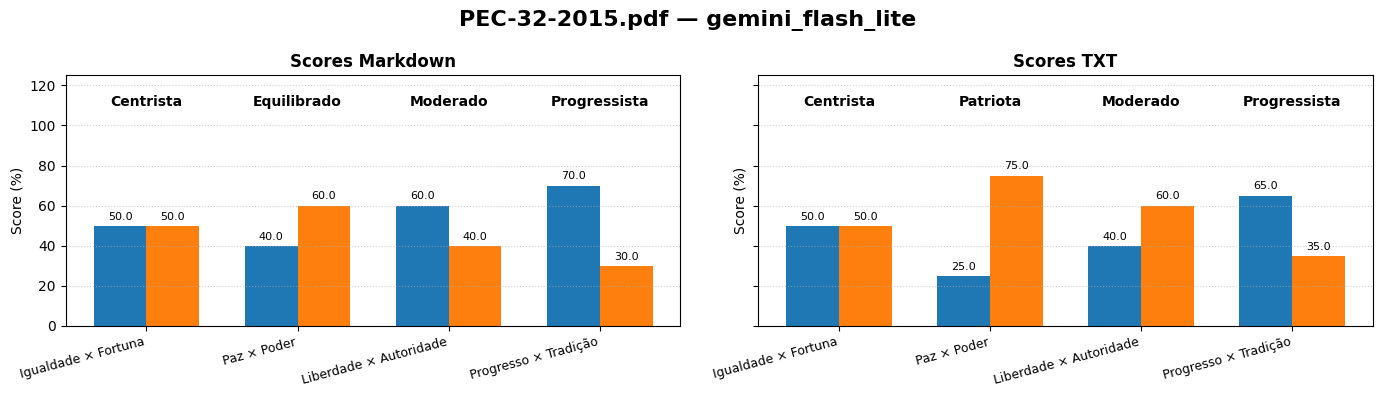

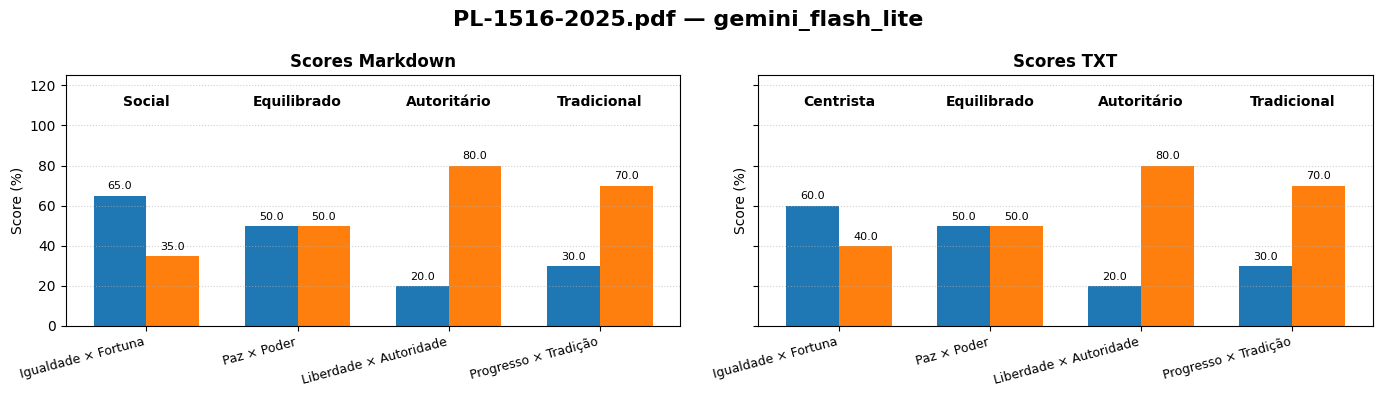

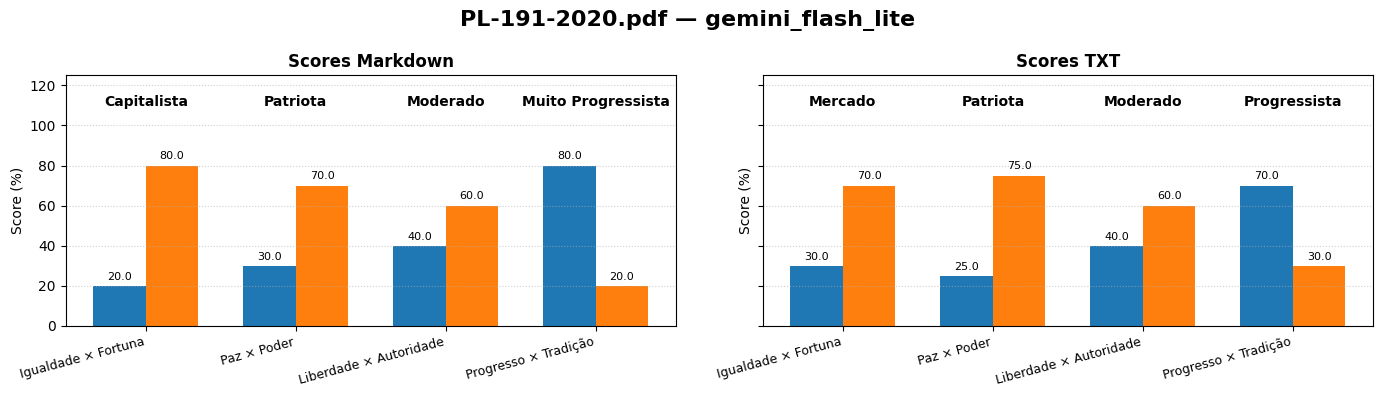

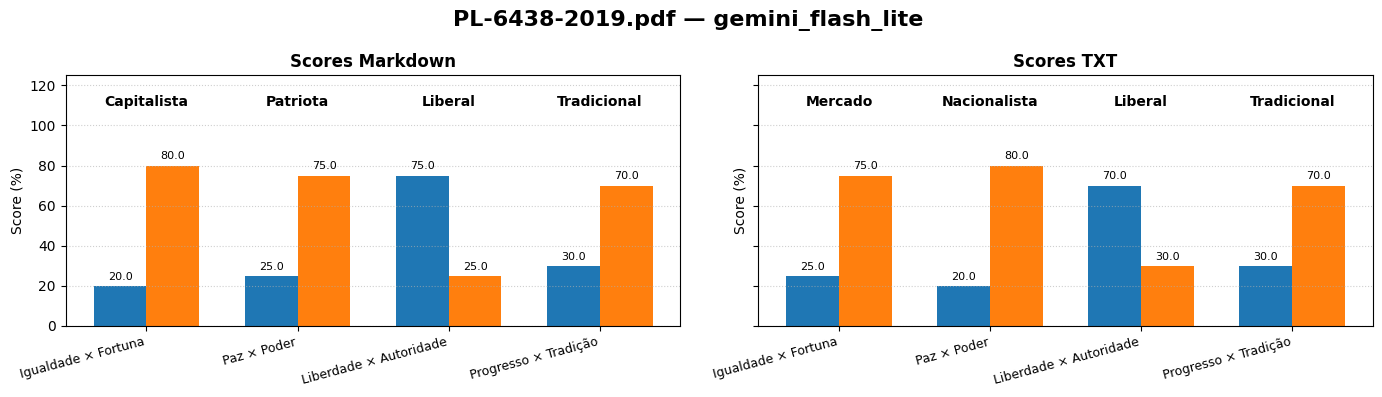

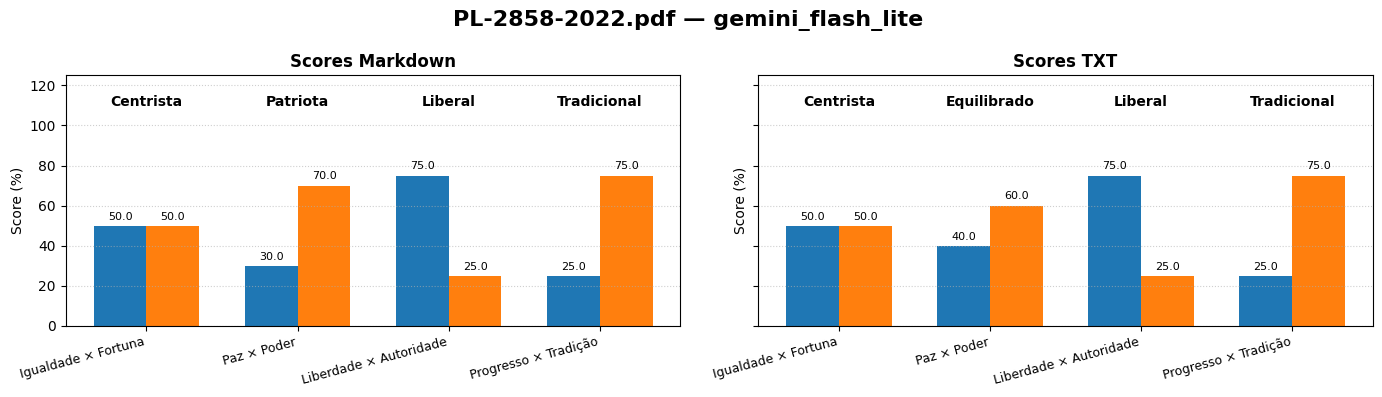

In [ ]:
for r in resultados_tp_textos:
  nome = r["name"]

  values_md = Quiz8Values.calculate_8values(r["estimado_md"], IDEOLOGIES)
  values_txt = Quiz8Values.calculate_8values(r["estimado_txt"], IDEOLOGIES)

  fig1, (ax1_md, ax1_txt) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

  grafico_scores(values_md.scores.model_dump(), values_md.labels.to_list(), f"Scores Markdown", ax1_md)
  grafico_scores(values_txt.scores.model_dump(), values_txt.labels.to_list(), f"Scores TXT", ax1_txt)

  fig1.suptitle(
      f"{nome} — {modelo}",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout()
  plt.show()

### Teste estabilidade

In [ ]:
name, md, txt = tp_textos[0]
teste_LLM = []
modelos = ["gemini_flash_lite", "gemini_flash", "openai_mini", "openai_luna", "sabia", "sabiazinho"]

In [ ]:
for modelo in modelos:
  for i in range(0,10):

    inicio = time.perf_counter()
    estimado_md = await EstimateResultModel(md, llm=MODELS[modelo])
    tempo_md = time.perf_counter() - inicio

    inicio = time.perf_counter()
    estimado_txt = await EstimateResultModel(txt, llm=MODELS[modelo])
    tempo_txt = time.perf_counter() - inicio


    resultado = {
      "name":name,
      "execucao": i + 1,
      "modelo": modelo,
      "estimado_md": estimado_md,
      "tempo_md": tempo_md,
      "tempo_txt":tempo_txt,
      "estimado_txt": estimado_txt
    }

    teste_LLM.append(resultado)

In [ ]:
print(teste_LLM)

[{'name': 'PEC-32-2015.pdf', 'execucao': 1, 'modelo': 'gemini_flash_lite', 'estimado_md': Result(equality=50.0, peace=30.0, liberty=70.0, progress=60.0), 'tempo_md': 2.3676047530002506, 'tempo_txt': 0.655413506000059, 'estimado_txt': Result(equality=50.0, peace=25.0, liberty=40.0, progress=70.0)}, {'name': 'PEC-32-2015.pdf', 'execucao': 2, 'modelo': 'gemini_flash_lite', 'estimado_md': Result(equality=50.0, peace=30.0, liberty=40.0, progress=65.0), 'tempo_md': 0.587924848000057, 'tempo_txt': 0.874486399000034, 'estimado_txt': Result(equality=50.0, peace=30.0, liberty=70.0, progress=65.0)}, {'name': 'PEC-32-2015.pdf', 'execucao': 3, 'modelo': 'gemini_flash_lite', 'estimado_md': Result(equality=50.0, peace=40.0, liberty=45.0, progress=60.0), 'tempo_md': 0.6214696399997592, 'tempo_txt': 0.869894836000185, 'estimado_txt': Result(equality=50.0, peace=30.0, liberty=40.0, progress=70.0)}, {'name': 'PEC-32-2015.pdf', 'execucao': 4, 'modelo': 'gemini_flash_lite', 'estimado_md': Result(equality=5

In [ ]:
EIXOS = ["equality", "peace", "liberty", "progress"]

dados = []

for r in teste_LLM:
    md = r["estimado_md"]
    txt = r["estimado_txt"]

    dados.append({
        "name": r["name"],
        "execucao": r["execucao"],
        "modelo": r["modelo"],
        "equality_md": md.equality,
        "peace_md": md.peace,
        "liberty_md": md.liberty,
        "progress_md": md.progress,
        "tempo_md": r["tempo_md"],
        "equality_txt": txt.equality,
        "peace_txt": txt.peace,
        "liberty_txt": txt.liberty,
        "progress_txt": txt.progress,
        "tempo_txt": r["tempo_txt"],
    })

df = pd.DataFrame(dados)

display(df)

,name,execucao,modelo,equality_md,peace_md,liberty_md,progress_md,tempo_md,equality_txt,peace_txt,liberty_txt,progress_txt,tempo_txt
0,PEC-32-2015.pdf,1,gemini_flash_lite,50.0,30.0,70.0,60.0,2.367605,50.0,25.0,40.0,70.0,0.655414
1,PEC-32-2015.pdf,2,gemini_flash_lite,50.0,30.0,40.0,65.0,0.587925,50.0,30.0,70.0,65.0,0.874486
2,PEC-32-2015.pdf,3,gemini_flash_lite,50.0,40.0,45.0,60.0,0.621470,50.0,30.0,40.0,70.0,0.869895
3,PEC-32-2015.pdf,4,gemini_flash_lite,50.0,40.0,65.0,70.0,10.014801,50.0,40.0,40.0,65.0,0.934162
4,PEC-32-2015.pdf,5,gemini_flash_lite,50.0,40.0,70.0,65.0,15.658972,50.0,40.0,60.0,65.0,0.937104
5,PEC-32-2015.pdf,6,gemini_flash_lite,50.0,40.0,60.0,65.0,1.507227,50.0,30.0,40.0,70.0,0.871779
6,PEC-32-2015.pdf,7,gemini_flash_lite,50.0,30.0,70.0,65.0,15.352108,50.0,35.0,40.0,70.0,0.823558
7,PEC-32-2015.pdf,8,gemini_flash_lite,50.0,30.0,60.0,75.0,0.629777,50.0,40.0,40.0,60.0,0.627391
8,PEC-32-2015.pdf,9,gemini_flash_lite,50.0,30.0,40.0,65.0,0.692633,40.0,30.0,70.0,70.0,0.621877
9,PEC-32-2015.pdf,10,gemini_flash_lite,50.0,40.0,60.0,70.0,0.747845,50.0,30.0,40.0,70.0,0.819517


##### Média e desvio padrão das pontuações

In [ ]:
estatisticas = []

for modelo, grupo in df.groupby("modelo"):

    for formato in ["md", "txt"]:

        linha = {
            "modelo": modelo,
            "formato": formato
        }

        for eixo in EIXOS:
            valores = grupo[f"{eixo}_{formato}"]

            linha[f"{eixo}_media"] = valores.mean()
            linha[f"{eixo}_std"] = valores.std()

        estatisticas.append(linha)

df_estatisticas = pd.DataFrame(estatisticas)

df_estatisticas.round(2)

,modelo,formato,equality_media,equality_std,peace_media,peace_std,liberty_media,liberty_std,progress_media,progress_std
0,gemini_flash,md,50.0,0.00,47.0,3.50,47.2,4.54,65.5,8.32
1,gemini_flash,txt,50.0,0.00,48.3,3.33,45.2,4.61,60.6,5.72
2,gemini_flash_lite,md,50.0,0.00,35.0,5.27,58.0,12.06,66.0,4.59
3,gemini_flash_lite,txt,49.0,3.16,33.0,5.37,48.0,13.17,67.5,3.54
4,openai_luna,md,52.8,2.49,32.1,6.24,66.0,3.33,77.2,2.25
5,openai_luna,txt,54.7,2.91,36.7,6.04,67.0,2.67,80.1,3.87
6,openai_mini,md,31.8,5.49,33.1,6.61,39.5,11.60,70.2,5.18
7,openai_mini,txt,40.0,13.54,37.0,8.15,29.9,4.51,71.3,4.92
8,sabia,md,50.0,0.00,50.0,0.00,67.0,3.50,72.5,3.54
9,sabia,txt,48.0,4.22,51.0,3.16,68.5,3.37,75.5,4.97


##### Estabilidade dos modelos

In [ ]:
estabilidade = []

for modelo, grupo in df.groupby("modelo"):

    for formato in ["md", "txt"]:

        desvios = [
            grupo[f"{eixo}_{formato}"].std()
            for eixo in EIXOS
        ]

        estabilidade.append({
            "modelo": modelo,
            "formato": formato,
            "std_medio": np.mean(desvios)
        })

df_estabilidade = pd.DataFrame(estabilidade)

df_estabilidade = (
    df_estabilidade
    .sort_values("std_medio")
    .reset_index(drop=True)
)

df_estabilidade.round(2)

,modelo,formato,std_medio
0,sabia,md,1.76
1,gemini_flash,txt,3.42
2,openai_luna,md,3.58
3,openai_luna,txt,3.87
4,sabia,txt,3.93
5,gemini_flash,md,4.09
6,gemini_flash_lite,md,5.48
7,gemini_flash_lite,txt,6.31
8,sabiazinho,md,6.51
9,openai_mini,md,7.22


In [ ]:
estabilidade_geral = (
    df_estabilidade
    .groupby("modelo")["std_medio"]
    .mean()
    .sort_values()
    .reset_index()
)

estabilidade_geral.round(2)

,modelo,std_medio
0,sabia,2.84
1,openai_luna,3.72
2,gemini_flash,3.75
3,gemini_flash_lite,5.90
4,sabiazinho,6.94
5,openai_mini,7.50


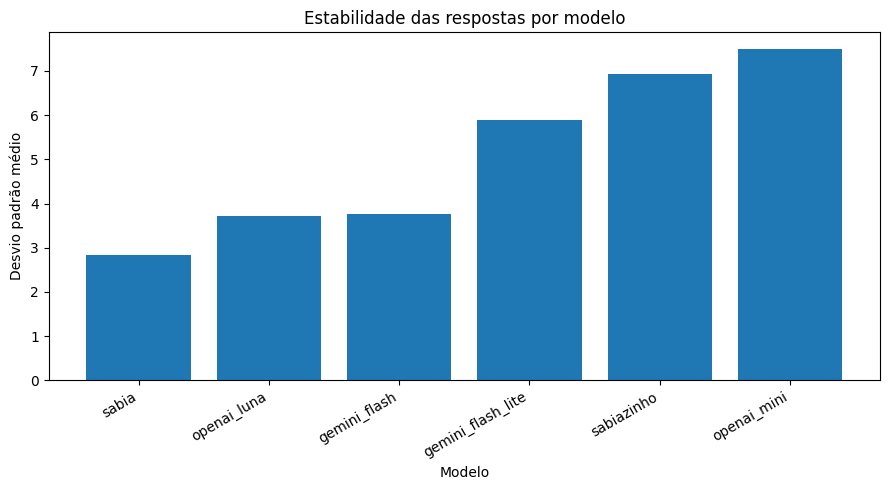

In [ ]:
grafico = estabilidade_geral.sort_values("std_medio")

plt.figure(figsize=(9, 5))

plt.bar(
    grafico["modelo"],
    grafico["std_medio"]
)

plt.ylabel("Desvio padrão médio")
plt.xlabel("Modelo")
plt.title("Estabilidade das respostas por modelo")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

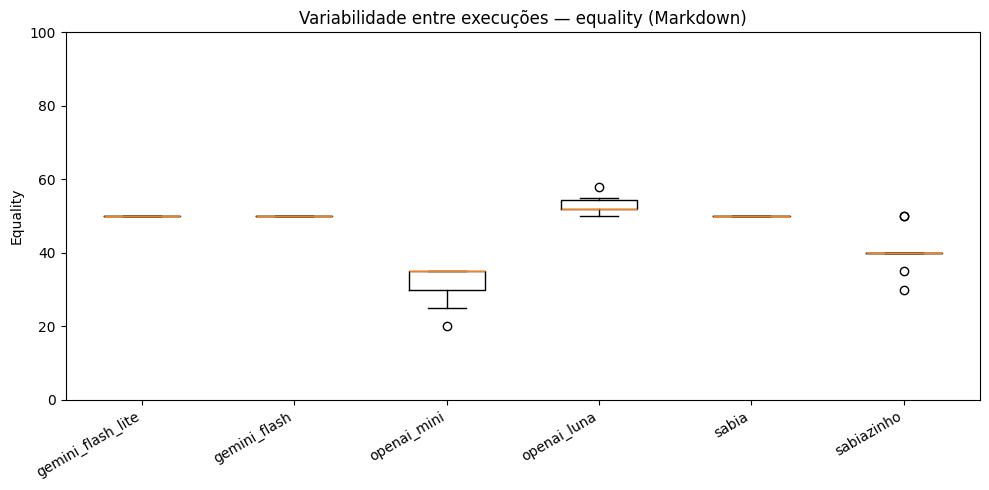

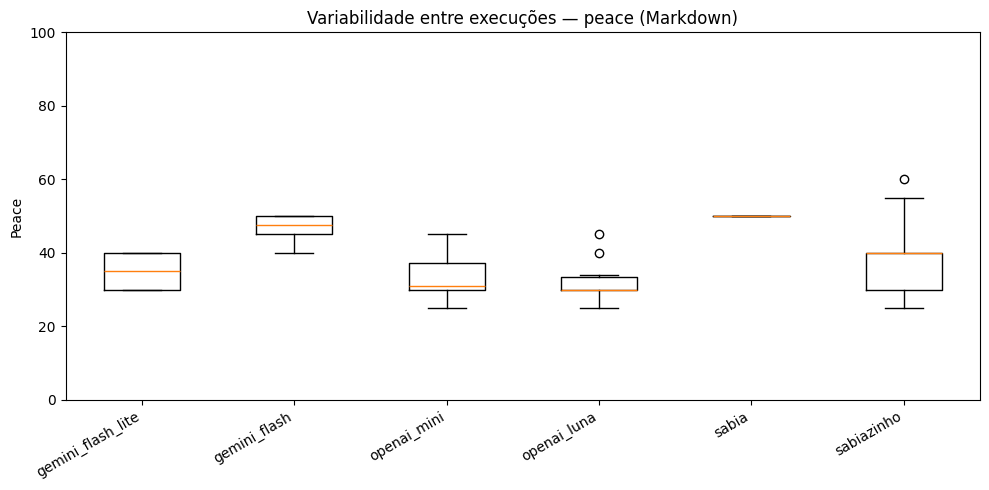

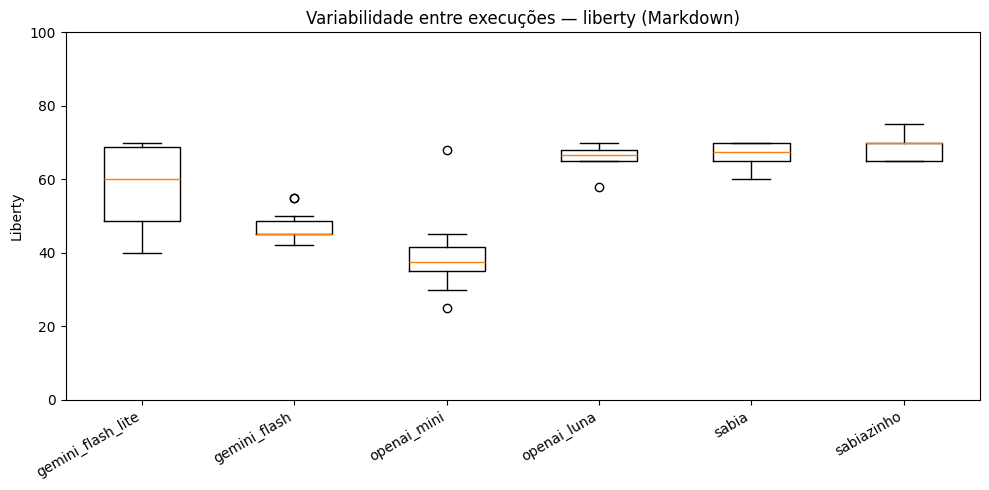

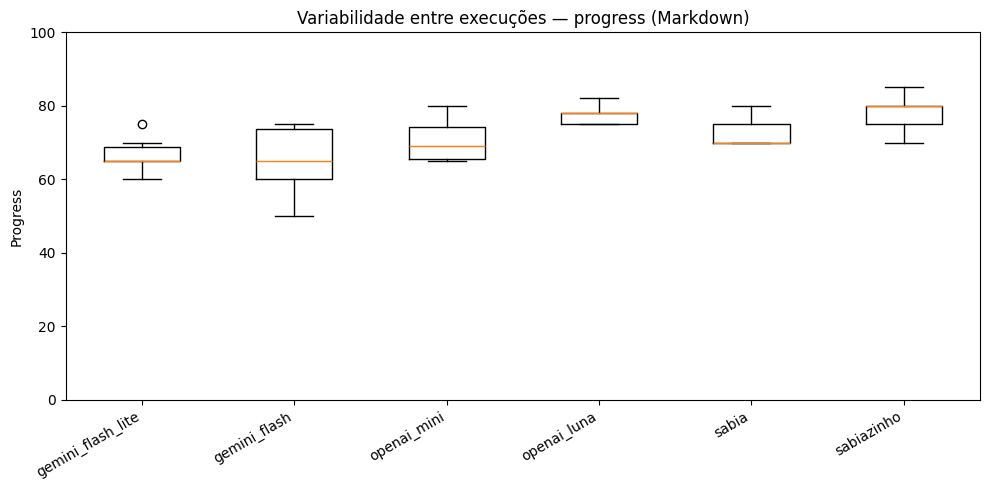

In [ ]:
for eixo in EIXOS:

    fig, ax = plt.subplots(figsize=(10, 5))

    dados = [
        df.loc[df["modelo"] == modelo, f"{eixo}_md"]
        for modelo in modelos
    ]

    ax.boxplot(
        dados,
        tick_labels=modelos
    )

    ax.set_ylim(0, 100)

    ax.set_ylabel(eixo.capitalize())
    ax.set_title(
        f"Variabilidade entre execuções — {eixo} (Markdown)"
    )

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

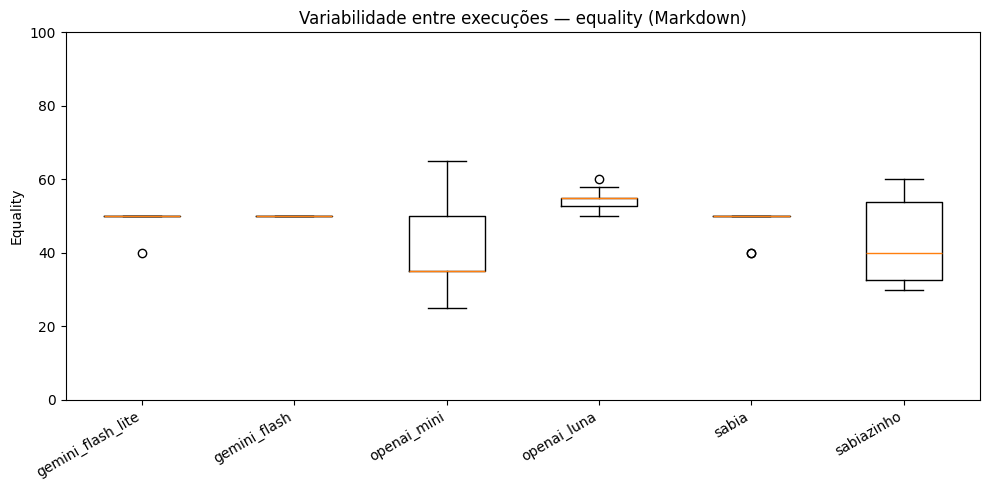

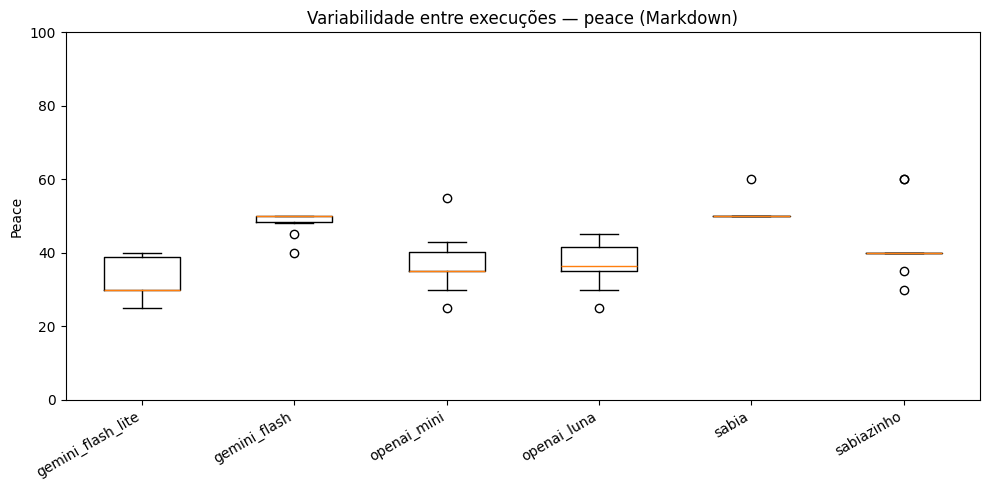

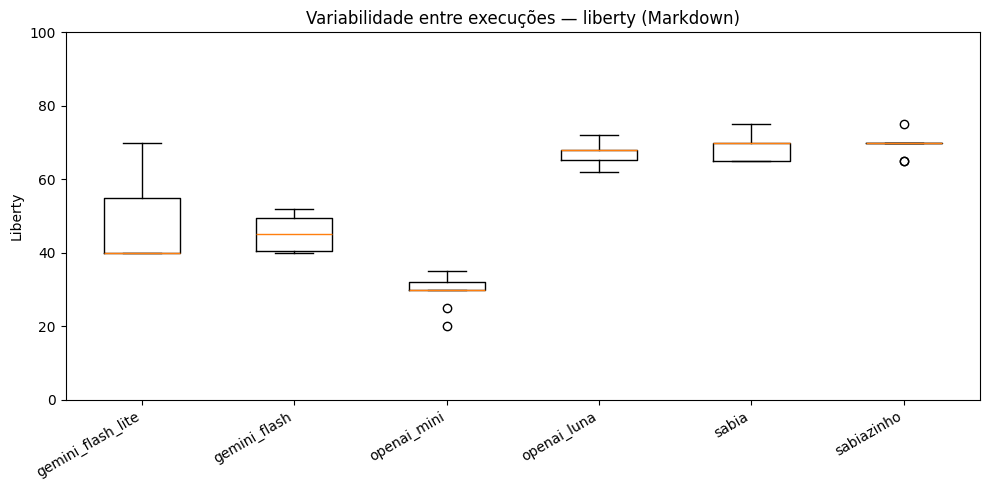

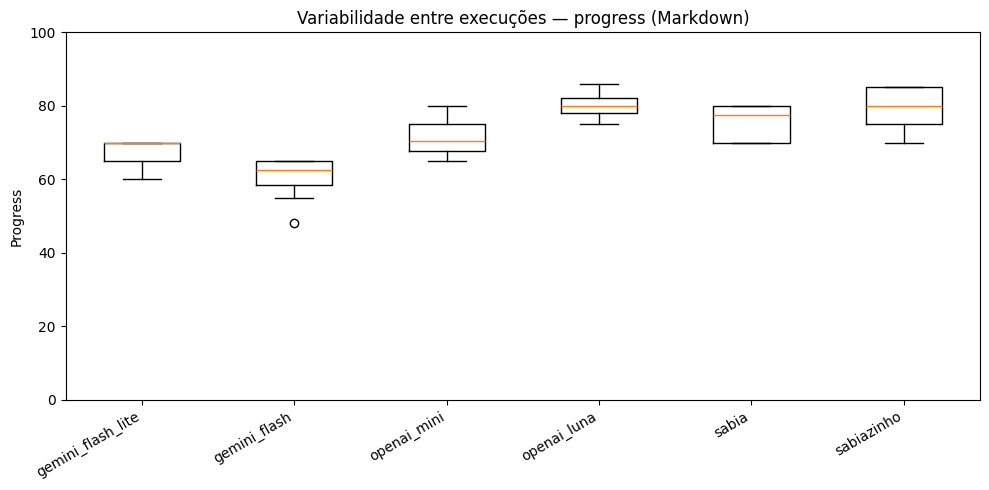

In [ ]:
for eixo in EIXOS:

    fig, ax = plt.subplots(figsize=(10, 5))

    dados = [
        df.loc[df["modelo"] == modelo, f"{eixo}_txt"]
        for modelo in modelos
    ]

    ax.boxplot(
        dados,
        tick_labels=modelos
    )

    ax.set_ylim(0, 100)

    ax.set_ylabel(eixo.capitalize())
    ax.set_title(
        f"Variabilidade entre execuções — {eixo} (Markdown)"
    )

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

##### Markdown × TXT

In [ ]:
for eixo in EIXOS:
    df[f"diff_{eixo}"] = abs(
        df[f"{eixo}_md"] - df[f"{eixo}_txt"]
    )

In [ ]:
diferenca_formato = (
    df
    .groupby("modelo")[
        [f"diff_{eixo}" for eixo in EIXOS]
    ]
    .mean()
)

diferenca_formato["diferenca_media"] = (
    diferenca_formato.mean(axis=1)
)

diferenca_formato = (
    diferenca_formato
    .sort_values("diferenca_media")
)

diferenca_formato.round(2)

,diff_equality,diff_peace,diff_liberty,diff_progress,diferenca_media
modelo,,,,,
sabia,2.0,1.0,2.5,5.0,2.62
gemini_flash,0.0,2.7,5.0,5.9,3.40
openai_luna,2.9,9.6,3.2,2.9,4.65
gemini_flash_lite,1.0,5.0,22.0,5.5,8.38
sabiazinho,11.5,12.5,3.5,7.0,8.62
openai_mini,12.2,10.1,11.6,5.7,9.90


In [ ]:
medias = []

for modelo, grupo in df.groupby("modelo"):
    for eixo in EIXOS:

        medias.append({
            "modelo": modelo,
            "eixo": eixo,
            "md": grupo[f"{eixo}_md"].mean(),
            "txt": grupo[f"{eixo}_txt"].mean()
        })

df_medias = pd.DataFrame(medias)

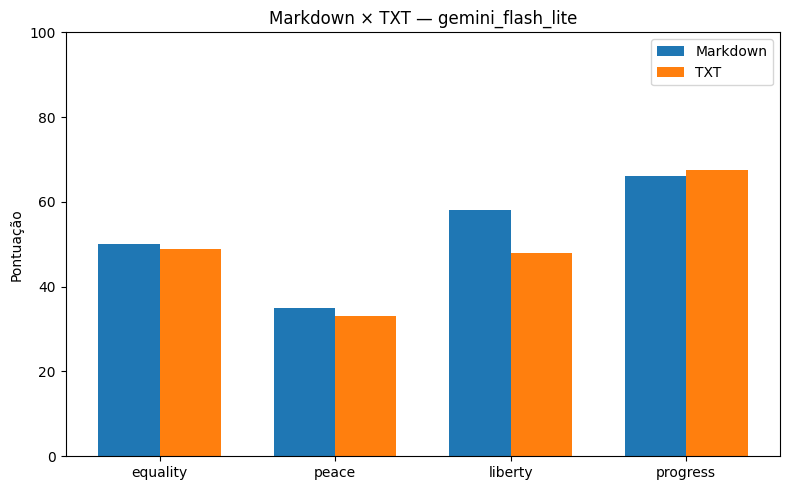

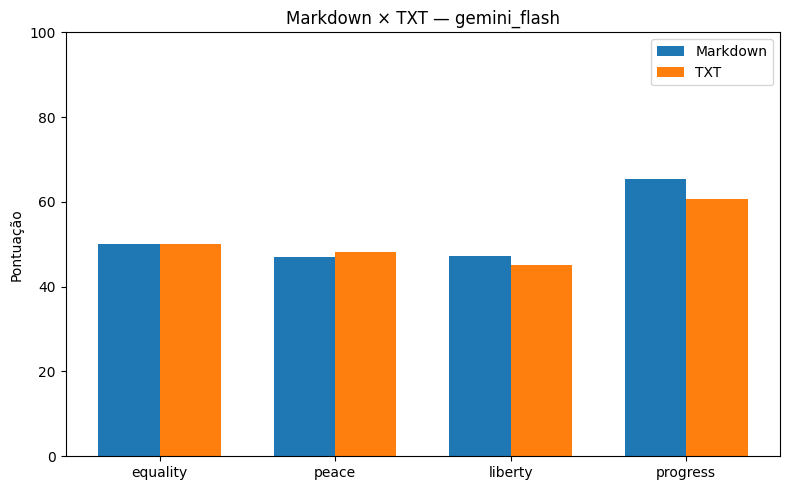

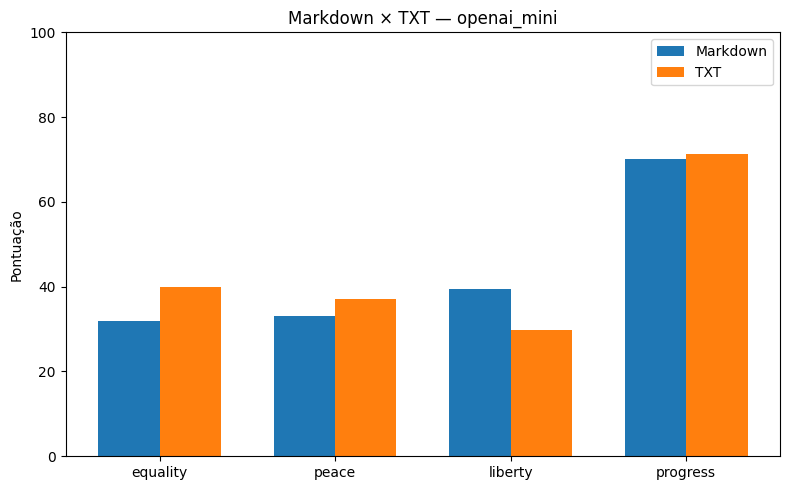

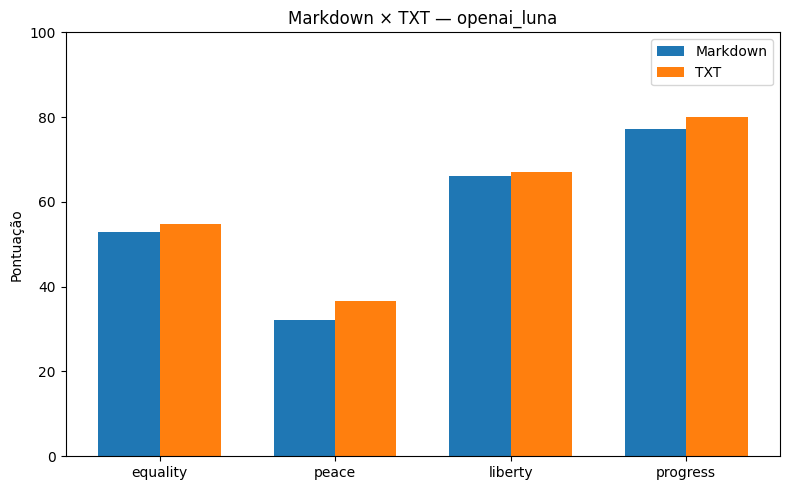

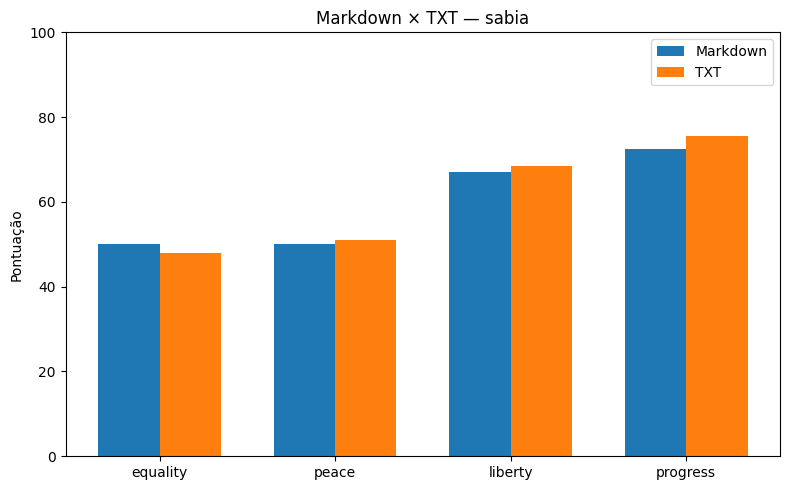

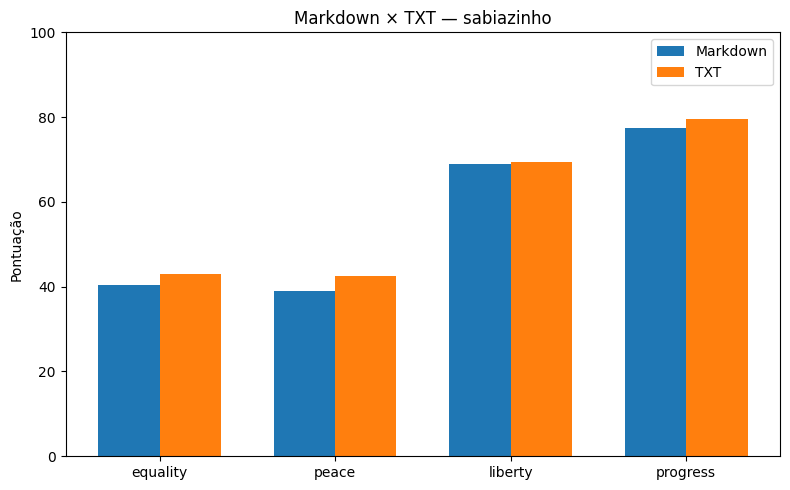

In [ ]:
modelos = df["modelo"].unique()

for modelo in modelos:

    dados_modelo = df_medias[
        df_medias["modelo"] == modelo
    ]

    x = np.arange(len(EIXOS))
    largura = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(
        x - largura / 2,
        dados_modelo["md"],
        largura,
        label="Markdown"
    )

    ax.bar(
        x + largura / 2,
        dados_modelo["txt"],
        largura,
        label="TXT"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(EIXOS)

    ax.set_ylim(0, 100)

    ax.set_ylabel("Pontuação")
    ax.set_title(f"Markdown × TXT — {modelo}")

    ax.legend()

    plt.tight_layout()
    plt.show()

##### Tempo de resposta

In [ ]:
tempos = []

for modelo, grupo in df.groupby("modelo"):

    for formato in ["md", "txt"]:

        valores = grupo[f"tempo_{formato}"]

        tempos.append({
            "modelo": modelo,
            "formato": formato,
            "media": valores.mean(),
            "mediana": valores.median(),
            "std": valores.std(),
            "min": valores.min(),
            "max": valores.max(),
        })

df_tempos = pd.DataFrame(tempos)

df_tempos.round(3)

,modelo,formato,media,mediana,std,min,max
0,gemini_flash,md,6.600,6.870,0.775,4.893,7.302
1,gemini_flash,txt,7.410,6.789,1.652,5.497,10.525
2,gemini_flash_lite,md,4.818,1.128,6.317,0.588,15.659
3,gemini_flash_lite,txt,0.804,0.847,0.123,0.622,0.937
4,openai_luna,md,4.162,3.822,0.782,3.544,5.866
5,openai_luna,txt,3.920,3.828,0.466,3.419,4.931
6,openai_mini,md,1.307,0.916,1.072,0.751,4.301
7,openai_mini,txt,1.074,0.941,0.343,0.773,1.839
8,sabia,md,1.194,1.028,0.362,0.955,2.047
9,sabia,txt,1.059,1.007,0.093,0.955,1.202


##### Geral

In [ ]:
# Estabilidade geral
estabilidade_modelo = (
    df_estabilidade
    .groupby("modelo")["std_medio"]
    .mean()
    .rename("instabilidade")
)

# Diferença MD x TXT
sensibilidade_formato = (
    diferenca_formato["diferenca_media"]
    .rename("diferenca_md_txt")
)

# Mediana geral de tempo MD + TXT
tempo_modelo = (
    df
    .groupby("modelo")
    .apply(
        lambda g: pd.concat([
            g["tempo_md"],
            g["tempo_txt"]
        ]).median()
    )
    .rename("tempo_mediano")
)

comparacao = pd.concat([
    estabilidade_modelo,
    sensibilidade_formato,
    tempo_modelo
], axis=1)

comparacao.round(2)

/tmp/ipykernel_1417/3284284704.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,instabilidade,diferenca_md_txt,tempo_mediano
modelo,,,
gemini_flash,3.75,3.40,6.85
gemini_flash_lite,5.90,8.38,0.85
openai_luna,3.72,4.65,3.82
openai_mini,7.50,9.90,0.92
sabia,2.84,2.62,1.01
sabiazinho,6.94,8.62,0.91


#### Modelo menos Raciocinio

In [ ]:
name, md, txt = tp_textos[0]
teste_LLM = []

In [ ]:
modelo = 'gemini_flash_lite'

In [ ]:
for i in range(0,10):
  estimado_md = await EstimateResultModel(md, llm=MODELS[modelo])
  estimado_txt = await EstimateResultModel(txt, llm=MODELS[modelo])

  resultado = {
    "name":name,
    "estimado_md": estimado_md,
    "estimado_txt": estimado_txt
  }

  teste_LLM.append(resultado)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EIXOS = ["equality", "peace", "liberty", "progress"]

# resultados = sua lista com os dicionários

linhas = []

for i, r in enumerate(teste_LLM):
    md = r["estimado_md"].model_dump()
    txt = r["estimado_txt"].model_dump()

    for eixo in EIXOS:
        linhas.append({
            "execucao": i + 1,
            "eixo": eixo,
            "md": md[eixo],
            "txt": txt[eixo],
            "diferenca": md[eixo] - txt[eixo],
            "diferenca_absoluta": abs(md[eixo] - txt[eixo]),
        })

df = pd.DataFrame(linhas)
display(df)

,execucao,eixo,md,txt,diferenca,diferenca_absoluta
0,1,equality,50.0,45.0,5.0,5.0
1,1,peace,40.0,40.0,0.0,0.0
2,1,liberty,60.0,60.0,0.0,0.0
3,1,progress,65.0,70.0,-5.0,5.0
4,2,equality,50.0,50.0,0.0,0.0
5,2,peace,40.0,40.0,0.0,0.0
6,2,liberty,60.0,65.0,-5.0,5.0
7,2,progress,65.0,70.0,-5.0,5.0
8,3,equality,50.0,50.0,0.0,0.0
9,3,peace,40.0,40.0,0.0,0.0


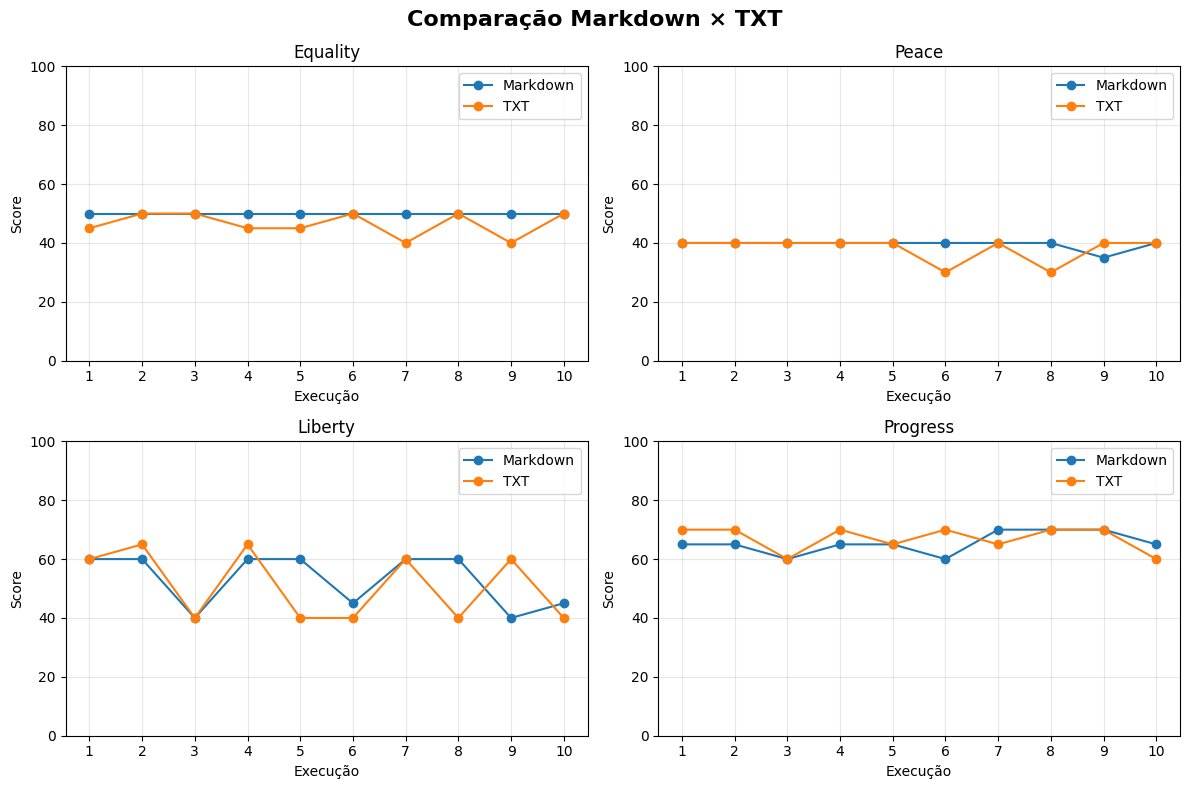

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for ax, eixo in zip(axes, EIXOS):
    dados = df[df["eixo"] == eixo]

    ax.plot(
        dados["execucao"],
        dados["md"],
        marker="o",
        label="Markdown"
    )

    ax.plot(
        dados["execucao"],
        dados["txt"],
        marker="o",
        label="TXT"
    )

    ax.set_title(eixo.capitalize())
    ax.set_xlabel("Execução")
    ax.set_ylabel("Score")
    ax.set_xticks(dados["execucao"])
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Comparação Markdown × TXT", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

#### Modelo mais Raciocinio

In [ ]:
modelo = 'gemini_flash'

In [ ]:
for i in range(0,10):
  estimado_md = await EstimateResultModel(md, llm=MODELS[modelo])
  estimado_txt = await EstimateResultModel(txt, llm=MODELS[modelo])

  resultado = {
    "name":name,
    "estimado_md": estimado_md,
    "estimado_txt": estimado_txt
  }

  teste_LLM.append(resultado)

In [ ]:
EIXOS = ["equality", "peace", "liberty", "progress"]

# resultados = sua lista com os dicionários

linhas = []

for i, r in enumerate(teste_LLM):
    md = r["estimado_md"].model_dump()
    txt = r["estimado_txt"].model_dump()

    for eixo in EIXOS:
        linhas.append({
            "execucao": i + 1,
            "eixo": eixo,
            "md": md[eixo],
            "txt": txt[eixo],
            "diferenca": md[eixo] - txt[eixo],
            "diferenca_absoluta": abs(md[eixo] - txt[eixo]),
        })

df = pd.DataFrame(linhas)
display(df)

,execucao,eixo,md,txt,diferenca,diferenca_absoluta
0,1,equality,50.0,50.0,0.0,0.0
1,1,peace,50.0,50.0,0.0,0.0
2,1,liberty,40.0,45.0,-5.0,5.0
3,1,progress,55.0,75.0,-20.0,20.0
4,2,equality,50.0,50.0,0.0,0.0
5,2,peace,45.0,50.0,-5.0,5.0
6,2,liberty,40.0,45.0,-5.0,5.0
7,2,progress,55.0,55.0,0.0,0.0
8,3,equality,50.0,50.0,0.0,0.0
9,3,peace,40.0,50.0,-10.0,10.0


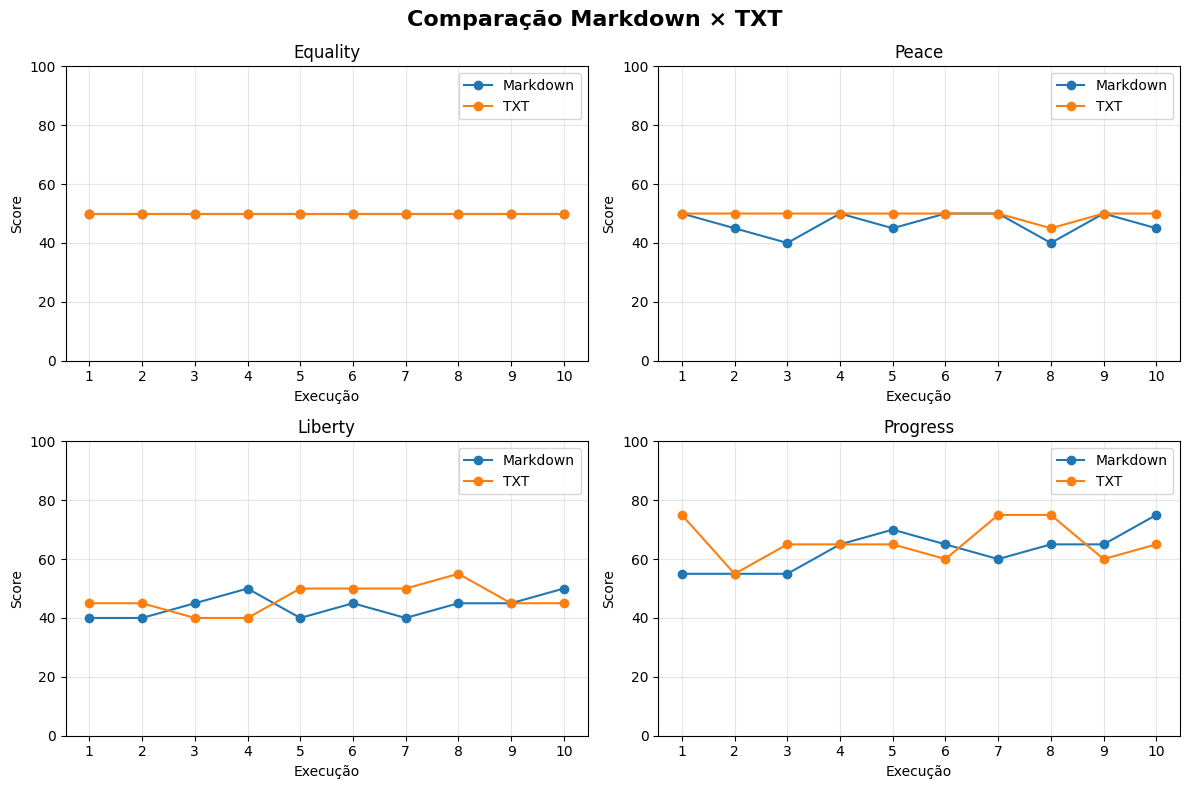

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for ax, eixo in zip(axes, EIXOS):
    dados = df[df["eixo"] == eixo]

    ax.plot(
        dados["execucao"],
        dados["md"],
        marker="o",
        label="Markdown"
    )

    ax.plot(
        dados["execucao"],
        dados["txt"],
        marker="o",
        label="TXT"
    )

    ax.set_title(eixo.capitalize())
    ax.set_xlabel("Execução")
    ax.set_ylabel("Score")
    ax.set_xticks(dados["execucao"])
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Comparação Markdown × TXT", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Teste perguntas individuais

In [ ]:
quiz_individual = await individual_questions(texto)

In [ ]:
values = quiz_individual.calculate_8values()
resultados = quiz_individual.get_results()
ideologia_total = resultados.to_list()
ideologia_proxima = values.closest_ideology

comparar_resultados(ideologia_total, ideologia_proxima.stats.to_list(), 'Resultado', ideologia_proxima.name)

In [ ]:
mostrar_respostas(quiz_individual)

,Perguntas,Respostas
0,A opressão por corporações é uma preocupação m...,neutral
1,É necessário que o governo intervenha na econo...,agree
2,"Quanto mais livres os mercados, mais livres as...",neutral
3,É melhor manter um orçamento equilibrado do qu...,disagree
4,A pesquisa financiada publicamente é mais bené...,agree
...,...,...
65,"A modificação genética é uma força para o bem,...",neutral
66,Deberíamos abrir nossas fronteiras à imigração.,neutral
67,Os governos deveriam se preocupar tanto com es...,neutral
68,Todas as pessoas - independentemente de fatore...,strongly_agree


### Teste Perguntas Total

#### Teste Perguntas Total Gemini

In [ ]:
quiz_total = await all_questions(texto,llm=MODELS['gemini_flash_lite'])

answers=[Answer(id=1, answer=<AnswerOption.CONCORDO: 'concordo'>), Answer(id=2, answer=<AnswerOption.CONCORDO_FORTEMENTE: 'concordo_fortemente'>), Answer(id=3, answer=<AnswerOption.DISCORDO: 'discordo'>), Answer(id=4, answer=<AnswerOption.DISCORDO: 'discordo'>), Answer(id=5, answer=<AnswerOption.CONCORDO: 'concordo'>), Answer(id=6, answer=<AnswerOption.NEUTRO_INCERTO: 'neutro_incerto'>), Answer(id=7, answer=<AnswerOption.CONCORDO: 'concordo'>), Answer(id=8, answer=<AnswerOption.DISCORDO: 'discordo'>), Answer(id=9, answer=<AnswerOption.CONCORDO: 'concordo'>), Answer(id=10, answer=<AnswerOption.NEUTRO_INCERTO: 'neutro_incerto'>), Answer(id=11, answer=<AnswerOption.CONCORDO: 'concordo'>), Answer(id=12, answer=<AnswerOption.DISCORDO: 'discordo'>), Answer(id=13, answer=<AnswerOption.DISCORDO_FORTEMENTE: 'discordo_fortemente'>), Answer(id=14, answer=<AnswerOption.CONCORDO_FORTEMENTE: 'concordo_fortemente'>), Answer(id=15, answer=<AnswerOption.CONCORDO: 'concordo'>), Answer(id=16, answer=<Ans

In [ ]:
resultados = quiz_total.get_results()
values = quiz_total.calculate_8values(resultados, IDEOLOGIES)
ideologia_total = resultados.to_list()
ideologia_proxima = values.closest_ideology

comparar_resultados(ideologia_total, ideologia_proxima.stats.to_list(), 'Resultado', ideologia_proxima.name)

In [ ]:
mostrar_respostas(quiz_total)

,Perguntas,Respostas
0,A opressão por corporações é uma preocupação m...,AnswerOption.CONCORDO
1,É necessário que o governo intervenha na econo...,AnswerOption.CONCORDO_FORTEMENTE
2,"Quanto mais livres os mercados, mais livres as...",AnswerOption.DISCORDO
3,É melhor manter um orçamento equilibrado do qu...,AnswerOption.DISCORDO
4,A pesquisa financiada publicamente é mais bené...,AnswerOption.CONCORDO
...,...,...
65,"A modificação genética é uma força para o bem,...",AnswerOption.NEUTRO_INCERTO
66,Deberíamos abrir nossas fronteiras à imigração.,AnswerOption.NEUTRO_INCERTO
67,Os governos deveriam se preocupar tanto com es...,AnswerOption.NEUTRO_INCERTO
68,Todas as pessoas - independentemente de fatore...,AnswerOption.CONCORDO_FORTEMENTE


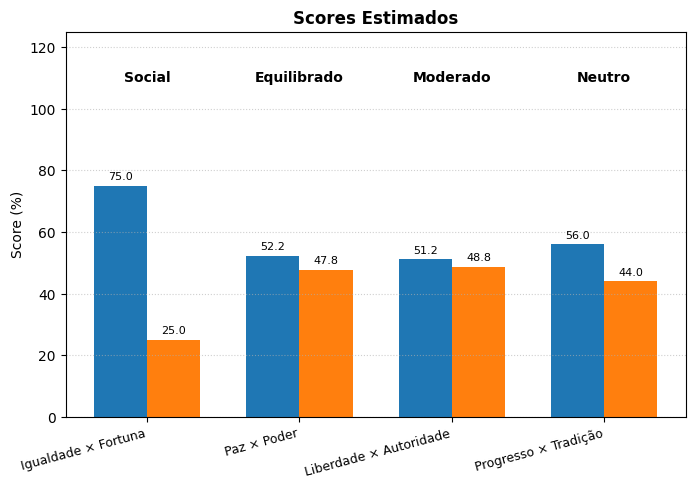

In [ ]:
grafico_scores(values.scores.model_dump(), values.labels.to_list(), "Scores Estimados")

#### Teste Perguntas Total GPT

In [ ]:
quiz_total = await all_questions(texto,llm=MODELS["openai_luna"])

In [ ]:
values = quiz_total.calculate_8values()
resultados = quiz_total.get_results()
ideologia_total = resultados.to_list()
ideologia_proxima = values.closest_ideology

comparar_resultados(ideologia_total, ideologia_proxima.stats.to_list(), 'Resultado', ideologia_proxima.name)

In [ ]:
mostrar_respostas(quiz_total)

,Perguntas,Respostas
0,A opressão por corporações é uma preocupação m...,concordo
1,É necessário que o governo intervenha na econo...,concordo_fortemente
2,"Quanto mais livres os mercados, mais livres as...",discordo
3,É melhor manter um orçamento equilibrado do qu...,discordo_fortemente
4,A pesquisa financiada publicamente é mais bené...,concordo
...,...,...
65,"A modificação genética é uma força para o bem,...",neutro_incerto
66,Deberíamos abrir nossas fronteiras à imigração.,concordo
67,Os governos deveriam se preocupar tanto com es...,concordo_fortemente
68,Todas as pessoas - independentemente de fatore...,concordo_fortemente


#### Teste Perguntas Total Claude

In [ ]:
quiz_total = await all_questions(texto, llm=MODELS['claude_haiku'])

responseeee micael answers=[Answer(id=1, answer='neutro_incerto'), Answer(id=2, answer='concordo'), Answer(id=3, answer='neutro_incerto'), Answer(id=4, answer='discordo'), Answer(id=5, answer='concordo'), Answer(id=6, answer='neutro_incerto'), Answer(id=7, answer='concordo'), Answer(id=8, answer='discordo'), Answer(id=9, answer='concordo'), Answer(id=10, answer='neutro_incerto'), Answer(id=11, answer='concordo'), Answer(id=12, answer='discordo'), Answer(id=13, answer='discordo'), Answer(id=14, answer='concordo_fortemente'), Answer(id=15, answer='concordo'), Answer(id=16, answer='discordo'), Answer(id=17, answer='neutro_incerto'), Answer(id=18, answer='concordo'), Answer(id=19, answer='concordo'), Answer(id=20, answer='neutro_incerto'), Answer(id=21, answer='concordo'), Answer(id=22, answer='discordo'), Answer(id=23, answer='concordo'), Answer(id=24, answer='concordo'), Answer(id=25, answer='neutro_incerto'), Answer(id=26, answer='concordo'), Answer(id=27, answer='concordo'), Answer(id=

In [ ]:
values = quiz_total.calculate_8values()
resultados = quiz_total.get_results()
ideologia_total = resultados.to_list()
ideologia_proxima = values.closest_ideology

comparar_resultados(ideologia_total, ideologia_proxima.stats.to_list(), 'Resultado', ideologia_proxima.name)

In [ ]:
mostrar_respostas(quiz_total)

,Perguntas,Respostas
0,A opressão por corporações é uma preocupação m...,concordo
1,É necessário que o governo intervenha na econo...,concordo_fortemente
2,"Quanto mais livres os mercados, mais livres as...",discordo
3,É melhor manter um orçamento equilibrado do qu...,discordo_fortemente
4,A pesquisa financiada publicamente é mais bené...,concordo
...,...,...
65,"A modificação genética é uma força para o bem,...",neutro_incerto
66,Deberíamos abrir nossas fronteiras à imigração.,concordo
67,Os governos deveriam se preocupar tanto com es...,concordo_fortemente
68,Todas as pessoas - independentemente de fatore...,concordo_fortemente


#### Teste Perguntas Total Maritaca

In [ ]:
quiz_total = await all_questions(texto, llm=MODELS['sabiazinho'])

responseeee micael answers=[Answer(id=1, answer='discordo'), Answer(id=2, answer='concordo'), Answer(id=3, answer='discordo'), Answer(id=4, answer='discordo'), Answer(id=5, answer='concordo'), Answer(id=6, answer='neutro_incerto'), Answer(id=7, answer='concordo'), Answer(id=8, answer='discordo_fortemente'), Answer(id=9, answer='concordo'), Answer(id=10, answer='concordo'), Answer(id=11, answer='concordo'), Answer(id=12, answer='discordo'), Answer(id=13, answer='discordo'), Answer(id=14, answer='concordo'), Answer(id=15, answer='concordo'), Answer(id=16, answer='discordo'), Answer(id=17, answer='neutro_incerto'), Answer(id=18, answer='concordo'), Answer(id=19, answer='concordo'), Answer(id=20, answer='neutro_incerto'), Answer(id=21, answer='concordo'), Answer(id=22, answer='concordo'), Answer(id=23, answer='neutro_incerto'), Answer(id=24, answer='neutro_incerto'), Answer(id=25, answer='concordo_fortemente'), Answer(id=26, answer='concordo'), Answer(id=27, answer='concordo'), Answer(id=2

In [ ]:
values = quiz_total.calculate_8values()
resultados = quiz_total.get_results()
ideologia_total = resultados.to_list()
ideologia_proxima = values.closest_ideology

comparar_resultados(ideologia_total, ideologia_proxima.stats.to_list(), 'Resultado', ideologia_proxima.name)

In [ ]:
mostrar_respostas(quiz_total)

,Perguntas,Respostas
0,A opressão por corporações é uma preocupação m...,concordo
1,É necessário que o governo intervenha na econo...,concordo_fortemente
2,"Quanto mais livres os mercados, mais livres as...",discordo
3,É melhor manter um orçamento equilibrado do qu...,discordo_fortemente
4,A pesquisa financiada publicamente é mais bené...,concordo
...,...,...
65,"A modificação genética é uma força para o bem,...",neutro_incerto
66,Deberíamos abrir nossas fronteiras à imigração.,concordo
67,Os governos deveriam se preocupar tanto com es...,concordo_fortemente
68,Todas as pessoas - independentemente de fatore...,concordo_fortemente


### Comparação Perguntas Individuais x Total

In [ ]:
textos = []

for arquivo in Path(TEXTS_PATH).glob("*.txt"):
  texto = arquivo.read_text(encoding="utf-8")
  textos.append(texto)

#### Gerar Dados

In [ ]:
lista_total = []

In [ ]:
try:
  quiz_total = await all_questions(textos[2])
  lista_total.append(quiz_total)
except Exception as e:
  print(e)

In [ ]:
with open(TOTAL_LIST_PATH, "w") as f:
  json.dump([q.answers for q in lista_total], f)

In [ ]:
lista_individual = []

In [ ]:
try:
  quiz_individual = await individual_questions(textos[2])
  lista_individual.append(quiz_individual)
except Exception as e:
  print("Erro: ", e)

[11:35:32] Processando lote 1/7...
Aguardando 60s para o próximo lote...
[11:36:33] Processando lote 2/7...
Aguardando 60s para o próximo lote...
[11:37:36] Processando lote 3/7...
Aguardando 60s para o próximo lote...
[11:38:37] Processando lote 4/7...
Aguardando 60s para o próximo lote...
[11:39:39] Processando lote 5/7...
Aguardando 60s para o próximo lote...
[11:40:42] Processando lote 6/7...
Aguardando 60s para o próximo lote...
[11:41:43] Processando lote 7/7...


In [ ]:
with open(INDIVIDUAL_LIST_PATH, "w") as f:
  json.dump([q.answers for q in lista_individual], f)

#### Análise

In [ ]:
lista_individual = ler_respostas(INDIVIDUAL_LIST_PATH)
lista_total = ler_respostas(TOTAL_LIST_PATH)


            ANÁLISE: PL 1516-2025



,Perguntas,Resposta Individual,Resposta Total
0,A opressão por corporações é uma preocupação m...,AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
1,É necessário que o governo intervenha na econo...,AnswerOption.CONCORDO_FORTEMENTE,AnswerOption.CONCORDO_FORTEMENTE
2,"Quanto mais livres os mercados, mais livres as...",AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO
3,É melhor manter um orçamento equilibrado do qu...,AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO_FORTEMENTE
4,A pesquisa financiada publicamente é mais bené...,AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO
...,...,...,...
65,"A modificação genética é uma força para o bem,...",AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
66,Deberíamos abrir nossas fronteiras à imigração.,AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO
67,Os governos deveriam se preocupar tanto com es...,AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO
68,Todas as pessoas - independentemente de fatore...,AnswerOption.CONCORDO_FORTEMENTE,AnswerOption.CONCORDO_FORTEMENTE


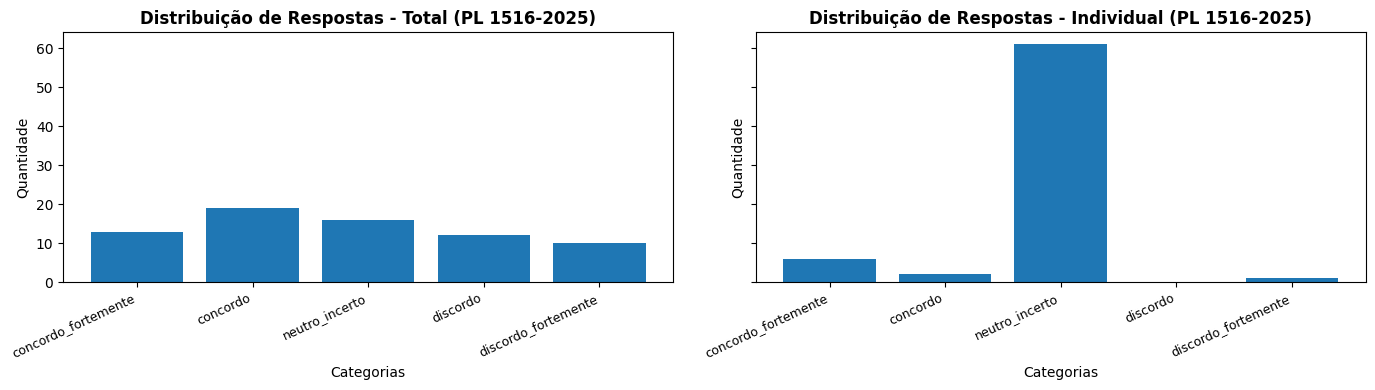

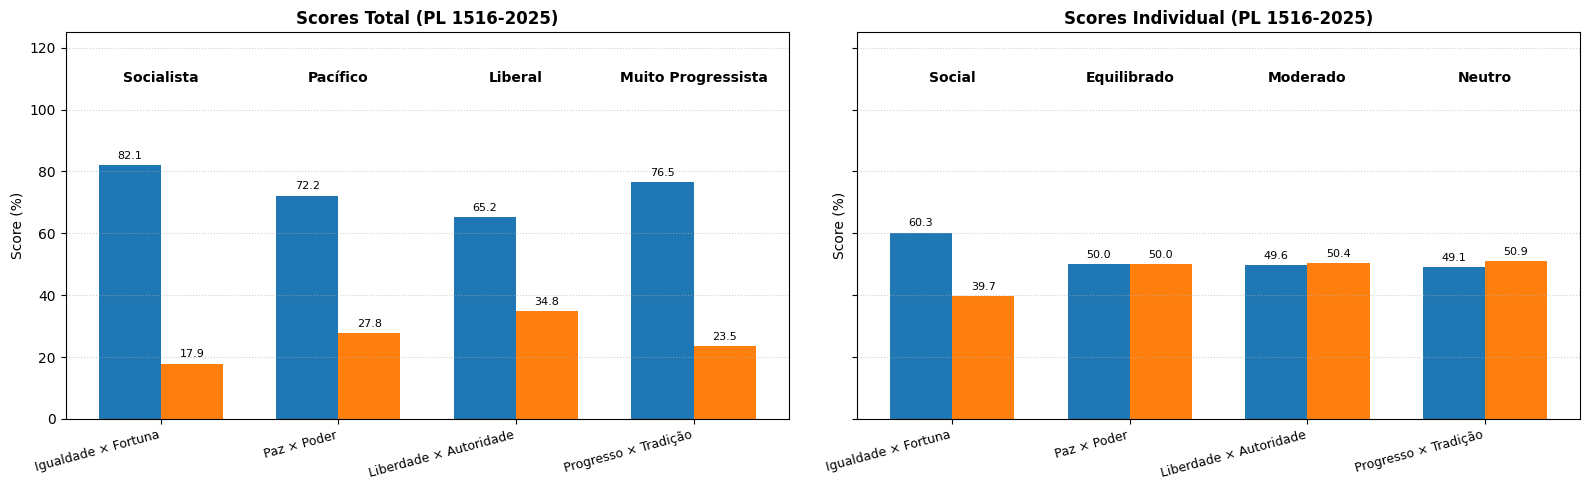


            ANÁLISE: PL 191-2020



,Perguntas,Resposta Individual,Resposta Total
0,A opressão por corporações é uma preocupação m...,AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
1,É necessário que o governo intervenha na econo...,AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO
2,"Quanto mais livres os mercados, mais livres as...",AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
3,É melhor manter um orçamento equilibrado do qu...,AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
4,A pesquisa financiada publicamente é mais bené...,AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO
...,...,...,...
65,"A modificação genética é uma força para o bem,...",AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
66,Deberíamos abrir nossas fronteiras à imigração.,AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
67,Os governos deveriam se preocupar tanto com es...,AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
68,Todas as pessoas - independentemente de fatore...,AnswerOption.CONCORDO_FORTEMENTE,AnswerOption.CONCORDO_FORTEMENTE


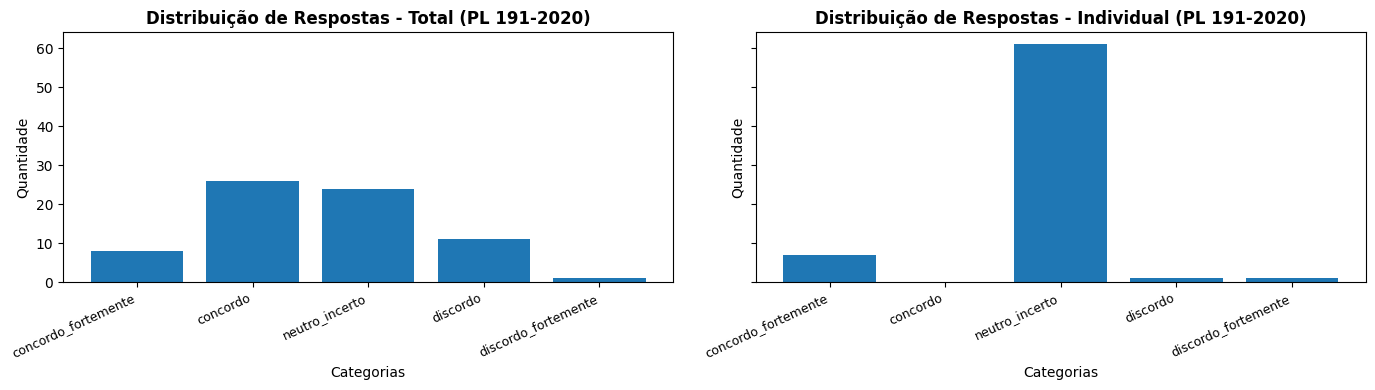

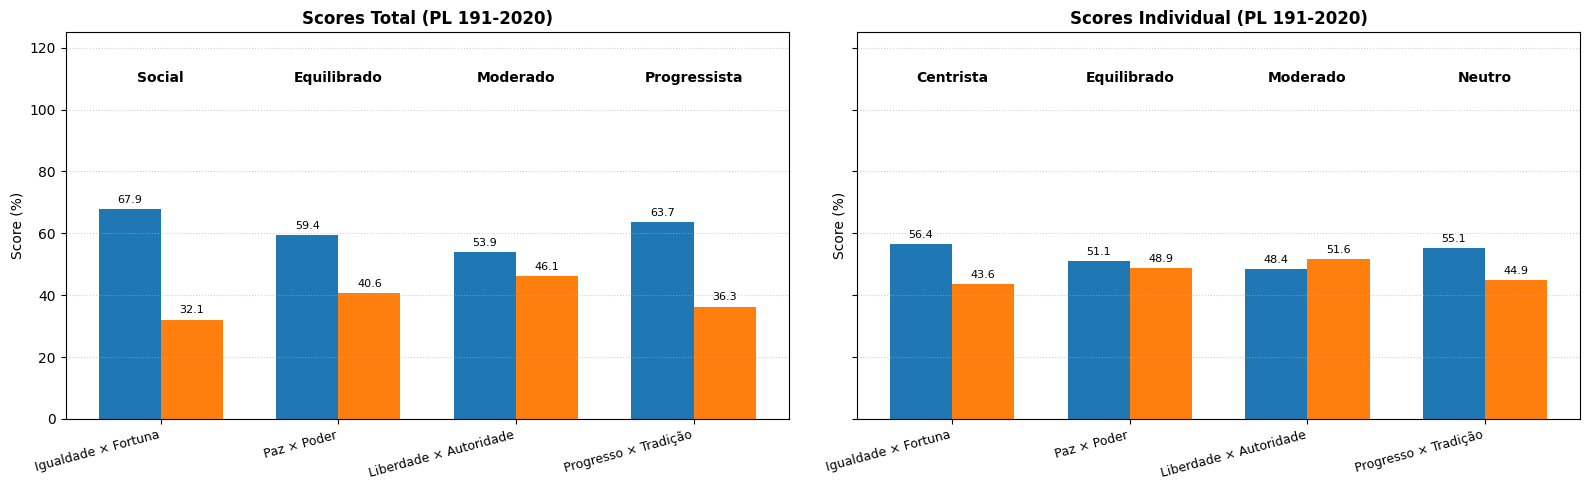


            ANÁLISE: PL 2858-2022



,Perguntas,Resposta Individual,Resposta Total
0,A opressão por corporações é uma preocupação m...,AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO
1,É necessário que o governo intervenha na econo...,AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO
2,"Quanto mais livres os mercados, mais livres as...",AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO_FORTEMENTE
3,É melhor manter um orçamento equilibrado do qu...,AnswerOption.NEUTRO_INCERTO,AnswerOption.CONCORDO
4,A pesquisa financiada publicamente é mais bené...,AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO
...,...,...,...
65,"A modificação genética é uma força para o bem,...",AnswerOption.NEUTRO_INCERTO,AnswerOption.NEUTRO_INCERTO
66,Deberíamos abrir nossas fronteiras à imigração.,AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO_FORTEMENTE
67,Os governos deveriam se preocupar tanto com es...,AnswerOption.NEUTRO_INCERTO,AnswerOption.DISCORDO
68,Todas as pessoas - independentemente de fatore...,AnswerOption.CONCORDO_FORTEMENTE,AnswerOption.CONCORDO


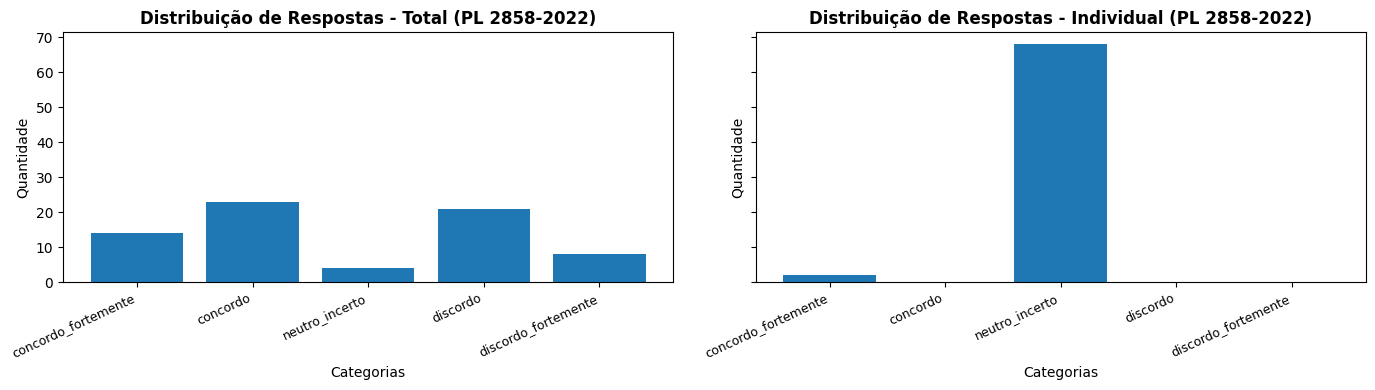

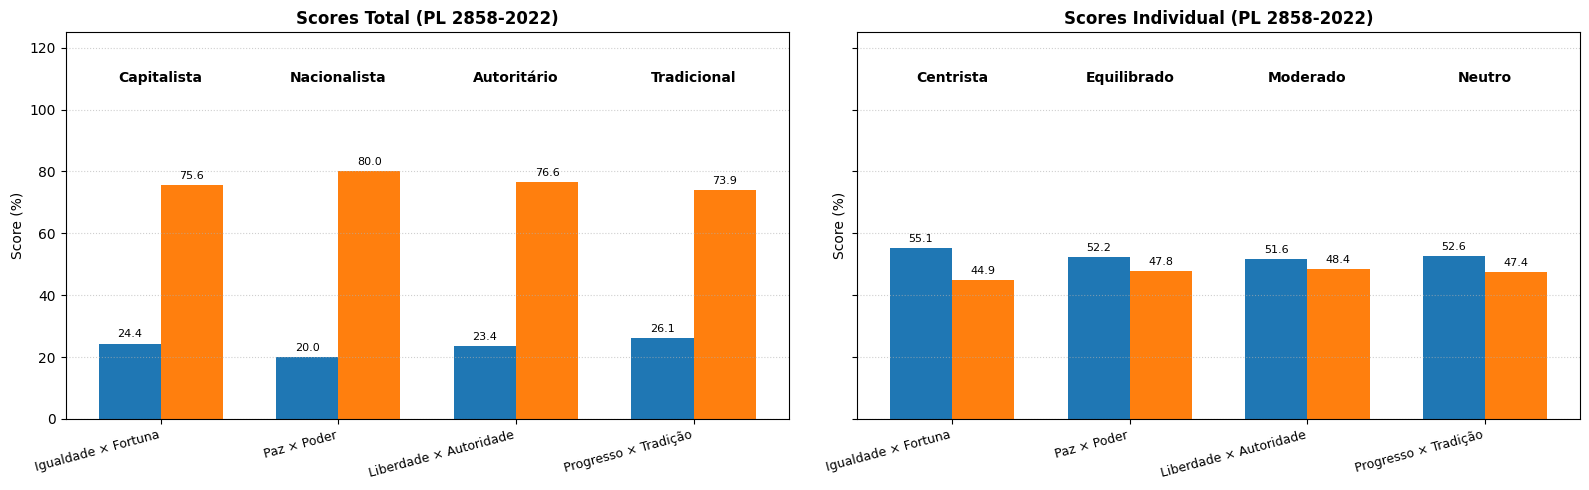

In [ ]:
titulos = ["PL 1516-2025", "PL 191-2020", "PL 2858-2022"]

for i, t, titulo in zip(lista_individual, lista_total, titulos):
    processar_e_comparar(
        quiz_ind=i,
        quiz_tot=t,
        titulo=titulo,
        questions_list=QUESTIONS
    )

### Teste Estimado

In [ ]:
result = await EstimateResultModel(texto, llm=MODELS["gemini_flash_lite"])

In [ ]:
values = Quiz8Values.calculate_8values(result, IDEOLOGIES)

NameError: name 'result' is not defined

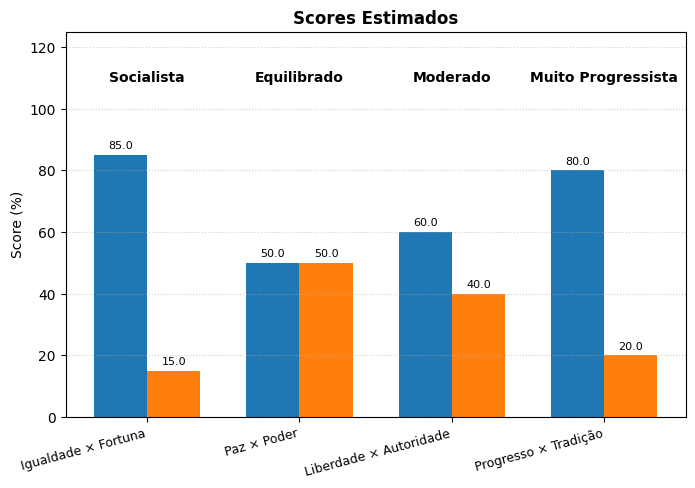

In [ ]:
grafico_scores(values.scores.model_dump(), values.labels.to_list(), "Scores Estimados")

### Perguntas Estimado x Total x Individual

In [ ]:
path = DRIVE_PATH + 'results.json'

#### Gerar dados

In [ ]:
textos = []

for arquivo in Path(PDF_PATH).glob("*.pdf"):
  md = pymupdf4llm.to_markdown(arquivo,header=False, footer=False,use_ocr=False)
  filename = Path(arquivo).name

  textos.append((filename, md))

In [ ]:
resultados = []
modelo = 'gemini_flash_lite'

for name, texto in textos:
  estimado = await EstimateResultModel(texto, llm=MODELS[modelo])
  quiz_total = await all_questions(texto, llm=MODELS[modelo])
  quiz_individual = await individual_questions(texto, llm=MODELS[modelo],intervalo_segundos=5)

  resultado = ResultadoAnalise(
      estimado=estimado,
      quiz_total=quiz_total.get_results(),
      quiz_individual=quiz_individual.get_results(),
      modelo=modelo,
      texto=texto,
      nome=name
  )

  resultados.append(resultado)

[17:14:16] Processando lote 1/7...
Aguardando 5s para o próximo lote...
[17:14:22] Processando lote 2/7...
Aguardando 5s para o próximo lote...
[17:14:28] Processando lote 3/7...
Aguardando 5s para o próximo lote...
[17:14:33] Processando lote 4/7...
Aguardando 5s para o próximo lote...
[17:14:39] Processando lote 5/7...
Aguardando 5s para o próximo lote...
[17:14:45] Processando lote 6/7...
Aguardando 5s para o próximo lote...
[17:14:51] Processando lote 7/7...


In [ ]:
with open(path, "w") as f:
      json.dump(
        [r.model_dump() for r in resultados],
        f,
        ensure_ascii=False,
        indent=4
    )

#### Comparar

In [ ]:
resultados = ler_json_tiptado(path, list[ResultadoAnalise])

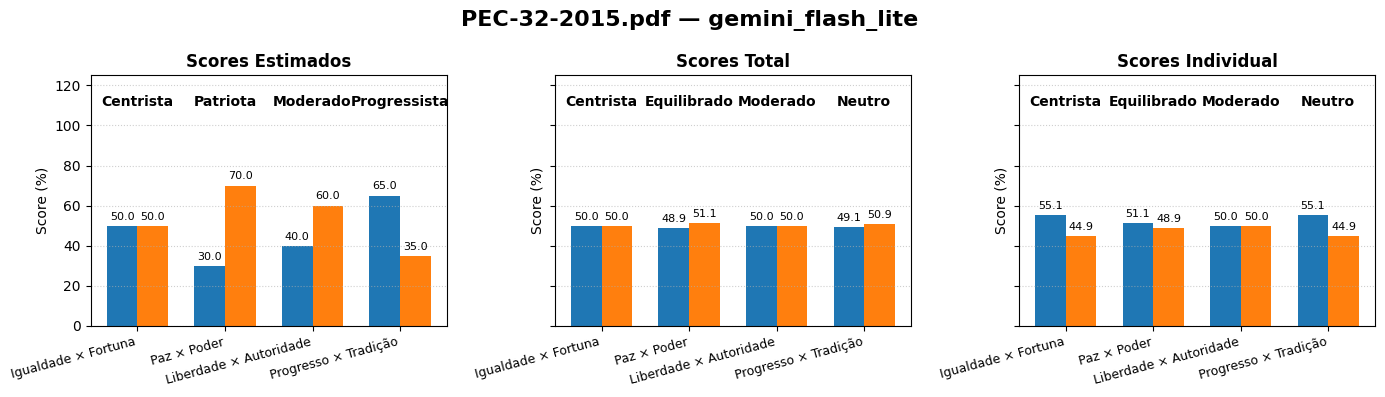

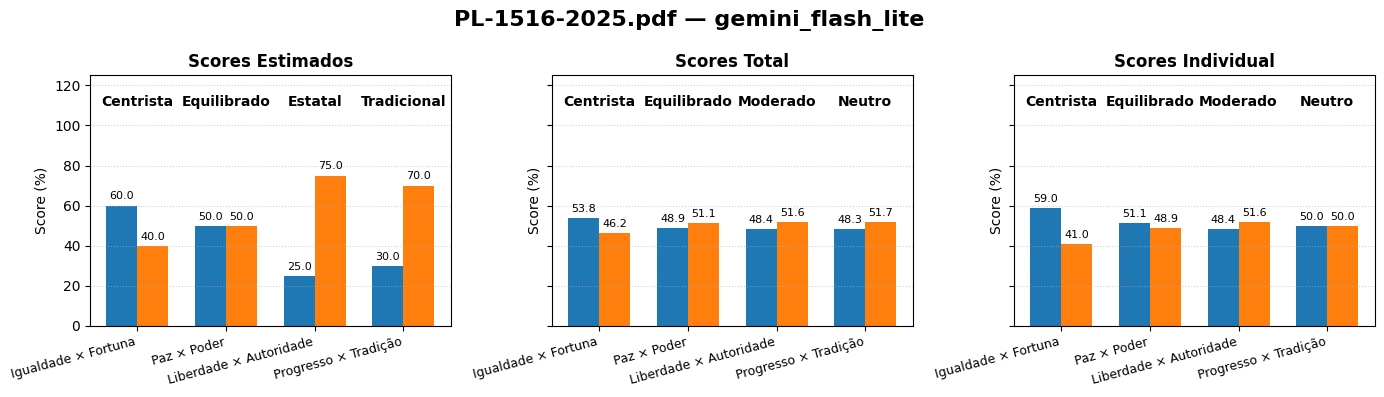

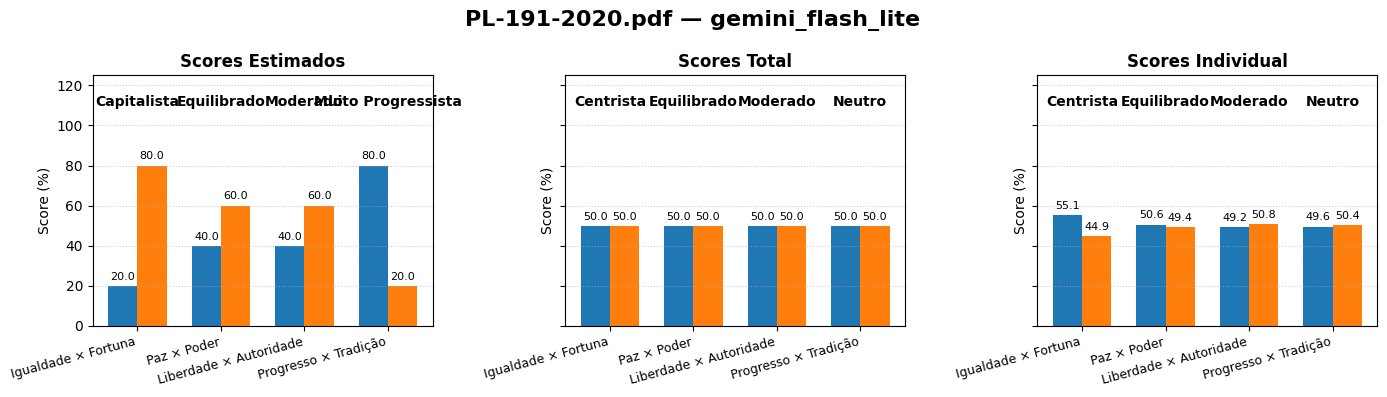

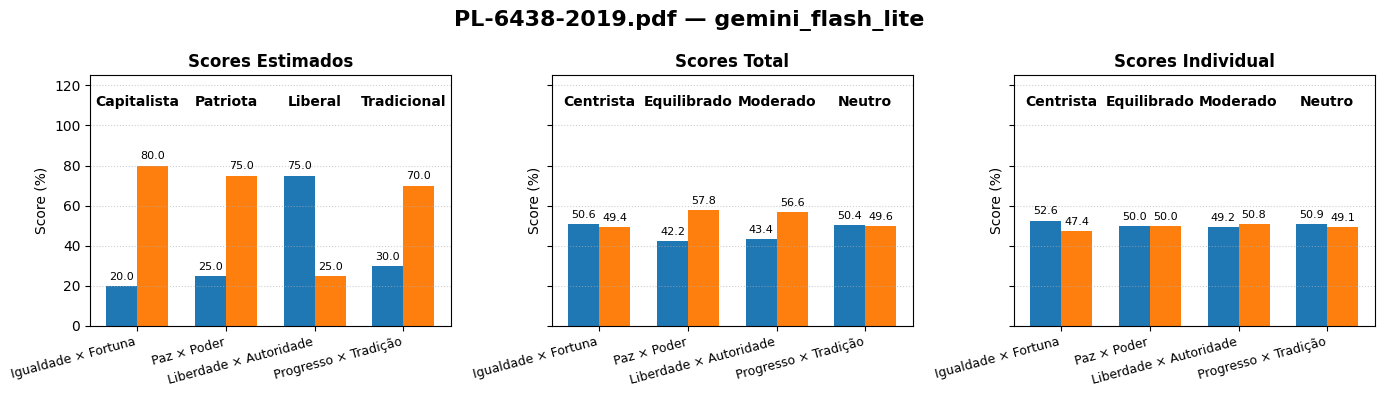

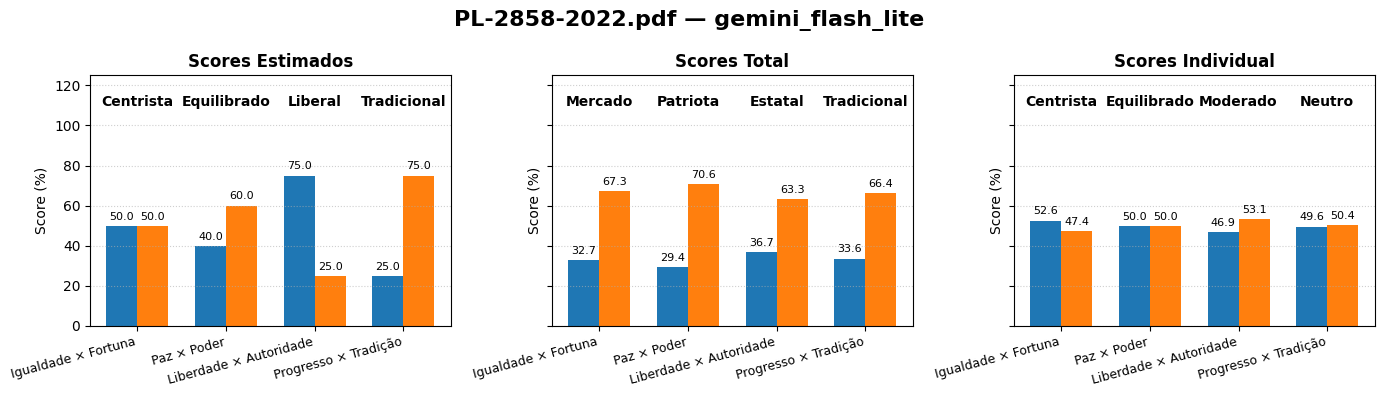

In [ ]:
for r in resultados:
  modelo = r.modelo
  texto = r.texto
  nome = r.nome

  values_estimado = Quiz8Values.calculate_8values(r.estimado, IDEOLOGIES)
  values_total = Quiz8Values.calculate_8values(r.quiz_total, IDEOLOGIES)
  values_individual = Quiz8Values.calculate_8values(r.quiz_individual, IDEOLOGIES)


  fig1, (ax1_est, ax1_tot, ax1_ind) = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
  grafico_scores(values_estimado.scores.model_dump(), values_estimado.labels.to_list(), f"Scores Estimados", ax1_est)
  grafico_scores(values_total.scores.model_dump(), values_total.labels.to_list(), f"Scores Total", ax1_tot)
  grafico_scores(values_individual.scores.model_dump(), values_individual.labels.to_list(), f"Scores Individual",ax1_ind)

  fig1.suptitle(
      f"{nome} — {modelo}",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout()
  plt.show()

### Teste Planos Governo

In [ ]:
path = DRIVE_PATH + "textos_candidatos.json"

#### Gerar Dados

In [ ]:
candidatos = {
    "2026BR280002538811_01": "Samara Martins (UP)",
    "2026BR280002539826_01": "ROMEU ZEMA (NOVO)",
    "2026BR280002540694_01": "Renan Santos (Missão)",
    "2026BR280002541457_01": "Hertz Dias (PSTU)",
    "2026BR280002542548_01": "Lula (PT)",
    "2026BR280002548139_01": "Wilson Grassi (Democrata)",
    "2026BR280002551544_01": "Flávio Bolsonaro (PL)",
    "2026BR280002551547_01": "Augusto Cury (Avante)",
    "2026BR280002551932_01": "Ronaldo Caiado (PSD)",
    "2026BR280002551975_01": "Edmilson Costa (PCB)",
    "2026BR280002552484_01": "Clariana Barão (DC)",
    "2026BR280002552487_01":"Rui Costa Pimenta (PCO)"

}

In [ ]:
textos_governo = []

In [ ]:
for arquivo in Path(PLANO_GOVERNO_PATH).glob("*.pdf"):
  md = pymupdf4llm.to_markdown(arquivo, header=False, footer=False, use_ocr=False)
  txt = pymupdf4llm.to_text(arquivo, header=False, footer=False, use_ocr=False)
  filename = Path(arquivo).name
  key = filename[:-4]

  if key in candidatos:
    textos_governo.append({"filename":filename, "md":md, "txt":txt, "candidato": candidatos[key]})

In [ ]:
with open(path, "w") as f:
      json.dump(
        textos_governo,
        f,
        ensure_ascii=False,
        indent=4
    )

#### Testes

In [ ]:
planos_governo = ler_json(path)

##### Nuvem Lexical

In [ ]:
 for plano in planos_governo:
  nuvem_lexical(plano['txt'],plano['candidato'])

Output hidden; open in https://colab.research.google.com to view.

##### Sabia

In [ ]:
modelo = "sabia"

###### Teste Estimado

In [ ]:
resultados_planos = []

In [ ]:
for plano in planos_governo:
  name = plano["candidato"]
  md = plano["md"]
  txt = plano["txt"]

  if name in [r["name"] for r in resultados_planos]:
    continue

  estimado_md = await EstimateResultModel(md, llm=MODELS[modelo])
  await asyncio.sleep(60)
  estimado_txt = await EstimateResultModel(txt, llm=MODELS[modelo])
  await asyncio.sleep(60)

  resultado = {
    "name":name,
    "estimado_md": estimado_md,
    "estimado_txt": estimado_txt
  }

  resultados_planos.append(resultado)

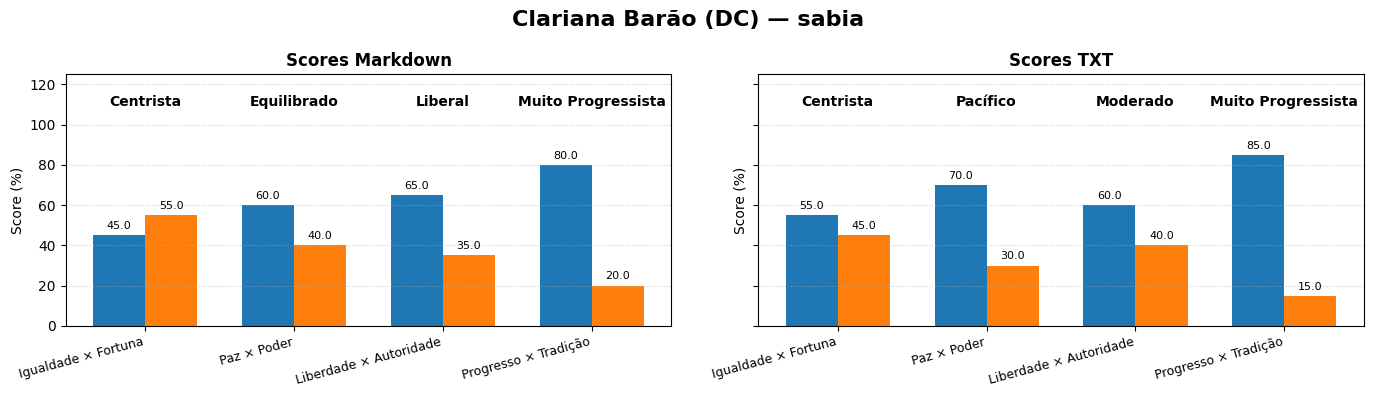

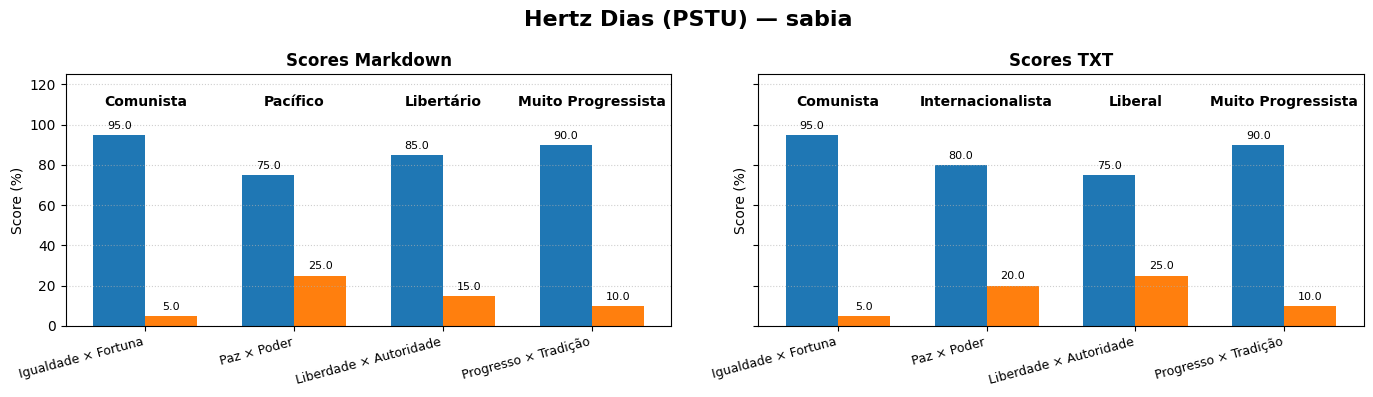

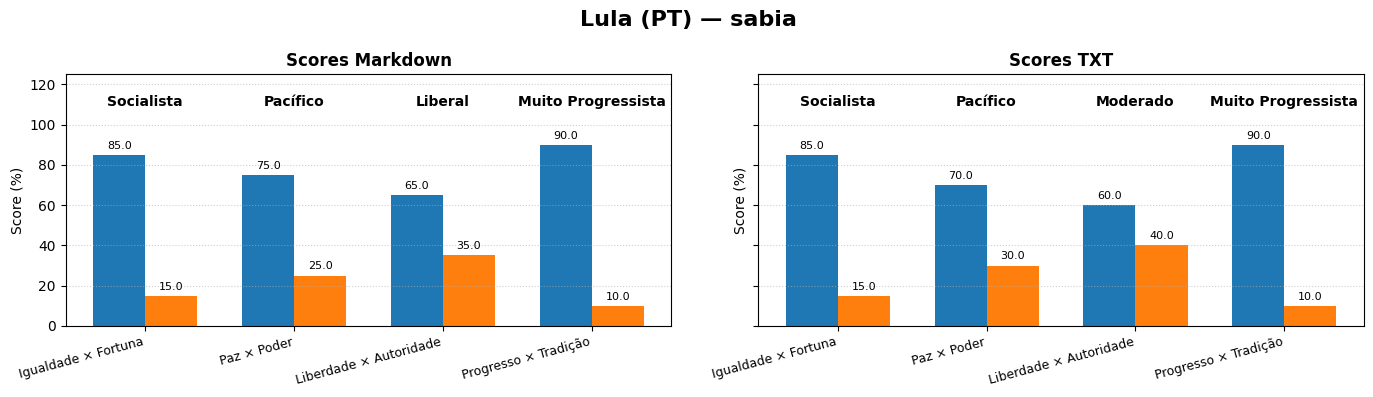

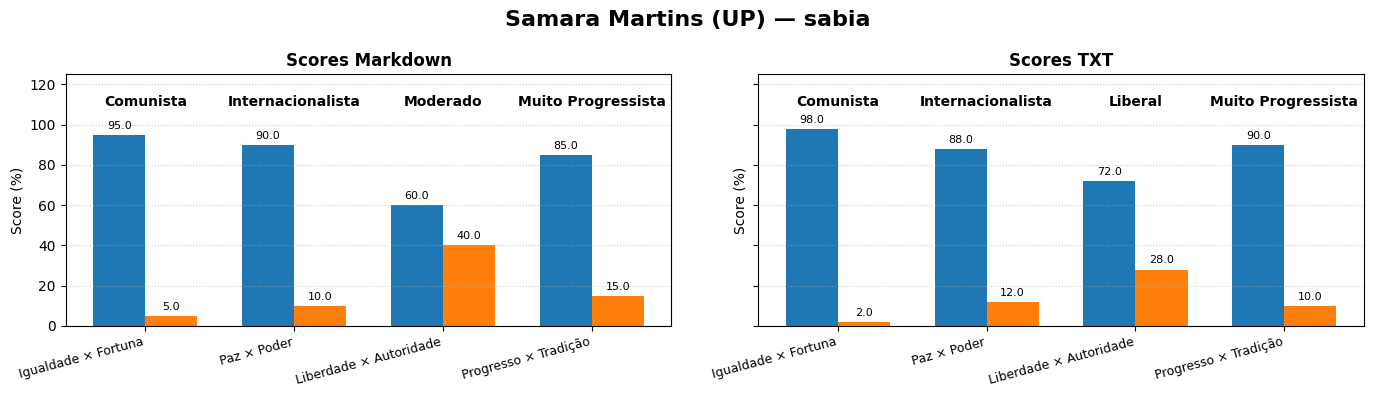

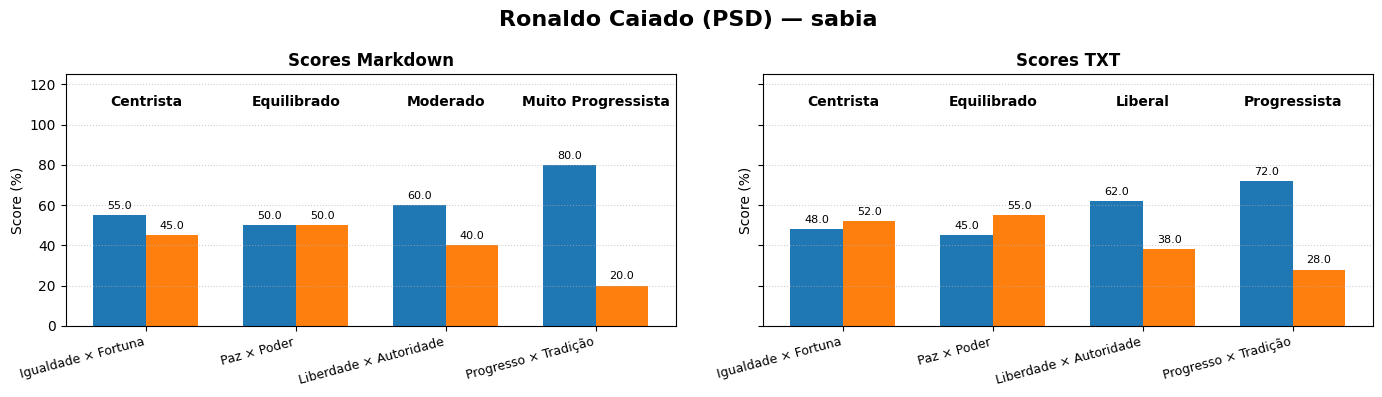

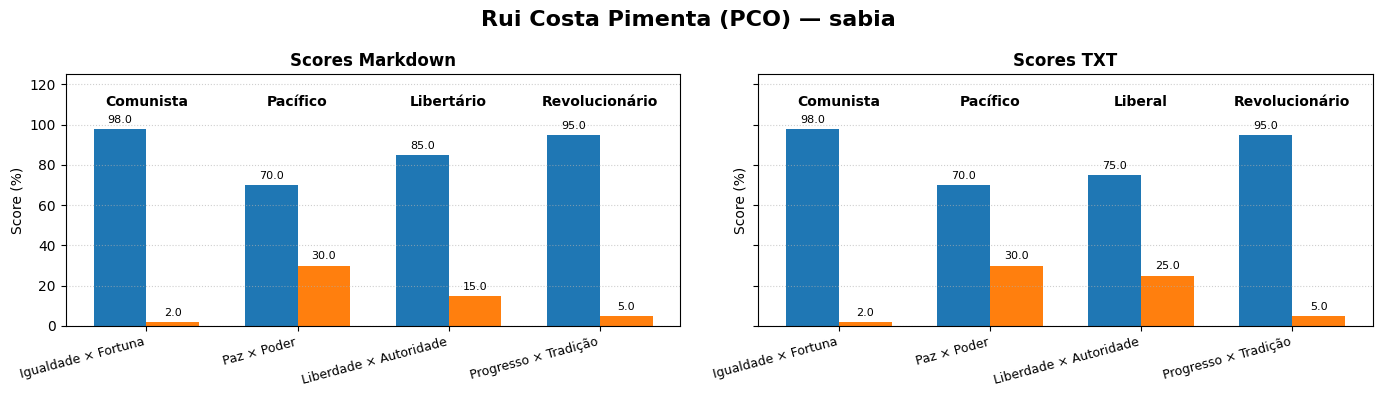

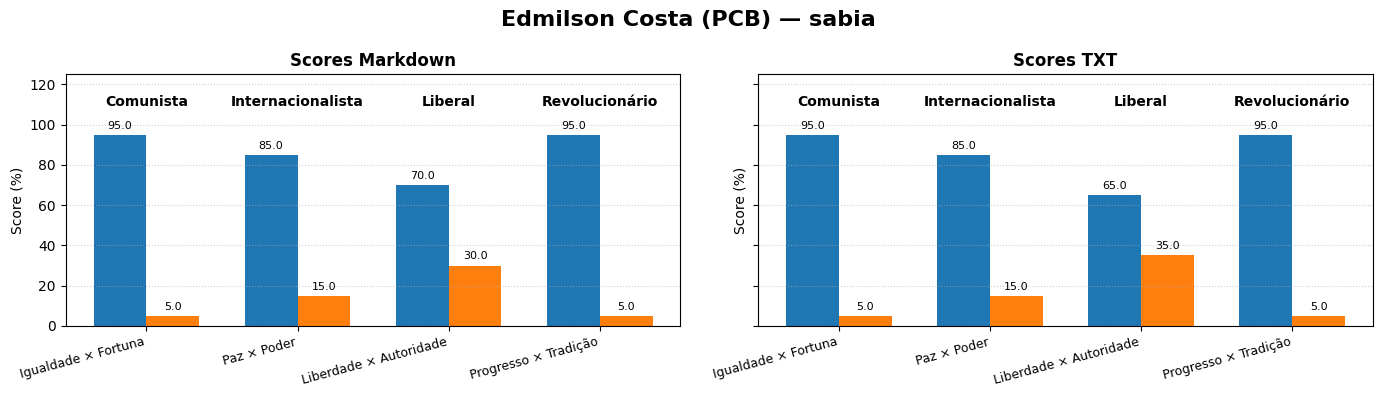

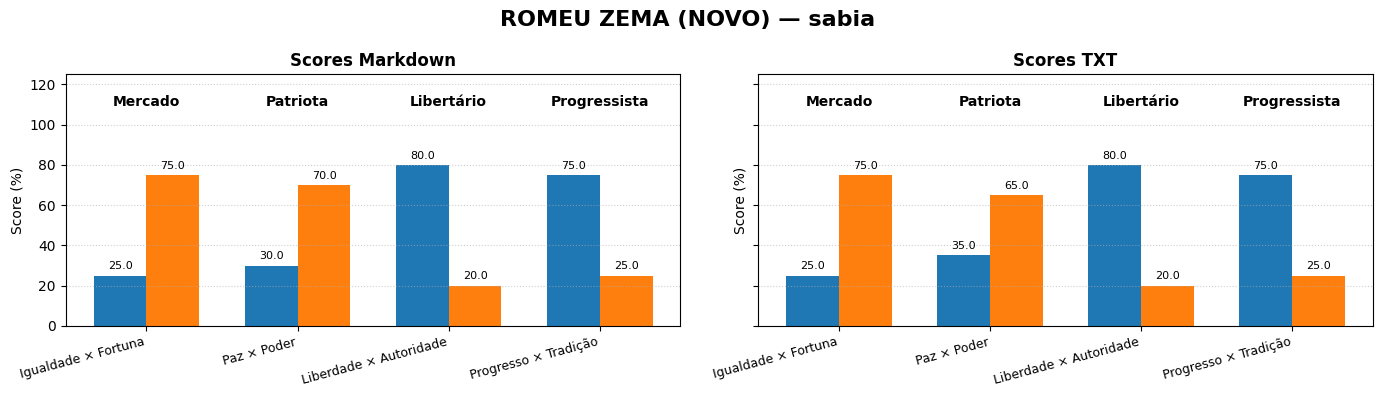

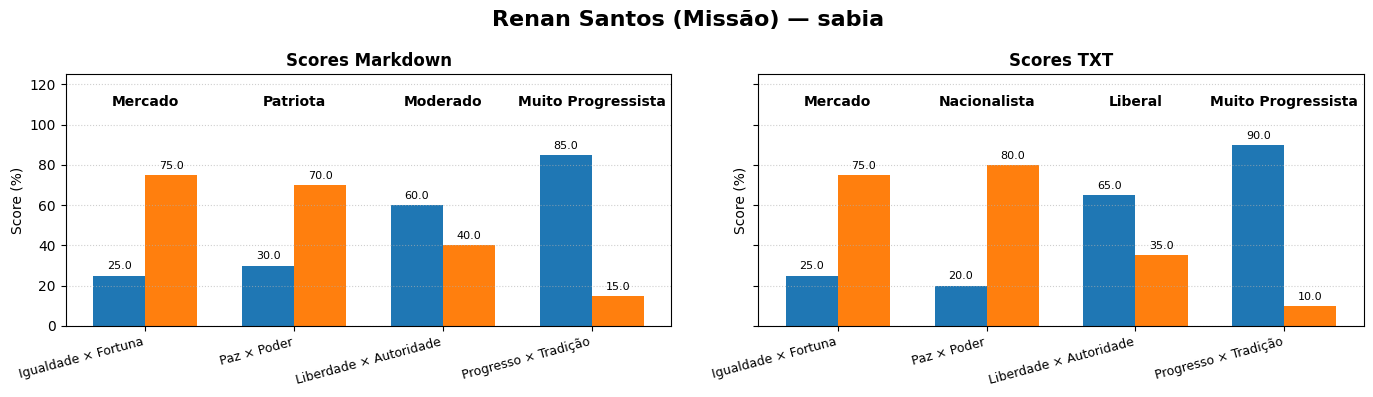

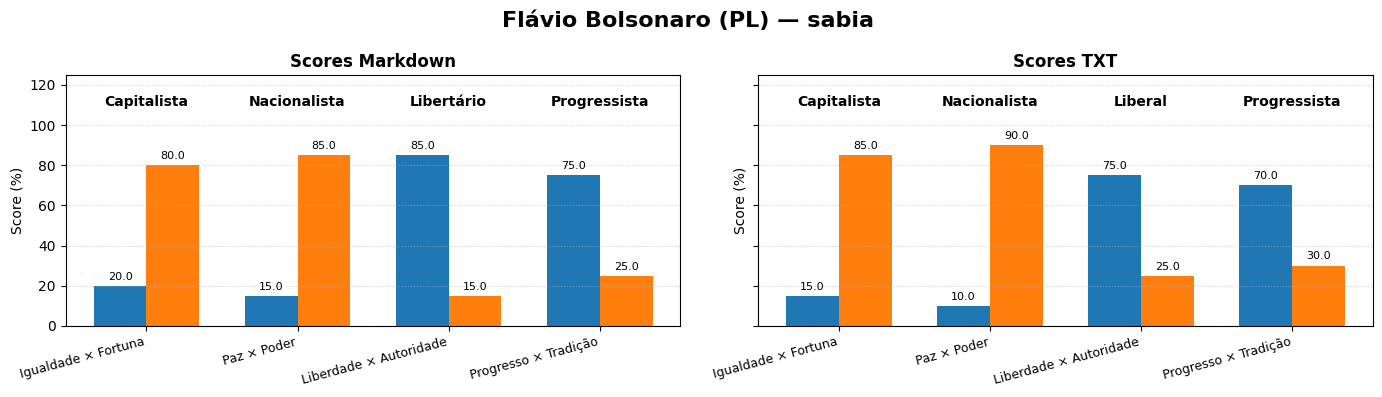

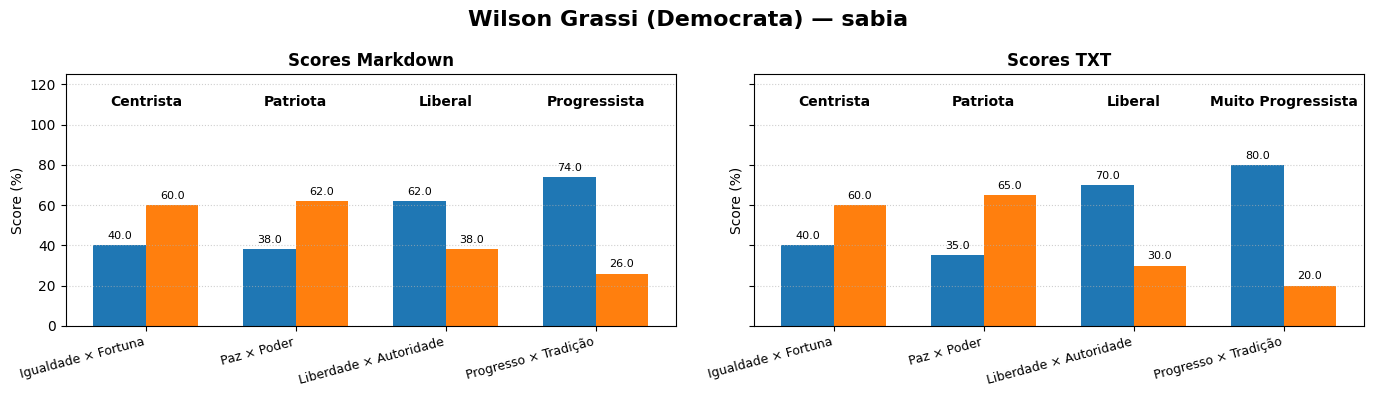

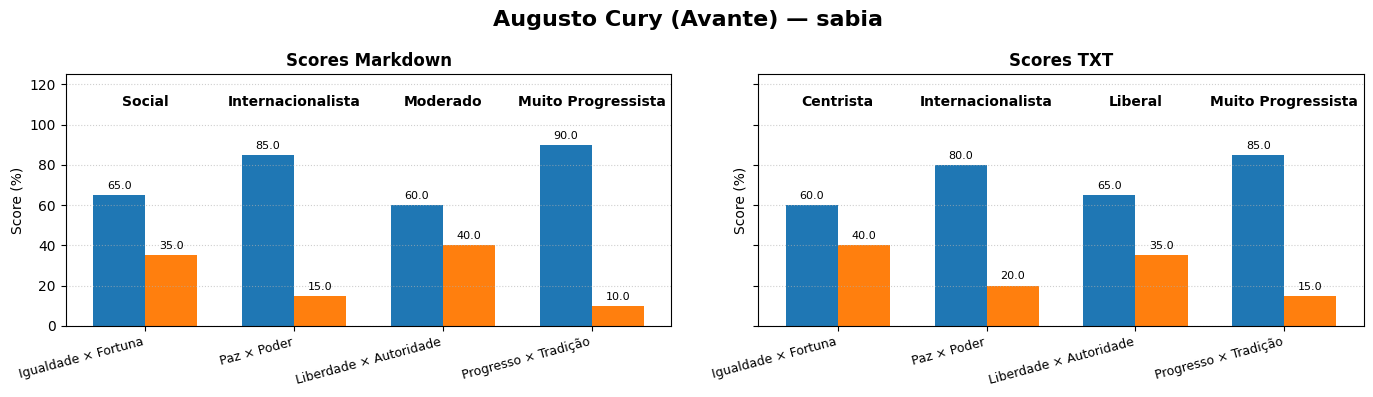

In [ ]:
for r in resultados_planos:
  nome = r["name"]

  values_md = Quiz8Values.calculate_8values(r["estimado_md"], IDEOLOGIES)
  values_txt = Quiz8Values.calculate_8values(r["estimado_txt"], IDEOLOGIES)

  fig1, (ax1_md, ax1_txt) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

  grafico_scores(values_md.scores.model_dump(), values_md.labels.to_list(), f"Scores Markdown", ax1_md)
  grafico_scores(values_txt.scores.model_dump(), values_txt.labels.to_list(), f"Scores TXT", ax1_txt)

  fig1.suptitle(
      f"{nome} — {modelo}",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout()
  plt.show()

###### Teste Perguntas Total

In [ ]:
resultados_planos = []

In [ ]:
for plano in planos_governo:
  name = plano["candidato"]
  md = plano["md"]
  txt = plano["txt"]

  if name in [r["name"] for r in resultados_planos]:
    continue

  quiz_md = await all_questions(md,llm=MODELS[modelo])
  await asyncio.sleep(60)
  quiz_txt = await all_questions(txt,llm=MODELS[modelo])
  await asyncio.sleep(60)

  resultado = {
    "name":name,
    "estimado_md": quiz_md.get_results(),
    "estimado_txt": quiz_txt.get_results()
  }

  resultados_planos.append(resultado)

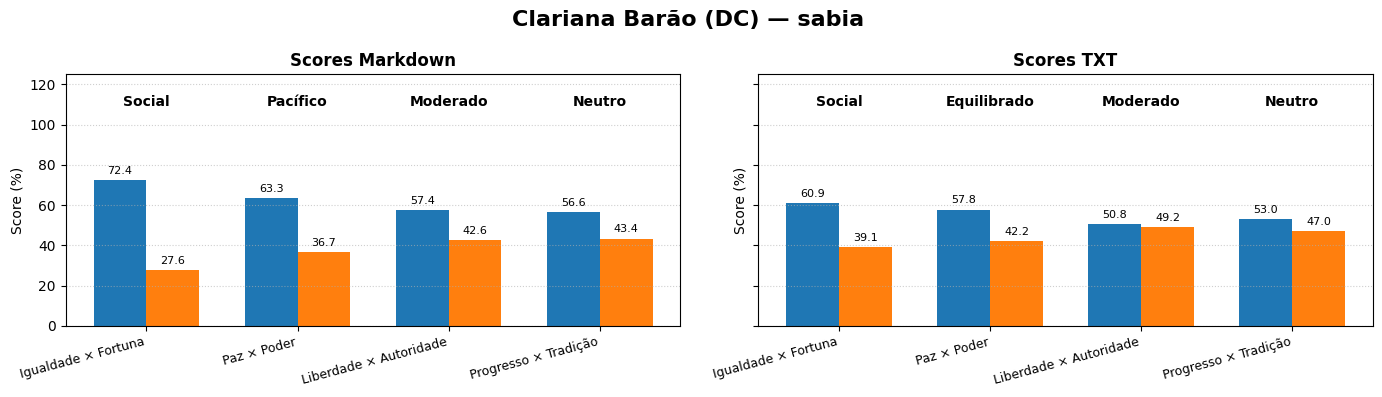

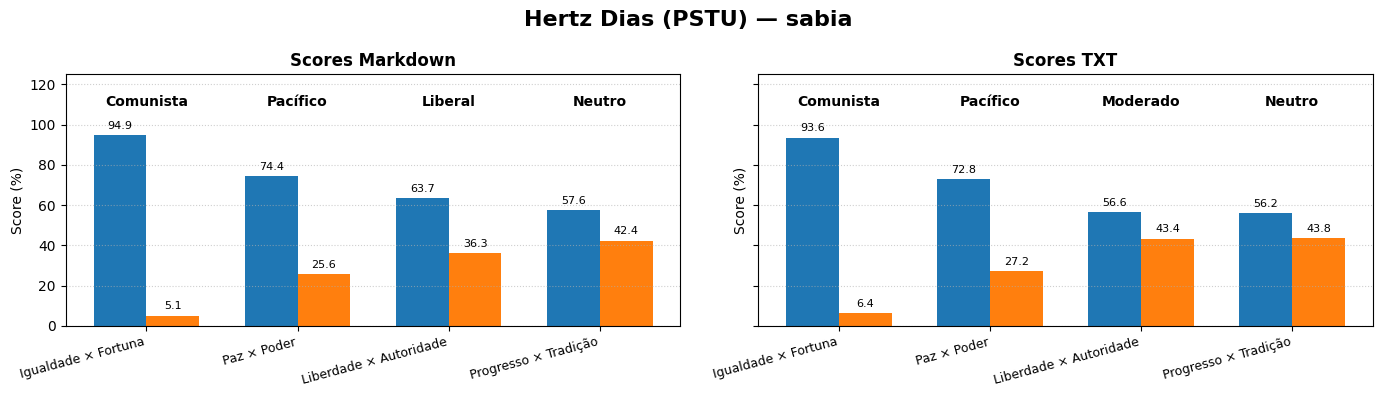

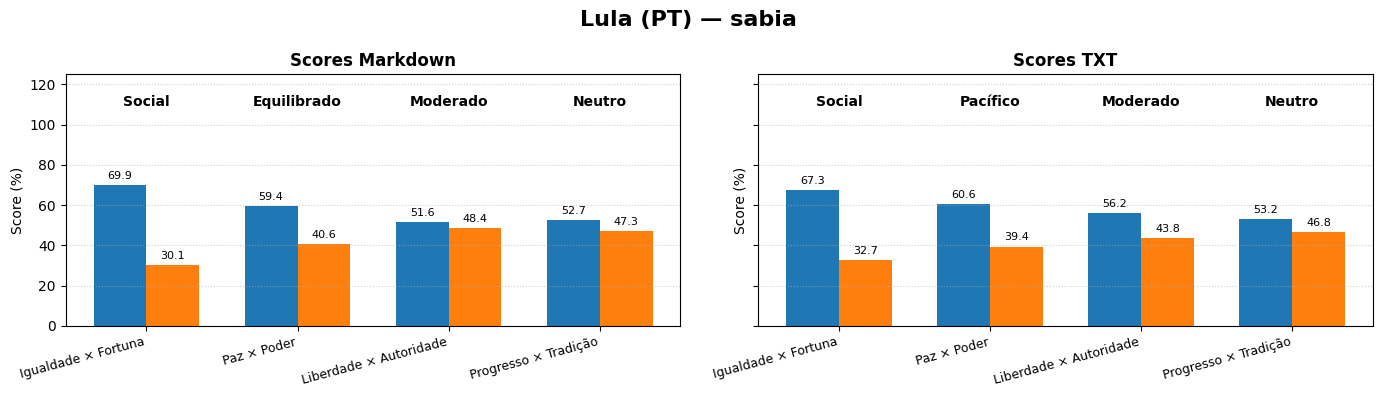

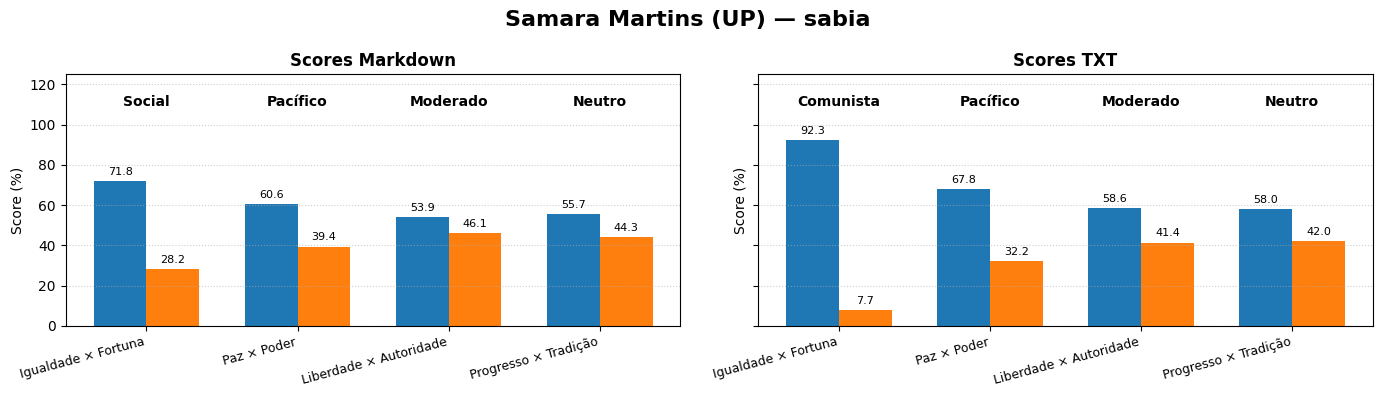

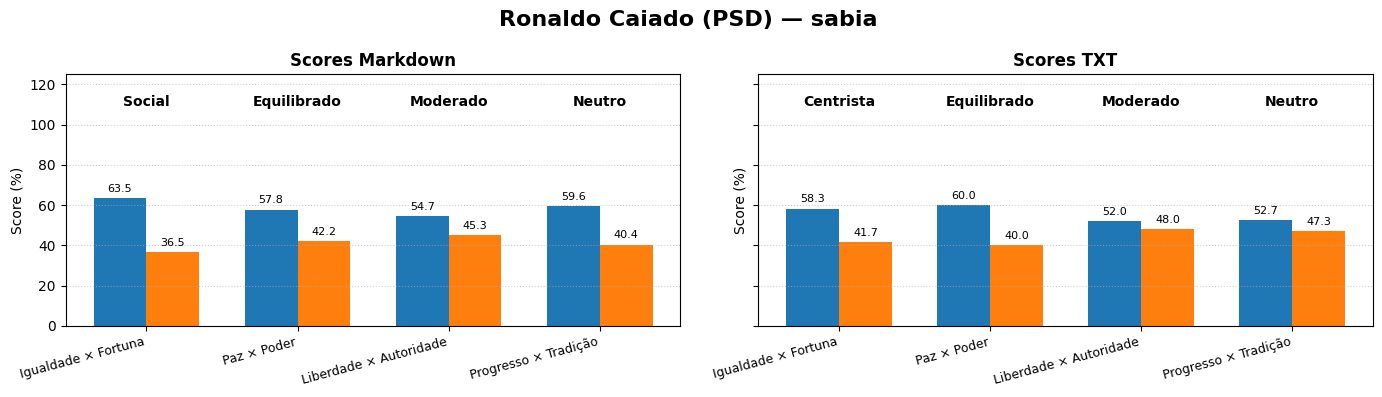

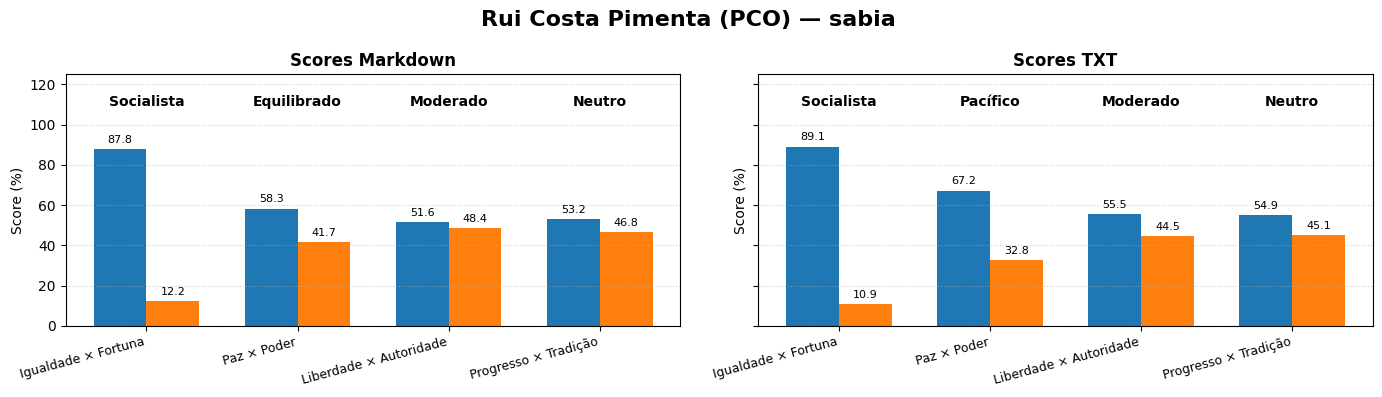

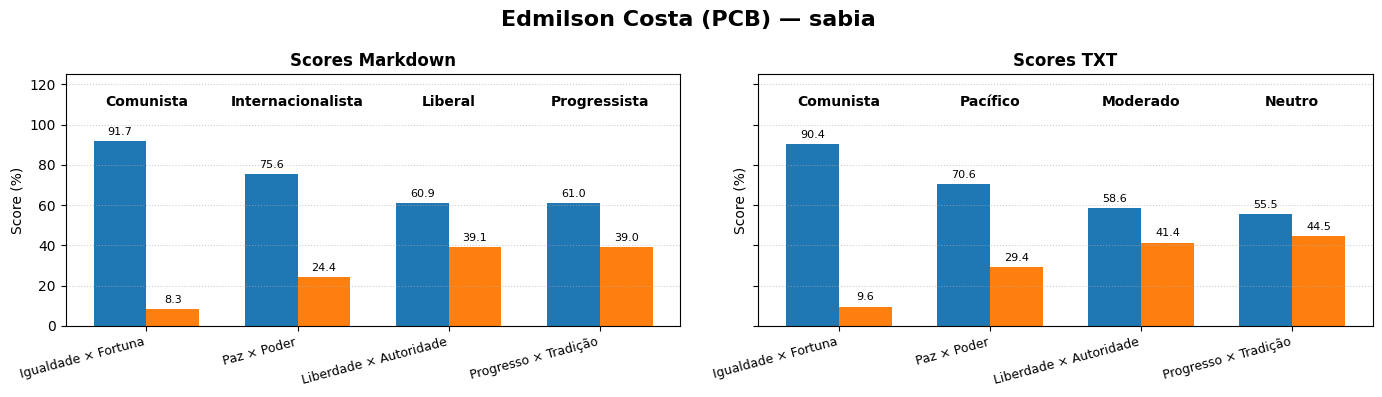

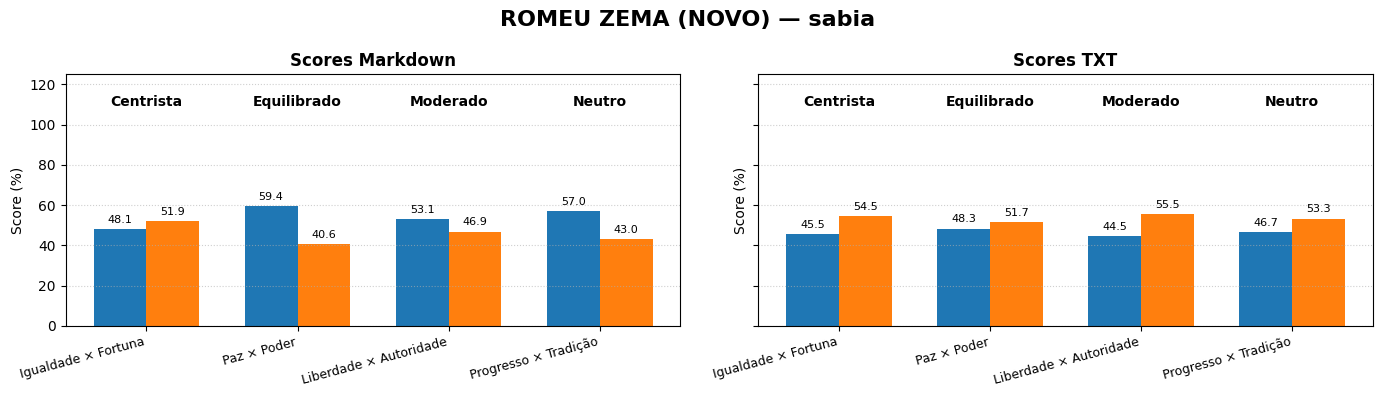

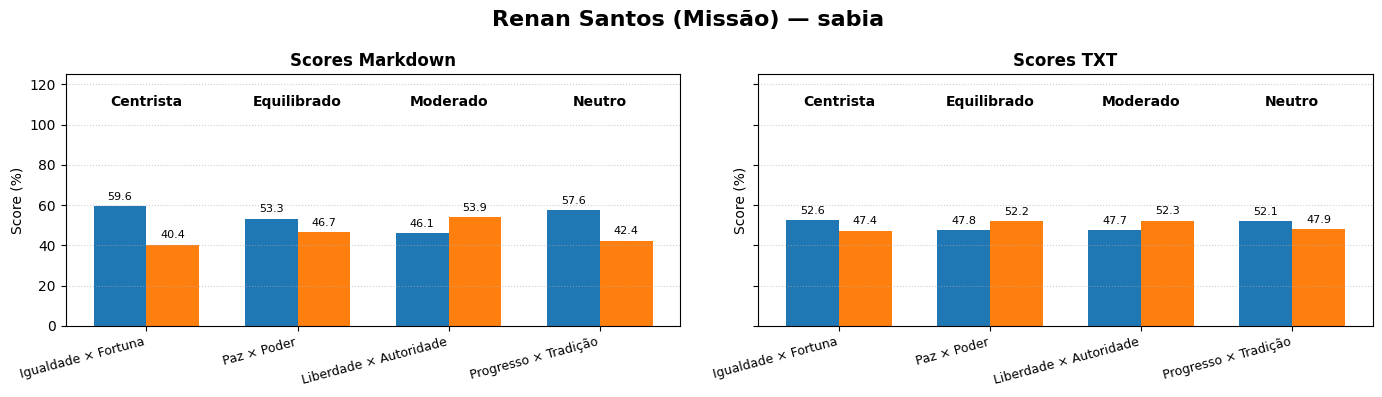

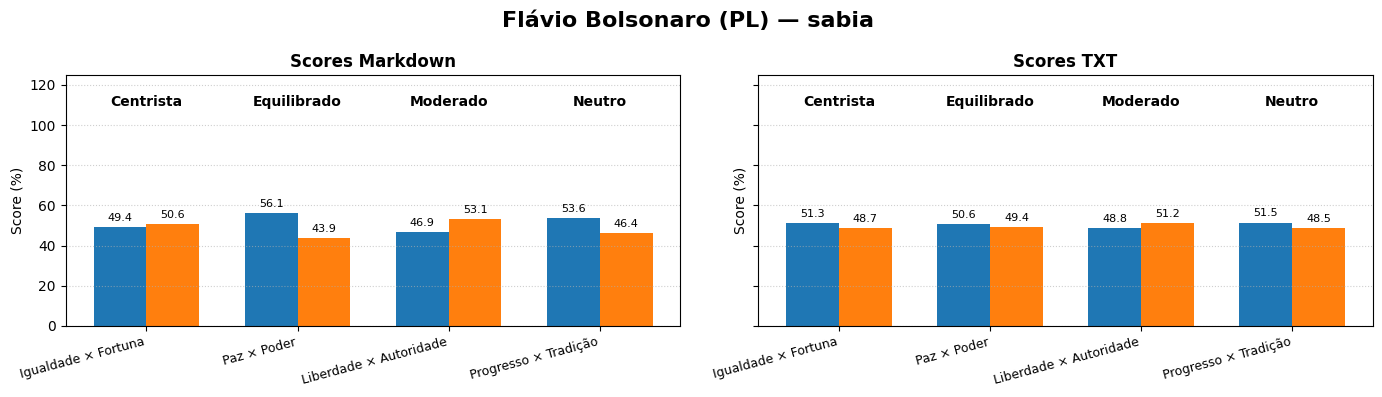

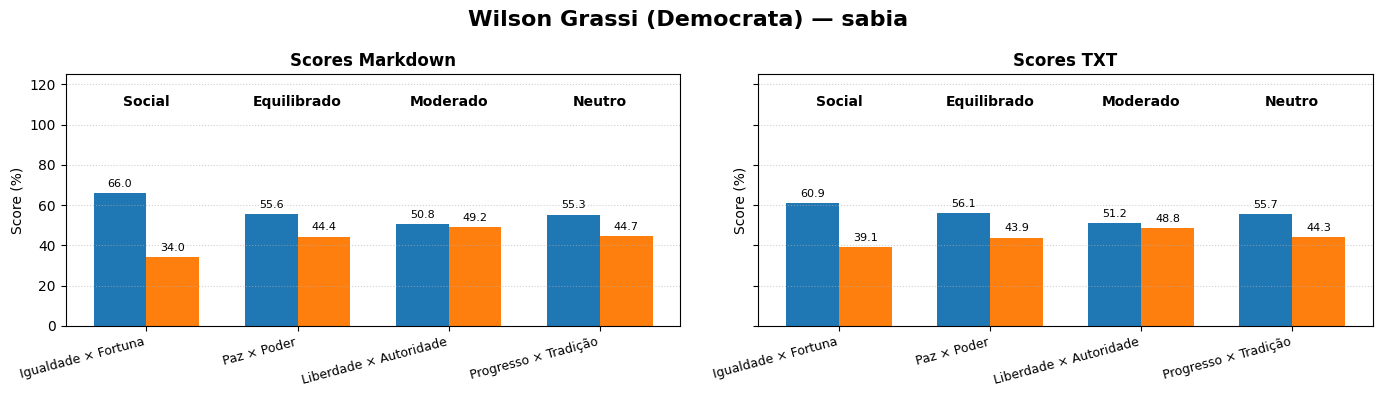

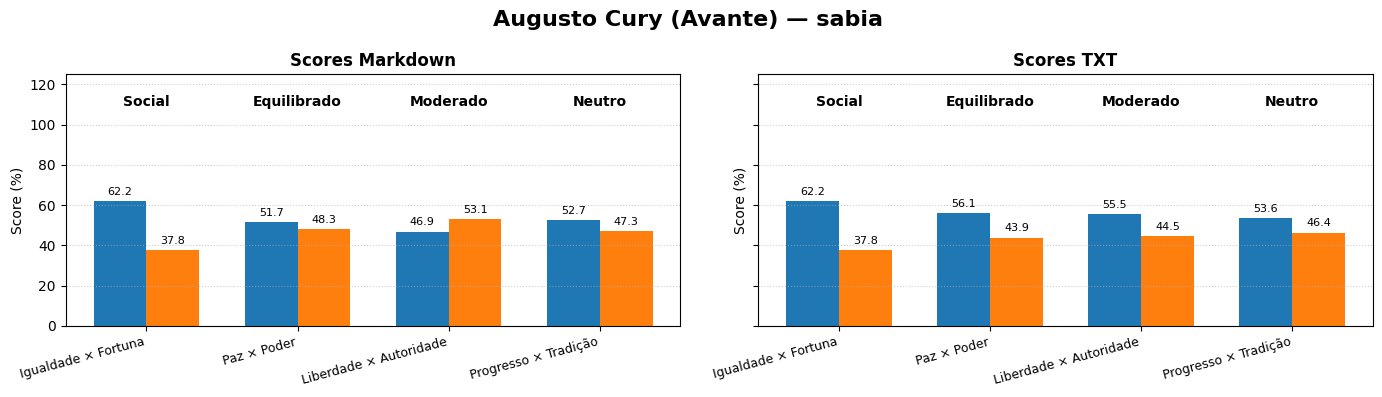

In [ ]:
for r in resultados_planos:
  nome = r["name"]

  values_md = Quiz8Values.calculate_8values(r["estimado_md"], IDEOLOGIES)
  values_txt = Quiz8Values.calculate_8values(r["estimado_txt"], IDEOLOGIES)

  fig1, (ax1_md, ax1_txt) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

  grafico_scores(values_md.scores.model_dump(), values_md.labels.to_list(), f"Scores Markdown", ax1_md)
  grafico_scores(values_txt.scores.model_dump(), values_txt.labels.to_list(), f"Scores TXT", ax1_txt)

  fig1.suptitle(
      f"{nome} — {modelo}",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout()
  plt.show()

##### Gemini

In [ ]:
modelo = "gemini_flash"

###### Teste Estimado

In [ ]:
resultados_planos = []

In [ ]:
for plano in planos_governo:
  name = plano["candidato"]
  md = plano["md"]
  txt = plano["txt"]

  if name in [r["name"] for r in resultados_planos]:
    continue

  try:
    estimado_md = await EstimateResultModel(md, llm=MODELS[modelo])
    estimado_txt = await EstimateResultModel(txt, llm=MODELS[modelo])

    resultado = {
      "name":name,
      "estimado_md": estimado_md,
      "estimado_txt": estimado_txt
    }

    resultados_planos.append(resultado)
  except Exception as e:
    print(e)
    continue

503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


In [ ]:
for r in resultados_planos:
  print(r)

{'name': 'Hertz Dias (PSTU)', 'estimado_md': Result(equality=98.0, peace=65.0, liberty=48.0, progress=92.0), 'estimado_txt': Result(equality=98.0, peace=65.0, liberty=60.0, progress=95.0)}
{'name': 'Lula (PT)', 'estimado_md': Result(equality=88.0, peace=65.0, liberty=55.0, progress=90.0), 'estimado_txt': Result(equality=88.0, peace=68.0, liberty=55.0, progress=88.0)}
{'name': 'Ronaldo Caiado (PSD)', 'estimado_md': Result(equality=38.0, peace=46.0, liberty=32.0, progress=58.0), 'estimado_txt': Result(equality=38.0, peace=38.0, liberty=32.0, progress=58.0)}
{'name': 'Renan Santos (Missão)', 'estimado_md': Result(equality=28.0, peace=22.0, liberty=20.0, progress=48.0), 'estimado_txt': Result(equality=30.0, peace=18.0, liberty=20.0, progress=48.0)}
{'name': 'ROMEU ZEMA (NOVO)', 'estimado_md': Result(equality=12.0, peace=42.0, liberty=52.0, progress=50.0), 'estimado_txt': Result(equality=15.0, peace=40.0, liberty=58.0, progress=58.0)}
{'name': 'Wilson Grassi (Democrata)', 'estimado_md': Res

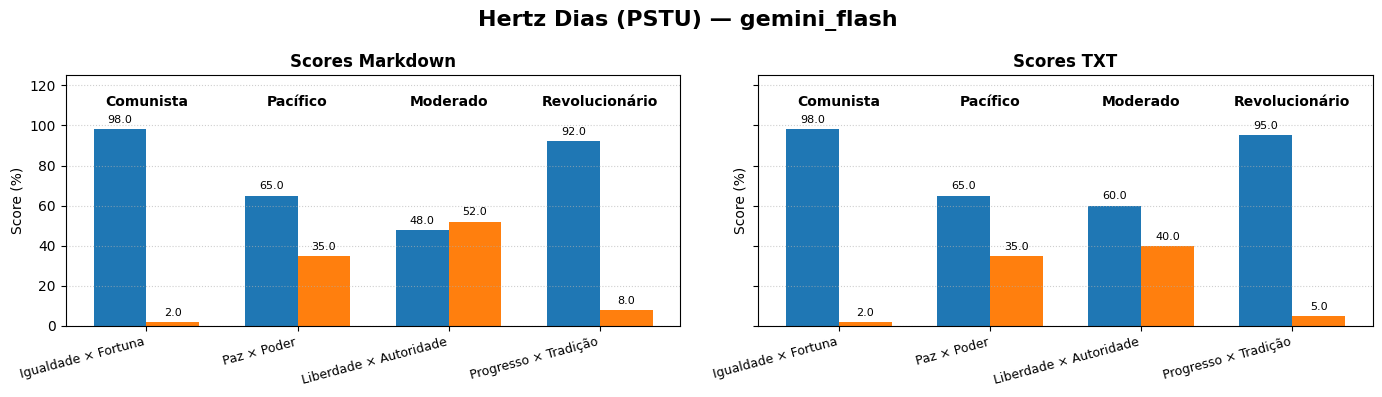

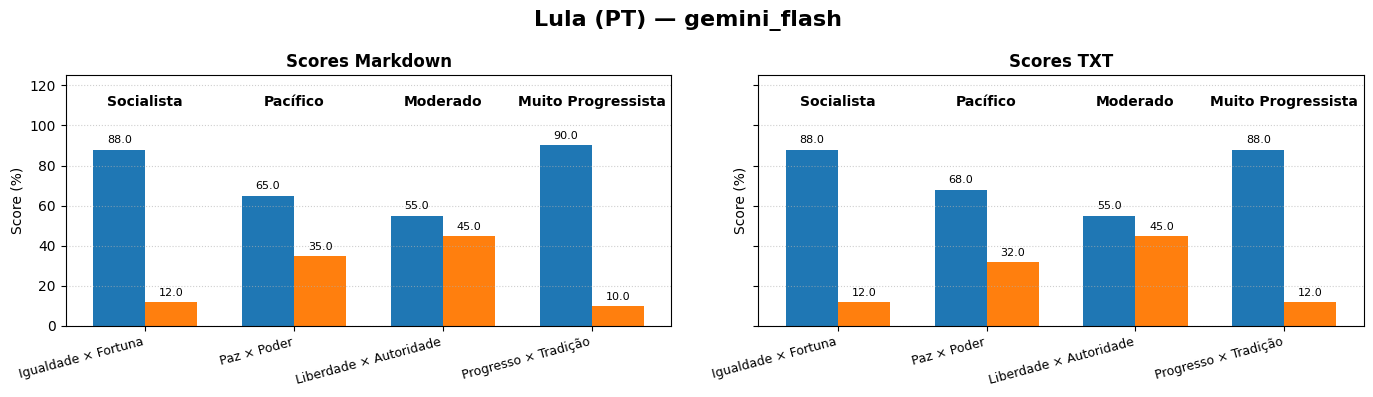

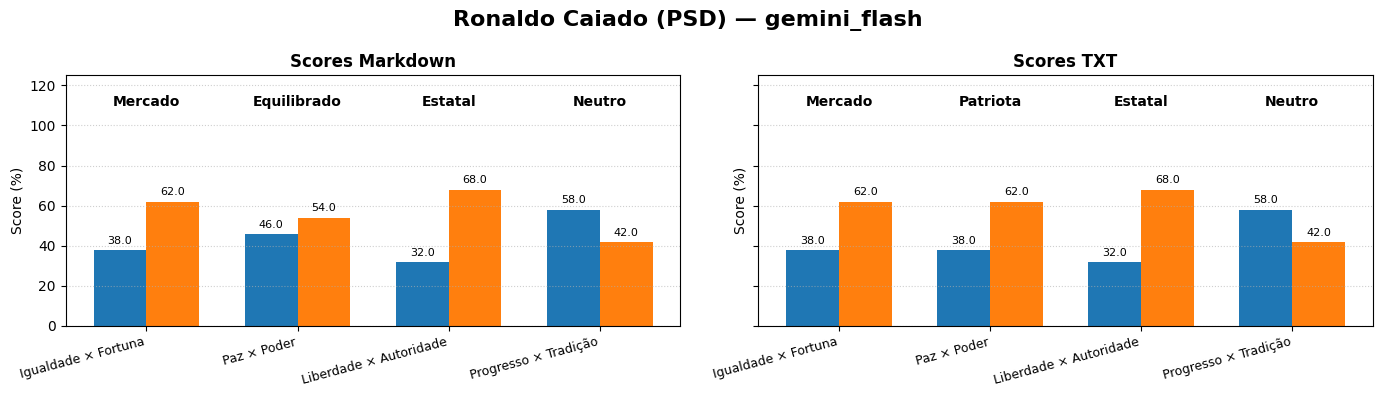

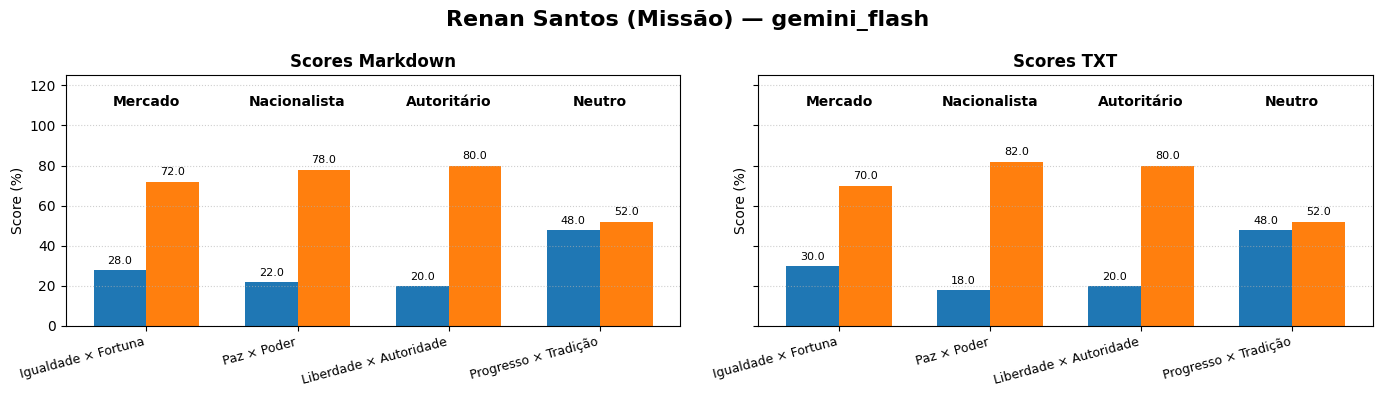

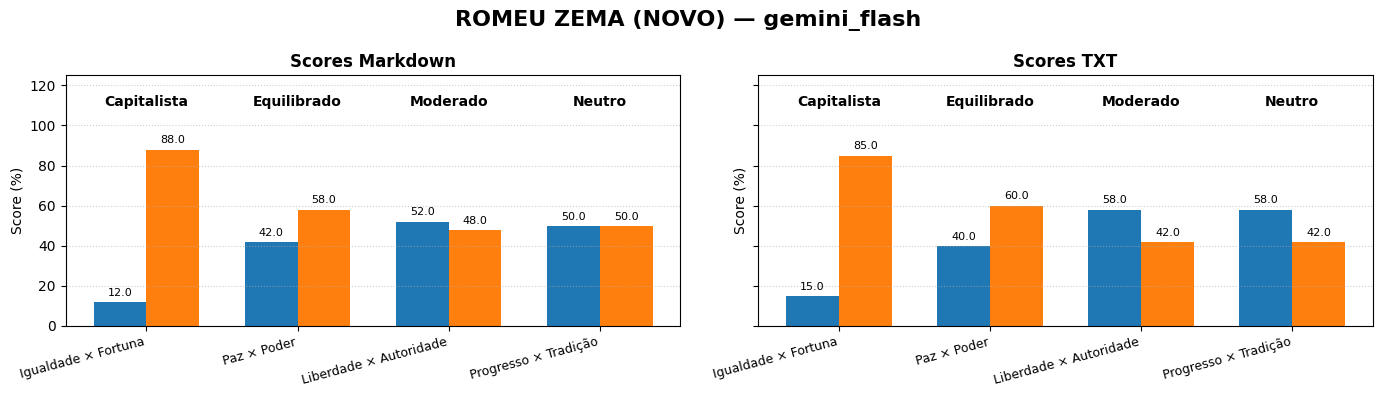

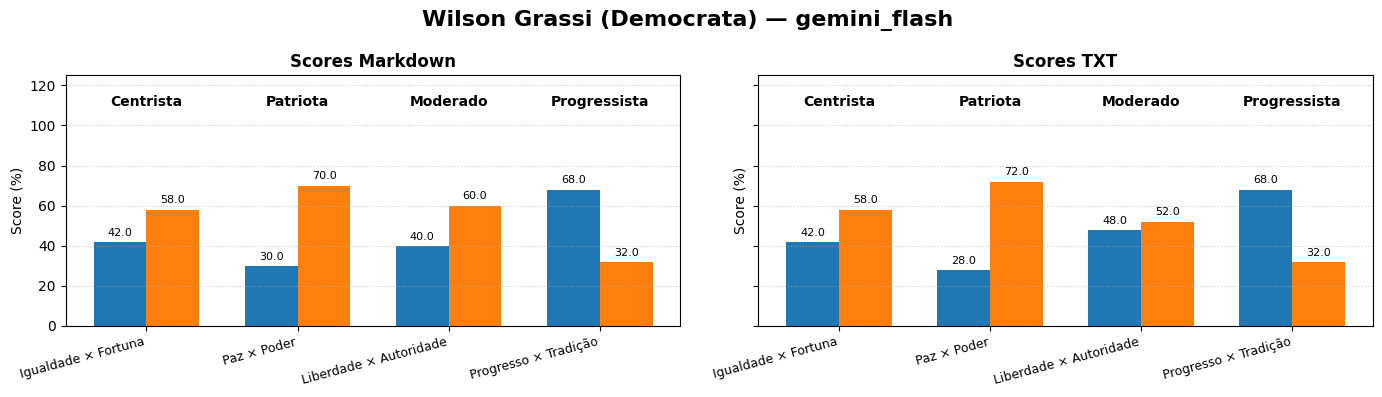

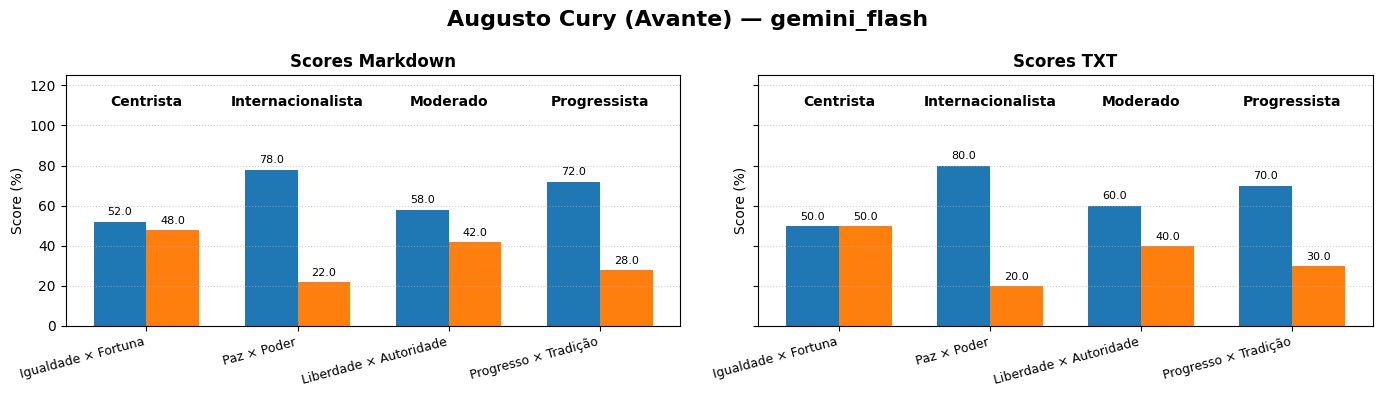

In [ ]:
for r in resultados_planos:
  nome = r["name"]

  values_md = Quiz8Values.calculate_8values(r["estimado_md"], IDEOLOGIES)
  values_txt = Quiz8Values.calculate_8values(r["estimado_txt"], IDEOLOGIES)

  fig1, (ax1_md, ax1_txt) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

  grafico_scores(values_md.scores.model_dump(), values_md.labels.to_list(), f"Scores Markdown", ax1_md)
  grafico_scores(values_txt.scores.model_dump(), values_txt.labels.to_list(), f"Scores TXT", ax1_txt)

  fig1.suptitle(
      f"{nome} — {modelo}",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout()
  plt.show()

###### Teste Perguntas Total

In [ ]:
resultados_planos = []

In [ ]:
for plano in planos_governo:
  name = plano["candidato"]
  md = plano["md"]
  txt = plano["txt"]

  if name in [r["name"] for r in resultados_planos]:
    continue

  quiz_md = await all_questions(md,llm=MODELS[modelo])
  await asyncio.sleep(60)
  quiz_txt = await all_questions(txt,llm=MODELS[modelo])
  await asyncio.sleep(60)

  resultado = {
    "name":name,
    "estimado_md": quiz_md.get_results(),
    "estimado_txt": quiz_txt.get_results()
  }

  resultados_planos.append(resultado)

In [ ]:
for r in resultados_planos:
  nome = r["name"]

  values_md = Quiz8Values.calculate_8values(r["estimado_md"], IDEOLOGIES)
  values_txt = Quiz8Values.calculate_8values(r["estimado_txt"], IDEOLOGIES)

  fig1, (ax1_md, ax1_txt) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

  grafico_scores(values_md.scores.model_dump(), values_md.labels.to_list(), f"Scores Markdown", ax1_md)
  grafico_scores(values_txt.scores.model_dump(), values_txt.labels.to_list(), f"Scores TXT", ax1_txt)

  fig1.suptitle(
      f"{nome} — {modelo}",
      fontsize=16,
      fontweight="bold"
  )

  plt.tight_layout()
  plt.show()

### Teste Similaridade

#### Variáveis


In [ ]:
plano = planos_governo[0]

In [ ]:
texto = plano["txt"]
md = plano["md"]

In [ ]:
TEXTOS_EIXOS_1 = {
  "economic": {
      "equality": "Aqueles com pontuações mais altas de Igualdade acreditam que grandes diferenças econômicas e sociais devem ser reduzidas e que a organização da economia deve favorecer uma distribuição mais equilibrada de riqueza, recursos e oportunidades entre os membros da sociedade. Eles tendem a considerar legítima a utilização de políticas públicas para corrigir desigualdades existentes, apoiando medidas redistributivas, tributação progressiva e maior proteção aos grupos economicamente menos favorecidos. Para essas pessoas, tratar todos de maneira exatamente idêntica nem sempre produz maior igualdade, pois diferenças econômicas anteriores podem exigir tratamentos distintos para que as disparidades sejam efetivamente reduzidas. Em pontuações mais altas, podem defender formas mais amplas de nivelamento econômico, maior propriedade pública ou socialização dos meios de produção, entendendo que determinadas formas de propriedade privada podem produzir ou perpetuar relações de desigualdade. De maneira geral, valorizam uma sociedade em que diferenças de riqueza e poder econômico sejam limitadas e não determinem excessivamente as condições de vida dos indivíduos.",
      "wealth": "Aqueles com pontuações mais altas de Mercados acreditam que indivíduos e empresas devem possuir ampla autonomia para realizar atividades econômicas, celebrar contratos, possuir propriedades e competir entre si. Eles tendem a considerar a iniciativa privada e a concorrência mecanismos importantes para organizar a economia e preferem que grande parte das decisões sobre produção, investimento e consumo seja tomada de maneira descentralizada, em vez de determinada diretamente pelo Estado. Essas pessoas geralmente valorizam a propriedade privada, a liberdade econômica e a possibilidade de cada indivíduo buscar seus próprios interesses dentro de regras jurídicas comuns. Tendem também a desconfiar de formas excessivas de planejamento e controle estatal da economia. Em pontuações mais altas, aproximam-se das concepções de laissez-faire, defendendo intervenção governamental bastante limitada e maior liberdade para o funcionamento do mercado. Isso não significa necessariamente rejeitar toda ação estatal: mesmo dentro da tradição liberal, podem ser aceitas intervenções destinadas a garantir contratos, impedir monopólios, arbitrar conflitos e proteger direitos."
  },
  "diplomatic": {
      "might": "Aqueles com pontuações mais altas de Nação acreditam que a comunidade nacional constitui uma referência política fundamental e que a soberania, a independência e a capacidade de autodeterminação de um povo devem ser preservadas. Eles tendem a possuir forte identificação com o próprio país e a valorizar elementos compartilhados de pertencimento, como história, cultura, língua, costumes, símbolos e instituições nacionais. Essas pessoas costumam considerar importante que as decisões fundamentais de um Estado sejam tomadas por sua própria população, com pouca interferência de outros Estados ou instituições externas. Também tendem a dar maior peso aos interesses nacionais quando estes entram em conflito com objetivos internacionais mais amplos. Em pontuações elevadas, a lealdade à nação pode adquirir prioridade sobre vínculos políticos, ideológicos ou supranacionais, e a unidade e a independência nacionais podem ser vistas como objetivos políticos especialmente importantes. Essa orientação pode favorecer políticas mais centradas na soberania nacional, mas não implica necessariamente militarismo, expansionismo ou hostilidade a outros povos.",
      "peace": "Aqueles com pontuações mais altas de Globo acreditam que os indivíduos fazem parte de uma comunidade humana mais ampla e que as fronteiras nacionais não devem ser o limite principal da cooperação política. Eles tendem a enfatizar os valores, interesses e problemas compartilhados entre diferentes povos e a considerar que diversas questões econômicas, sociais e políticas exigem soluções que ultrapassem a atuação isolada dos Estados. Essas pessoas normalmente apoiam cooperação internacional, integração entre países, instituições multilaterais e formas de direito supranacional. Também tendem a aceitar que determinados aspectos da soberania nacional sejam compartilhados quando isso permite solucionar problemas comuns ou estabelecer instituições políticas mais amplas. Em pontuações mais altas, podem favorecer estruturas federativas ou supranacionais capazes de exercer autoridade acima dos Estados em determinadas áreas. De maneira geral, dão maior importância à solidariedade internacional, à interdependência entre sociedades e à ideia de que a pertença à humanidade pode ter importância política comparável ou superior à pertença exclusiva a uma nação."
  },
  "state": {
      "liberty": "Aqueles com pontuações mais altas de Liberdade acreditam que os indivíduos e grupos devem possuir ampla autonomia para escolher seus próprios valores, opiniões e formas de vida, sem interferência desnecessária do poder político. Eles tendem a apoiar fortes garantias às liberdades civis, incluindo liberdade de expressão, imprensa, reunião, associação e participação política, além da existência de pluralismo social e político. Essas pessoas consideram importante que diferentes ideias, organizações e projetos de vida possam coexistir e competir dentro da sociedade, e normalmente defendem limites jurídicos claros ao poder do Estado. Também tendem a valorizar instituições representativas, opinião pública livre e mecanismos que permitam aos cidadãos questionar e controlar os governantes. Em pontuações mais altas, mostram maior resistência à censura, à vigilância excessiva e às tentativas do Estado de impor aos indivíduos determinada visão moral, política ou social. Para elas, o poder político deve principalmente garantir um espaço no qual cada pessoa possa exercer sua autonomia, desde que respeite os direitos dos demais.",
      "authority": "Aqueles com pontuações mais altas de Autoridade acreditam que a estabilidade da sociedade depende da existência de instituições fortes, hierarquia, disciplina e capacidade efetiva de comando por parte do poder político. Eles tendem a considerar a manutenção da ordem e da coesão social mais importante do que uma ampla autonomia individual em determinadas circunstâncias e aceitam com maior facilidade restrições impostas pelo Estado quando estas são apresentadas como necessárias à segurança ou à estabilidade. Essas pessoas podem favorecer governos com maior concentração de poder, instituições executivas fortes e menor influência de grupos ou organizações capazes de dificultar a execução das decisões governamentais. Em pontuações mais altas, podem considerar legítima uma redução da participação política, da autonomia das instituições representativas e da oposição em benefício de uma direção política mais centralizada. Também apresentam maior aceitação do uso de mecanismos coercitivos para assegurar o cumprimento das decisões. Nos extremos, essa orientação aproxima-se do autoritarismo, caracterizado pela primazia do comando, da hierarquia e da obediência sobre o consenso e a participação."
  },
  "society": {
      "progress": "Aqueles com pontuações mais altas de Progresso acreditam que a sociedade não precisa permanecer limitada pelas instituições e costumes herdados do passado e que os seres humanos são capazes de transformar conscientemente suas condições de vida. Eles tendem a confiar na razão, no conhecimento, na investigação científica e na crítica como instrumentos para avaliar e aperfeiçoar instituições sociais e políticas. Essas pessoas geralmente possuem maior disposição para questionar tradições quando estas são consideradas incompatíveis com novos conhecimentos, valores ou necessidades sociais e costumam enxergar a mudança como uma oportunidade de aperfeiçoamento, e não apenas como uma ameaça à estabilidade. Também atribuem importância à autonomia dos indivíduos para participar do desenvolvimento histórico e influenciar o rumo da sociedade. Em pontuações mais altas, demonstram maior confiança na capacidade humana de reformar profundamente instituições e superar estruturas consideradas injustas, irracionais ou ultrapassadas. Entretanto, progresso não significa simplesmente qualquer mudança ou avanço tecnológico: uma transformação só pode ser considerada progresso quando é avaliada em relação a algum objetivo ou condição considerada melhor do que a anterior.",
      "tradition": "Aqueles com pontuações mais altas de Tradição acreditam que instituições, costumes e valores desenvolvidos historicamente possuem importância própria e não devem ser abandonados simplesmente em favor de novas ideias ou projetos de transformação social. Eles tendem a valorizar continuidade, estabilidade, experiência acumulada e mudanças graduais, demonstrando maior cautela diante de reformas profundas que pretendam reorganizar rapidamente a sociedade a partir de princípios abstratos. Essas pessoas costumam considerar que a ordem social contém práticas e instituições que foram construídas ao longo do tempo e cuja função nem sempre pode ser substituída por planejamento racional. Podem também atribuir maior importância à religião, à moral tradicional, à família, à autoridade e às formas históricas de organização social, embora nenhuma dessas características seja obrigatória isoladamente. Em pontuações mais altas, mostram maior preferência pela preservação das estruturas existentes e maior resistência a transformações sociais radicais. Isso não significa necessariamente rejeitar toda mudança, mas favorecê-la quando ocorre de maneira gradual e preserva elementos considerados fundamentais da ordem social."
  }
}

In [ ]:
TEXTOS_EIXOS_2 = {
    "economic": {
        "equality": """
        Redução das desigualdades econômicas e sociais.
        Distribuição mais equilibrada de renda, riqueza, recursos e oportunidades.
        Tributação progressiva e políticas de redistribuição de renda.
        Ação do Estado para reduzir desigualdades econômicas e remover obstáculos sociais.
        Proteção econômica aos grupos socialmente e economicamente menos favorecidos.
        Limitação da concentração de riqueza e de poder econômico.
        Maior participação pública, coletiva ou social na propriedade e na organização da economia.
        Priorização da igualdade econômica mesmo quando isso exige maior intervenção estatal.
        """,

        "wealth": """
        Livre iniciativa econômica e propriedade privada.
        Autonomia dos indivíduos e das empresas para tomar decisões econômicas.
        Concorrência como mecanismo de organização da economia.
        Liberdade de produção, investimento, contratação e consumo.
        Organização descentralizada da atividade econômica por mecanismos de mercado.
        Redução da intervenção direta e do planejamento estatal da economia.
        Defesa da propriedade particular e da iniciativa econômica individual.
        Privatização, desregulamentação e maior liberdade para o funcionamento dos mercados.
        Intervenção estatal limitada à garantia de direitos, contratos e regras de concorrência.
        """
    },

    "diplomatic": {
        "might": """
        Soberania e independência do Estado nacional.
        Autodeterminação política dos povos.
        Prioridade das decisões tomadas pela própria comunidade nacional.
        Valorização da identidade, história, cultura e instituições nacionais.
        Preservação da autonomia nacional diante de interferências externas.
        Prioridade dos interesses nacionais quando entram em conflito com interesses internacionais.
        Manutenção da soberania estatal sobre decisões políticas fundamentais.
        Valorização da coesão e da unidade nacional.
        """,

        "peace": """
        Cooperação política entre diferentes povos e Estados.
        Solidariedade e interdependência internacional.
        Soluções multilaterais para problemas que ultrapassam as fronteiras nacionais.
        Integração econômica, jurídica e política entre países.
        Fortalecimento de instituições internacionais e supranacionais.
        Compartilhamento de parcelas da soberania para solucionar problemas comuns.
        Construção de estruturas federativas ou supranacionais acima dos Estados.
        Valorização de interesses e direitos universais para além da pertença nacional.
        Maior integração política da humanidade.
        """
    },

    "state": {
        "liberty": """
        Proteção da autonomia individual diante do poder político.
        Garantia das liberdades civis e políticas.
        Liberdade de expressão, imprensa, reunião, associação e participação política.
        Pluralismo político, social e ideológico.
        Limitação jurídica do poder do Estado.
        Existência de diferentes grupos, organizações e centros de poder autônomos.
        Proteção dos direitos individuais contra interferências e restrições estatais.
        Controle dos governantes por instituições representativas e pela participação dos cidadãos.
        Resistência à censura, vigilância excessiva e concentração do poder político.
        """,

        "authority": """
        Concentração e centralização do poder político.
        Hierarquia, disciplina e obediência como princípios de organização social.
        Prioridade da ordem e da estabilidade sobre a autonomia individual.
        Fortalecimento da autoridade do Estado e do poder executivo.
        Redução da autonomia de grupos e instituições diante do governo.
        Restrição do pluralismo e da oposição política.
        Limitação da participação política quando considerada incompatível com a ordem.
        Uso de mecanismos coercitivos para assegurar o cumprimento das decisões políticas.
        Subordinação dos indivíduos e grupos à autoridade política central.
        """
    },

    "society": {
        "progress": """
        Transformação consciente das instituições sociais e políticas.
        Confiança na capacidade humana de melhorar a sociedade.
        Uso da razão, da ciência, do conhecimento e da crítica para avaliar instituições existentes.
        Questionamento de tradições consideradas injustas, irracionais ou ultrapassadas.
        Mudança social como possibilidade de aperfeiçoamento das condições humanas.
        Reforma de instituições diante de novos conhecimentos e necessidades sociais.
        Participação ativa dos indivíduos na transformação histórica da sociedade.
        Superação de estruturas sociais consideradas inadequadas.
        Valorização do aperfeiçoamento futuro em relação às condições existentes.
        """,

        "tradition": """
        Preservação de instituições, costumes e valores desenvolvidos historicamente.
        Valorização da continuidade e da estabilidade social.
        Preferência por mudanças graduais em vez de transformações profundas ou abruptas.
        Confiança na experiência histórica acumulada pelas instituições sociais.
        Cautela diante de projetos de reorganização racional e radical da sociedade.
        Preservação de estruturas sociais consideradas fundamentais para a ordem.
        Valorização da tradição, da família, da religião, da autoridade e da moral histórica.
        Resistência à ruptura com práticas e instituições consolidadas.
        Mudança social condicionada à preservação de elementos essenciais da ordem existente.
        """
    }
}

In [ ]:
RELEVANCE_ANCHORS = {

    "economic": [
        "tributação e impostos",
        "redistribuição de renda",
        "mercado e iniciativa privada",
        "privatização e empresas estatais",
        "regulação econômica",
        "atuação do Estado na economia",
    ],

    "diplomatic": [
        "política externa",
        "relações internacionais",
        "soberania nacional",
        "cooperação internacional",
        "multilateralismo",
        "integração entre países",
    ],

    "state": [
        "liberdades civis",
        "liberdade de expressão",
        "poder do Estado",
        "pluralismo político",
        "vigilância estatal",
        "concentração de poder",
    ],

    "society": [
        "tradições e costumes",
        "mudança social",
        "família e religião",
        "valores sociais",
        "reformas sociais",
        "transformações culturais",
    ],
}

#### Classe

In [ ]:
AXES = {
    "economic": ("equality", "wealth"),
    "diplomatic": ("peace", "might"),
    "state": ("liberty", "authority"),
    "society": ("progress", "tradition"),
}


class Semantic8Values:

    def __init__(
        self,
        textos_eixos: dict,
        model_name: str = "intfloat/multilingual-e5-base",
        temperature: float = 0.05,
    ):
        self.textos_eixos = textos_eixos
        self.temperature = temperature

        self.model = SentenceTransformer(
            model_name
        )

        self.axes = AXES

        self.axis_embeddings = self._create_axis_embeddings()


    def _create_axis_embeddings(self):

        embeddings = {}

        for axis, (positive, negative) in self.axes.items():

            positive_text = (
                self.textos_eixos[axis][positive]
            )

            negative_text = (
                self.textos_eixos[axis][negative]
            )

            positive_embedding = self.model.encode(
                f"passage: {positive_text}",
                normalize_embeddings=True,
            )

            negative_embedding = self.model.encode(
                f"passage: {negative_text}",
                normalize_embeddings=True,
            )

            direction = positive_embedding - negative_embedding
            direction =  direction / np.linalg.norm(direction)


            embeddings[axis] = {
                positive: positive_embedding,
                negative: negative_embedding,
                "direction": direction,
            }

        return embeddings


    def _calculate_axis(
        self,
        text_embedding,
        axis,
    ):
        positive, negative = self.axes[axis]

        positive_embedding = (
            self.axis_embeddings[axis][positive]
        )

        negative_embedding = (
            self.axis_embeddings[axis][negative]
        )

        direction = (
            self.axis_embeddings[axis]["direction"]
        )

        positive_similarity = float(
            np.dot(
                text_embedding,
                positive_embedding,
            )
        )

        negative_similarity = float(
            np.dot(
                text_embedding,
                negative_embedding,
            )
        )

        margin = (
            positive_similarity
            - negative_similarity
        )

        projection = float(
            np.dot(
                text_embedding,
                direction,
            )
        )

        return {
            "positive": positive,
            "negative": negative,
            "positive_similarity": positive_similarity,
            "negative_similarity": negative_similarity,
            "margin": margin,
            "projection": projection,
        }

    def _aggregate_axis(
        self,
        chunk_results: list[dict],
        axis: str,
    ):

        projections = [
            chunk["results"][axis]["projection"]
            for chunk in chunk_results
        ]

        margins = [
            chunk["results"][axis]["margin"]
            for chunk in chunk_results
        ]

        token_counts = [
            chunk["token_count"]
            for chunk in chunk_results
        ]

        projection = float(
            np.average(
                projections,
                weights=token_counts,
            )
        )

        margin = float(
            np.average(
                margins,
                weights=token_counts,
            )
        )

        score_margin = self._value_to_score(
            margin
        )

        score_projection = self._value_to_score(
            projection
        )

        return {
            "projection": projection,
            "margin" : margin,
            "score_margin": score_margin,
            "score_projection":score_projection
        }

    def _value_to_score(
        self,
        margin: float,
    ) -> float:

        return 100.0 / (
            1.0
            + math.exp(
                -margin / self.temperature
            )
        )

    def predict(
            self,
            text: str,
    ):
      chunks = self.chunk_text(text)

      chunk_results = []

      for chunk in chunks:

          text_embedding = self.model.encode(
              f"query: {chunk['text']}",
              normalize_embeddings=True,
          )

          results = {}

          for axis in self.axes:

              results[axis] = self._calculate_axis(
                  text_embedding,
                  axis,
              )

          chunk_results.append({
              "text": chunk["text"],
              "token_count": chunk["token_count"],
              "results": results,
          })

      results = {}

      for axis in self.axes:

          results[axis] = self._aggregate_axis(
              chunk_results,
              axis,
          )

      return results

    def chunk_text(
        self,
        text: str,
        chunk_size: int = 450,
        overlap: int = 50,
    ) -> list[dict]:

        tokens = self.model.tokenizer.encode(
            text,
            add_special_tokens=False,
        )

        chunks = []

        step = chunk_size - overlap

        for start in range(0, len(tokens), step):
            end = start + chunk_size

            chunk_tokens = tokens[start:end]

            chunk_text = self.model.tokenizer.decode(
                chunk_tokens,
                skip_special_tokens=True,
            )

            chunks.append({
                "text": chunk_text,
                "token_count": len(chunk_tokens),
            })

            if end >= len(tokens):
                break

        return chunks

    def plot_embeddings(
        self,
        text: str,
        annotate_chunks: bool = True,
    ):
        chunks = self.chunk_text(text)

        embeddings = []
        labels = []
        types = []

        # Embeddings dos polos
        for axis, (positive, negative) in self.axes.items():
            embeddings.append(
                self.axis_embeddings[axis][positive]
            )
            labels.append(f"{axis}: {positive}")
            types.append("positive")

            embeddings.append(
                self.axis_embeddings[axis][negative]
            )
            labels.append(f"{axis}: {negative}")
            types.append("negative")

        # Embeddings dos chunks do documento
        for index, chunk in enumerate(chunks):
            chunk_embedding = self.model.encode(
                f"query: {chunk['text']}",
                normalize_embeddings=True,
            )

            embeddings.append(chunk_embedding)
            labels.append(f"Chunk {index + 1}")
            types.append("chunk")

        embeddings = np.asarray(embeddings)

        # Redução de dimensionalidade
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)

        colors = {
            "positive": "#2ca02c",
            "negative": "#d62728",
            "chunk": "#1f77b4",
        }

        markers = {
            "positive": "o",
            "negative": "s",
            "chunk": "x",
        }

        fig, ax = plt.subplots(figsize=(12, 8))

        for point_type in ["positive", "negative", "chunk"]:
            indices = [
                index
                for index, value in enumerate(types)
                if value == point_type
            ]

            ax.scatter(
                embeddings_2d[indices, 0],
                embeddings_2d[indices, 1],
                c=colors[point_type],
                marker=markers[point_type],
                s=100 if point_type != "chunk" else 60,
                label=point_type.capitalize(),
                alpha=0.8,
            )

        for index, label in enumerate(labels):
            if types[index] != "chunk" or annotate_chunks:
                ax.annotate(
                    label,
                    (
                        embeddings_2d[index, 0],
                        embeddings_2d[index, 1],
                    ),
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=8,
                )

        explained_variance = pca.explained_variance_ratio_.sum() * 100

        ax.set_title(
            "Visualização 2D dos embeddings\n"
            f"Variância explicada pelo PCA: {explained_variance:.2f}%"
        )
        ax.set_xlabel("Componente principal 1")
        ax.set_ylabel("Componente principal 2")
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.legend()
        ax.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()

        return embeddings_2d, labels

    def plot_axis_positions(
          self,
          text: str,
    ):
        chunks = self.chunk_text(text)

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(14, 8),
        )

        axes = axes.flatten()

        for ax, axis in zip(axes, self.axes):
            positive, negative = self.axes[axis]

            positions = []
            token_counts = []

            for chunk in chunks:
                text_embedding = self.model.encode(
                    f"query: {chunk['text']}",
                    normalize_embeddings=True,
                )

                result = self._calculate_axis(
                    text_embedding,
                    axis,
                )

                positions.append(result["projection"])
                token_counts.append(chunk["token_count"])

            aggregate_position = np.average(
                positions,
                weights=token_counts,
            )

            ax.scatter(
                positions,
                np.zeros(len(positions)),
                color="#1f77b4",
                alpha=0.65,
                s=60,
                label="Chunks",
            )

            for index, position in enumerate(positions):
                ax.annotate(
                    str(index + 1),
                    (position, 0),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha="center",
                    fontsize=8,
                )

            ax.scatter(
                aggregate_position,
                0,
                color="#ff7f0e",
                marker="D",
                s=140,
                label="Documento agregado",
                zorder=5,
            )

            max_abs = max(
                max(np.abs(positions), default=0),
                abs(aggregate_position),
                0.05,
            )

            limit = max_abs * 1.25

            ax.set_xlim(-limit, limit)
            ax.set_ylim(-0.2, 0.2)

            ax.axvline(
                0,
                color="black",
                linestyle="--",
                linewidth=1,
            )

            ax.set_title(axis.capitalize())
            ax.set_xlabel(
                f"{negative}  ←  posição no eixo  →  {positive}"
            )
            ax.set_yticks([])
            ax.grid(axis="x", alpha=0.25)
            ax.legend(fontsize=8)

        plt.suptitle(
            "Posição semântica dos chunks nos eixos do 8values",
            fontsize=14,
            fontweight="bold",
        )

        plt.tight_layout()
        plt.show()

    def plot_embeddings_3d_interactive(
        self,
        text: str,
    ):
        chunks = self.chunk_text(text)

        embeddings = []
        labels = []
        point_types = []

        for axis, (positive, negative) in self.axes.items():
            embeddings.extend([
                self.axis_embeddings[axis][positive],
                self.axis_embeddings[axis][negative],
            ])

            labels.extend([
                f"{axis}: {positive}",
                f"{axis}: {negative}",
            ])

            point_types.extend([
                "Positive",
                "Negative",
            ])

        for index, chunk in enumerate(chunks):
            embedding = self.model.encode(
                f"query: {chunk['text']}",
                normalize_embeddings=True,
            )

            embeddings.append(embedding)
            labels.append(f"Chunk {index + 1}")
            point_types.append("Chunk")

        pca = PCA(n_components=3)

        coordinates = pca.fit_transform(
            np.asarray(embeddings)
        )

        dataframe = pd.DataFrame({
            "PC1": coordinates[:, 0],
            "PC2": coordinates[:, 1],
            "PC3": coordinates[:, 2],
            "label": labels,
            "type": point_types,
        })

        figure = px.scatter_3d(
            dataframe,
            x="PC1",
            y="PC2",
            z="PC3",
            color="type",
            symbol="type",
            hover_name="label",
            color_discrete_map={
                "Positive": "#2ca02c",
                "Negative": "#d62728",
                "Chunk": "#1f77b4",
            },
            title=(
                "Embeddings reduzidos para 3D — "
                f"variância explicada: "
                f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
            ),
        )

        figure.update_traces(
            marker={"size": 7}
        )

        figure.show()

        return dataframe

#### Métodos

In [ ]:
# Campo do 8values -> nome do eixo no Semantic8Values
EFFECT_TO_AXIS = {
    "econ": "economic",
    "dipl": "diplomatic",
    "govt": "state",
    "scty": "society",
}

def test_semantic8values(semantic: Semantic8Values):

  resultados_questions = []

  for question in QUESTIONS:

      question_id = question.id
      texto = question.question
      effects = question.effect.model_dump()

      # Executa o embedding apenas UMA vez para a pergunta
      resultado_semantico = semantic.predict(texto)

      # Uma mesma pergunta pode afetar vários eixos
      for effect_name, effect_value in effects.items():

          # effect = 0 significa que essa pergunta
          # não deveria afetar esse eixo
          # if effect_value == 0:
          #     continue

          if abs(effect_value) != 10:
            continue

          axis = EFFECT_TO_AXIS[effect_name]

          positive, negative = AXES[axis]

          resultado_axis = resultado_semantico[axis]

          margin = resultado_axis["margin"]
          projection = resultado_axis["projection"]

          # -----------------------------------------
          # Qual lado o 8values espera?
          # -----------------------------------------

          if effect_value > 0:
              expected = positive
          else:
              expected = negative

          # -----------------------------------------
          # Qual lado o embedding encontrou?
          # -----------------------------------------

          predicted_margin = (
              positive
              if margin > 0
              else negative
          )

          predicted_projection = (
              positive
              if projection > 0
              else negative
          )

          resultados_questions.append({
              "id": question_id,
              "axis": axis,
              "effect": effect_value,
              "expected": expected,

              "question": texto,

              "margin": margin,
              "projection": projection,

              "score_margin": resultado_axis["score_margin"],
              "score_projection": resultado_axis["score_projection"],

              "predicted_margin": predicted_margin,
              "predicted_projection": predicted_projection,

              "correct_margin": (
                  predicted_margin == expected
              ),

              "correct_projection": (
                  predicted_projection == expected
              ),
          })


  df_questions = pd.DataFrame(
      resultados_questions
  )

  return df_questions

def resumo_testes(df_questions):
  resumo = (
    df_questions
    .groupby("axis")
    .agg(
        quantidade=("id", "count"),

        acertos_margin=(
            "correct_margin",
            "sum"
        ),

        acertos_projection=(
            "correct_projection",
            "sum"
        ),
    )
)

  resumo["accuracy_margin"] = (
      resumo["acertos_margin"]
      / resumo["quantidade"]
  )

  resumo["accuracy_projection"] = (
      resumo["acertos_projection"]
      / resumo["quantidade"]
  )

  return resumo

In [ ]:
def details_to_result(details, campo):
    result = Result(
        equality=details["economic"][campo],
        peace=details["diplomatic"][campo],
        liberty=details["state"][campo],
        progress=details["society"][campo],
    )

    return result

#### Teste


In [ ]:
semantic_1 = Semantic8Values(TEXTOS_EIXOS_1)
semantic_2 = Semantic8Values(TEXTOS_EIXOS_2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3311 > 512). Running this sequence through the model will result in indexing errors


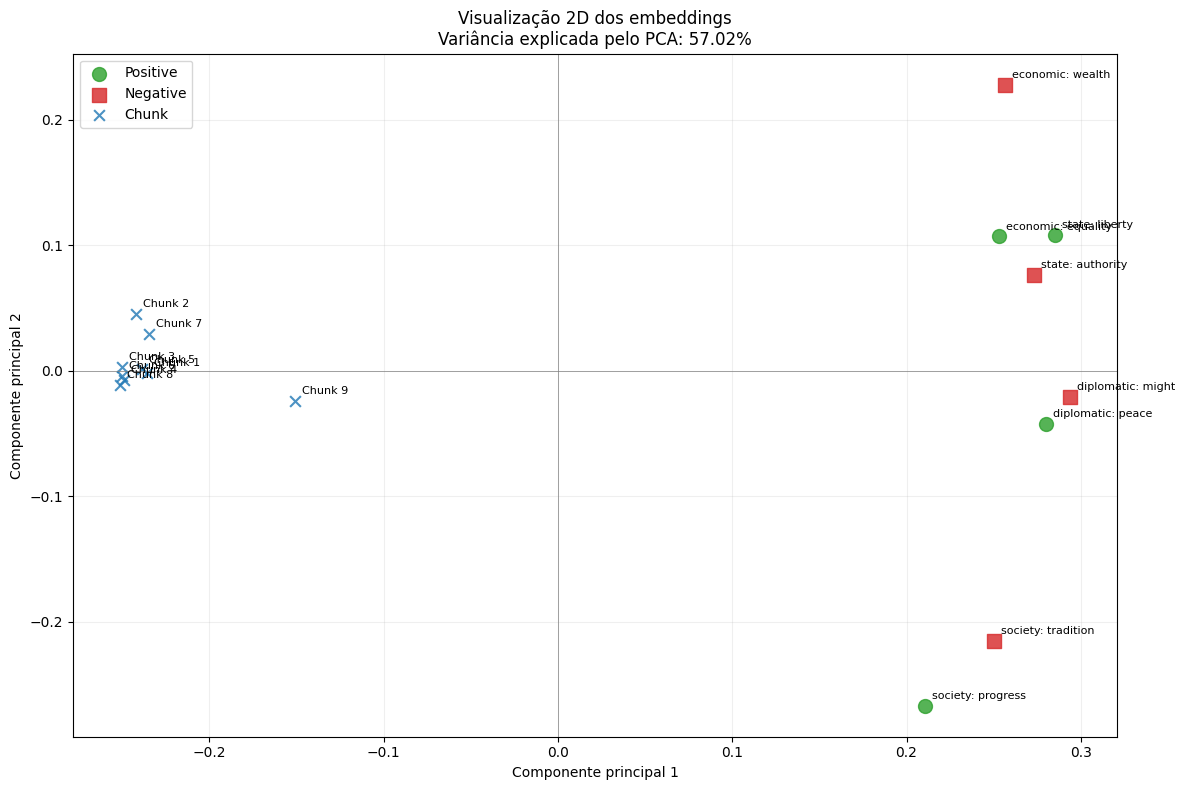

(array([[ 0.25311315,  0.10691066],
        [ 0.2565164 ,  0.22783983],
        [ 0.27989516, -0.04271213],
        [ 0.29356462, -0.02109734],
        [ 0.28498778,  0.10781898],
        [ 0.27316022,  0.07603465],
        [ 0.21042548, -0.26704744],
        [ 0.25029555, -0.2157992 ],
        [-0.23576924, -0.00222195],
        [-0.24210818,  0.04503695],
        [-0.25018778,  0.00314298],
        [-0.24893442, -0.00747898],
        [-0.2386247 ,  0.00094345],
        [-0.24992402, -0.0044073 ],
        [-0.2344562 ,  0.02903358],
        [-0.25109896, -0.01155794],
        [-0.15085478, -0.0244387 ]], dtype=float32),
 ['economic: equality',
  'economic: wealth',
  'diplomatic: peace',
  'diplomatic: might',
  'state: liberty',
  'state: authority',
  'society: progress',
  'society: tradition',
  'Chunk 1',
  'Chunk 2',
  'Chunk 3',
  'Chunk 4',
  'Chunk 5',
  'Chunk 6',
  'Chunk 7',
  'Chunk 8',
  'Chunk 9'])

In [ ]:
semantic_2.plot_embeddings(
    texto,
    annotate_chunks=True,
)

In [ ]:
semantic_2.plot_embeddings_3d_interactive(texto)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3311 > 512). Running this sequence through the model will result in indexing errors


,PC1,PC2,PC3,label,type
0,0.253113,0.106910,-0.123218,economic: equality,Positive
1,0.256517,0.227838,-0.132783,economic: wealth,Negative
2,0.279895,-0.042712,0.122298,diplomatic: peace,Positive
3,0.293565,-0.021098,0.164587,diplomatic: might,Negative
4,0.284988,0.107821,0.075531,state: liberty,Positive
5,0.273160,0.076034,0.024107,state: authority,Negative
6,0.210425,-0.267047,-0.143944,society: progress,Positive
7,0.250295,-0.215799,-0.057814,society: tradition,Negative
8,-0.235769,-0.002220,0.002135,Chunk 1,Chunk
9,-0.242108,0.045042,-0.060624,Chunk 2,Chunk


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3311 > 512). Running this sequence through the model will result in indexing errors


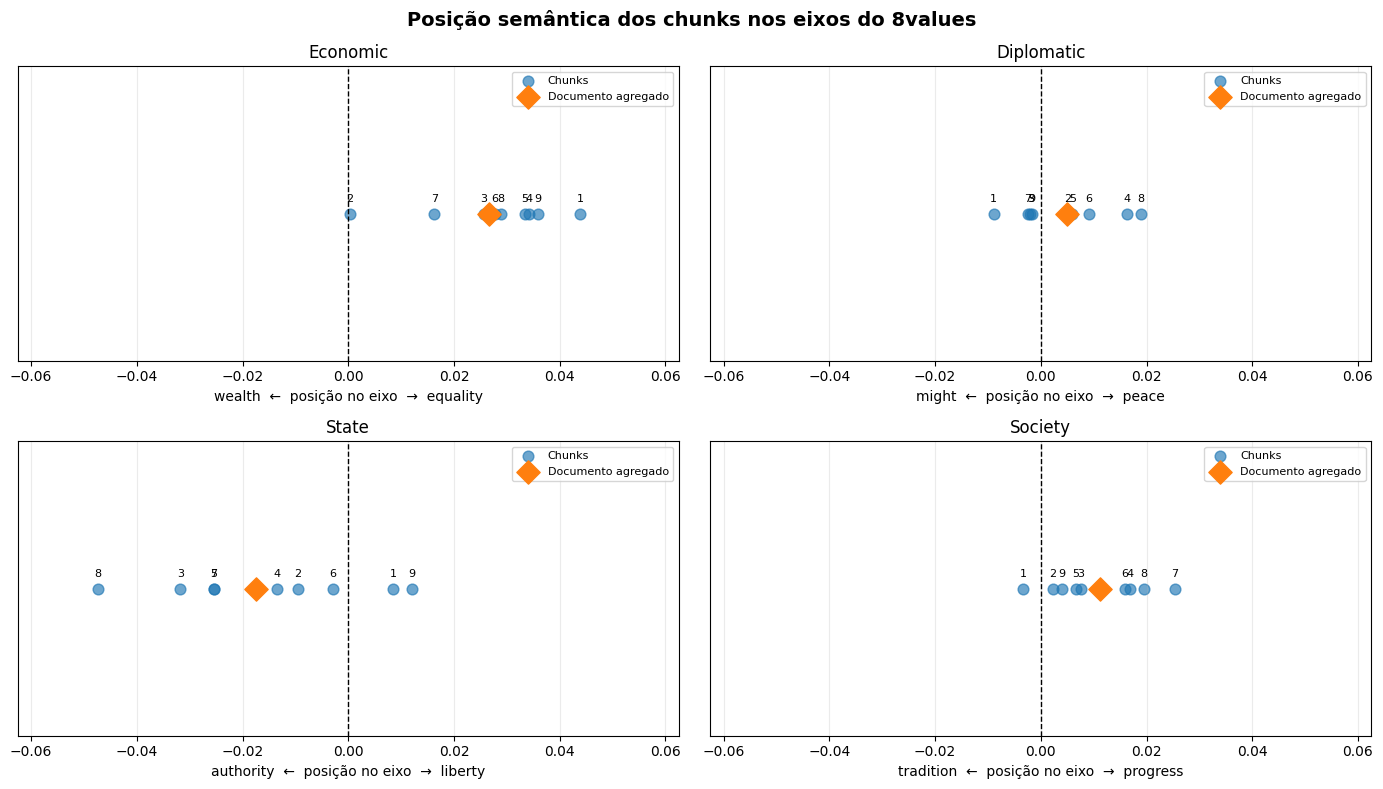

In [ ]:
semantic_2.plot_axis_positions(texto)

##### Teste Perguntas 8values

In [ ]:
df = test_semantic8values(semantic_1)

display(df)
display(resumo_testes(df))

,id,axis,effect,expected,question,margin,projection,score_margin,score_projection,predicted_margin,predicted_projection,correct_margin,correct_projection
0,1,economic,10,equality,A opressão por corporações é uma preocupação m...,-0.006156,-0.014538,46.925928,42.781990,wealth,wealth,False,False
1,2,economic,10,equality,É necessário que o governo intervenha na econo...,-0.012148,-0.028689,43.955457,36.036482,wealth,wealth,False,False
2,3,economic,-10,wealth,"Quanto mais livres os mercados, mais livres as...",-0.012442,-0.029383,43.810790,35.717371,wealth,wealth,True,True
3,4,economic,-10,wealth,É melhor manter um orçamento equilibrado do qu...,0.016082,0.037978,57.972266,68.125665,equality,equality,False,False
4,5,economic,10,equality,A pesquisa financiada publicamente é mais bené...,-0.001066,-0.002517,49.467155,48.741855,wealth,wealth,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,69,society,10,progress,Todas as pessoas - independentemente de fatore...,-0.002901,-0.008308,48.549898,45.855446,tradition,tradition,False,False
87,70,economic,-10,wealth,É importante que avancemos os objetivos do meu...,0.008397,0.019829,54.188504,59.786632,equality,equality,False,False
88,70,diplomatic,-10,might,É importante que avancemos os objetivos do meu...,-0.006379,-0.017166,46.814637,41.500325,might,might,True,True
89,70,state,-10,authority,É importante que avancemos os objetivos do meu...,0.012271,0.032665,56.105029,65.775573,liberty,liberty,False,False


,quantidade,acertos_margin,acertos_projection,accuracy_margin,accuracy_projection
axis,,,,,
diplomatic,21,13,13,0.619048,0.619048
economic,17,7,7,0.411765,0.411765
society,26,14,14,0.538462,0.538462
state,27,14,14,0.518519,0.518519


In [ ]:
df = test_semantic8values(semantic_2)

display(df)
display(resumo_testes(df))

,id,axis,effect,expected,question,margin,projection,score_margin,score_projection,predicted_margin,predicted_projection,correct_margin,correct_projection
0,1,economic,10,equality,A opressão por corporações é uma preocupação m...,-0.000337,-0.000781,49.831409,49.609452,wealth,wealth,False,False
1,2,economic,10,equality,É necessário que o governo intervenha na econo...,-0.006250,-0.014480,46.879199,42.810083,wealth,wealth,False,False
2,3,economic,-10,wealth,"Quanto mais livres os mercados, mais livres as...",-0.014545,-0.033700,42.778197,33.760017,wealth,wealth,True,True
3,4,economic,-10,wealth,É melhor manter um orçamento equilibrado do qu...,0.019873,0.046043,59.807535,71.521811,equality,equality,False,False
4,5,economic,10,equality,A pesquisa financiada publicamente é mais bené...,-0.001695,-0.003928,49.152503,48.037186,wealth,wealth,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,69,society,10,progress,Todas as pessoas - independentemente de fatore...,-0.003545,-0.009213,48.228398,45.406671,tradition,tradition,False,False
87,70,economic,-10,wealth,É importante que avancemos os objetivos do meu...,0.012686,0.029393,56.309344,64.287403,equality,equality,False,False
88,70,diplomatic,-10,might,É importante que avancemos os objetivos do meu...,-0.003124,-0.008093,48.438449,45.962401,might,might,True,True
89,70,state,-10,authority,É importante que avancemos os objetivos do meu...,-0.006477,-0.017667,46.766111,41.257230,authority,authority,True,True


,quantidade,acertos_margin,acertos_projection,accuracy_margin,accuracy_projection
axis,,,,,
diplomatic,21,14,14,0.666667,0.666667
economic,17,7,7,0.411765,0.411765
society,26,15,15,0.576923,0.576923
state,27,14,14,0.518519,0.518519


##### NLI

A NLI (Natural Language Inference, ou Inferência de Linguagem Natural) é uma tarefa de Inteligência Artificial e Processamento de Linguagem Natural (PLN) que serve para determinar a relação lógica entre duas frases.

In [ ]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)


MODEL_NAME = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"


tokenizer_nli = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model_nli = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME
)

model_nli.eval()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(251000, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [ ]:
def nli(
    premise: str,
    hypothesis: str,
):

    inputs = tokenizer_nli(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )

    with torch.no_grad():

        outputs = model_nli(
            **inputs
        )

    probabilities = torch.softmax(
        outputs.logits[0],
        dim=-1,
    )

    result = {}

    for i, probability in enumerate(
        probabilities
    ):

        label = (
            model_nli
            .config
            .id2label[i]
            .lower()
        )

        result[label] = float(
            probability
        )

    return result

In [ ]:
texto = (
    "A intervenção governamental "
    "é uma ameaça à economia."
)

hipotese = (
    "O Estado deve aumentar sua "
    "intervenção na economia."
)

In [ ]:
nli(
    texto,
    hipotese,
)

{'entailment': 0.0002598762512207031,
 'neutral': 0.0257568359375,
 'contradiction': 0.97412109375}

##### Teste Planos Governo

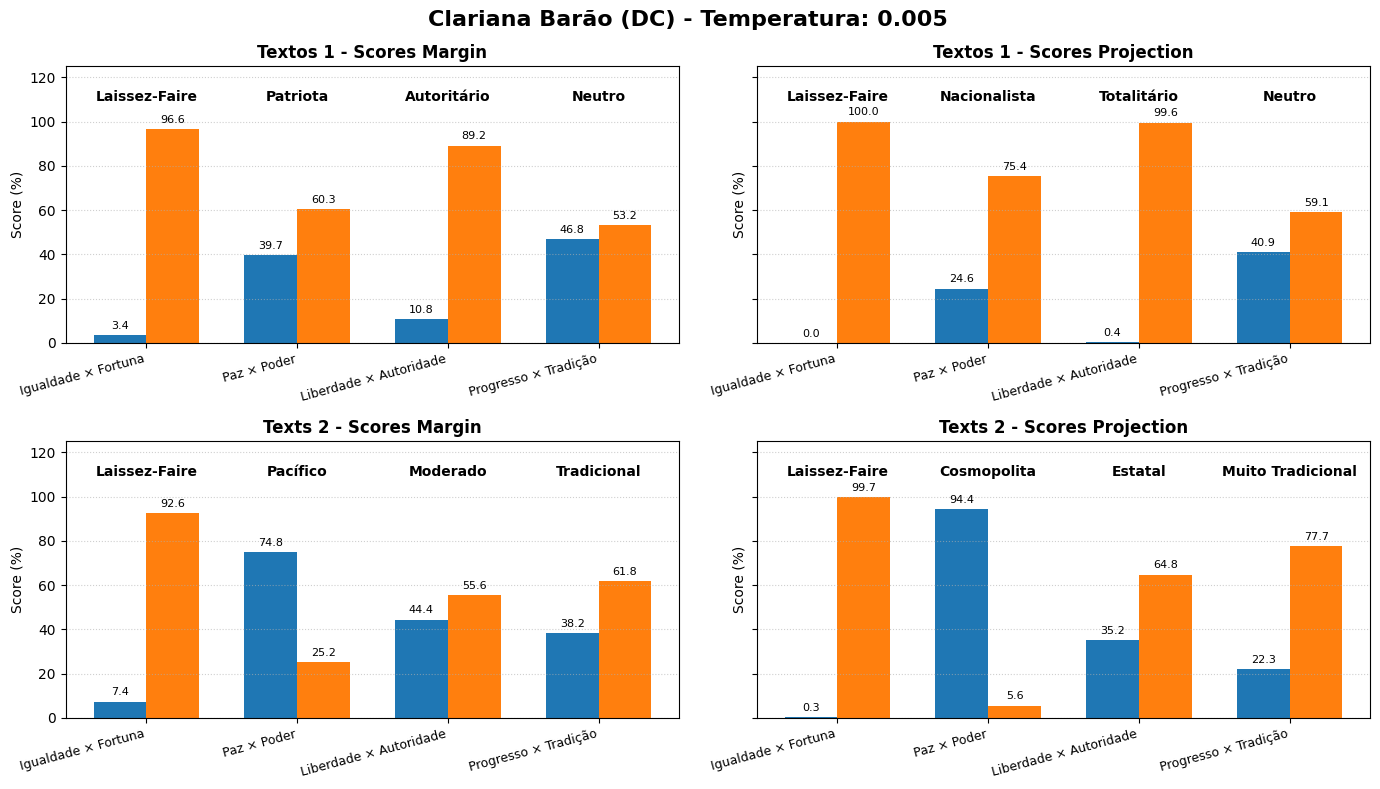

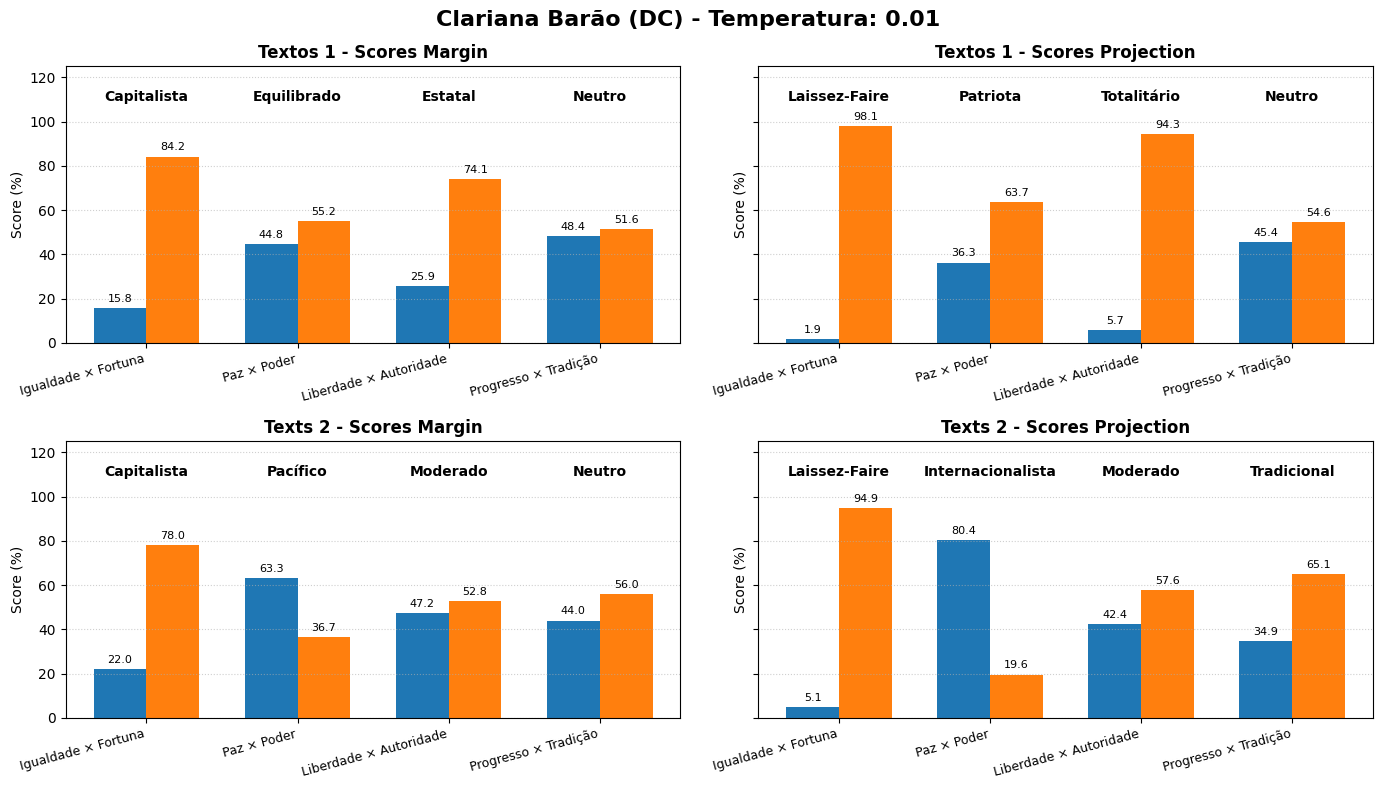

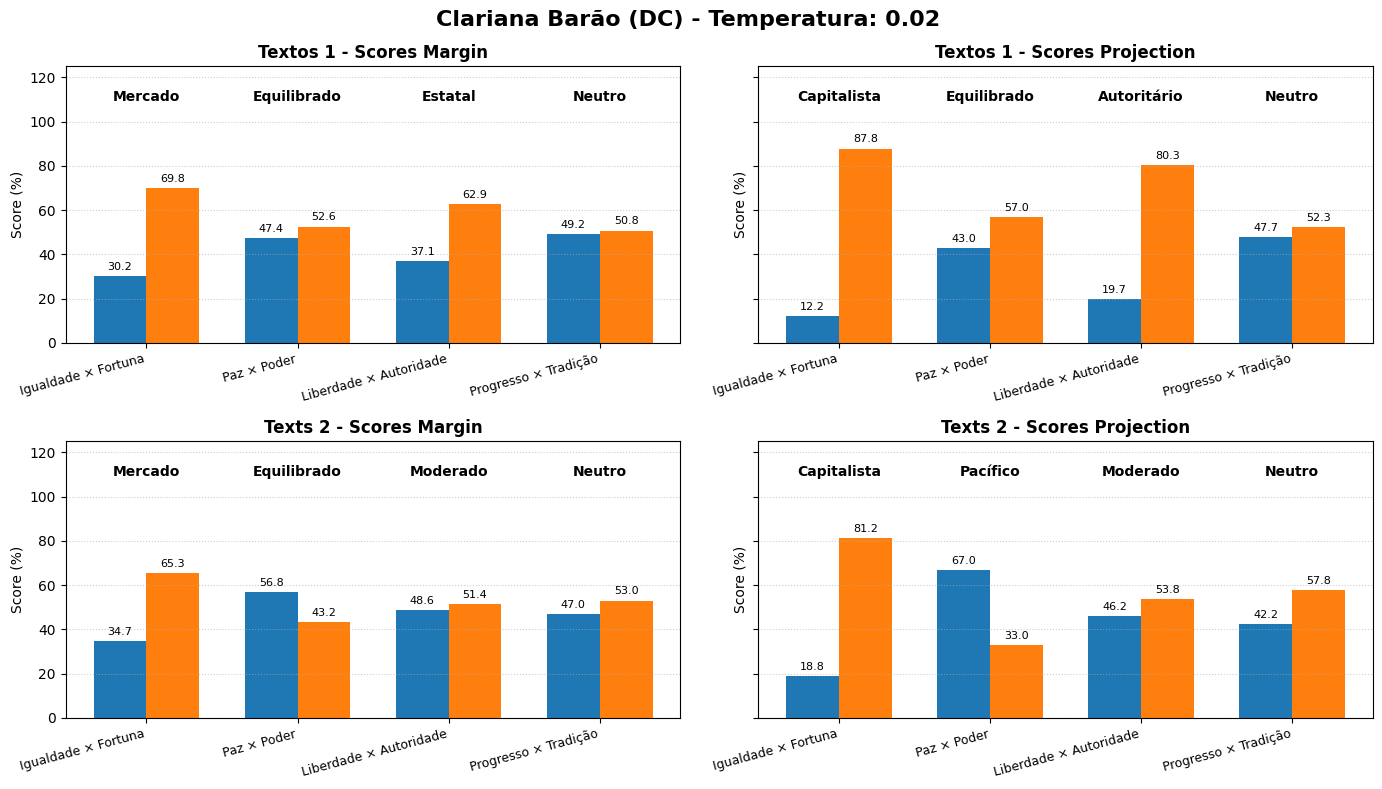

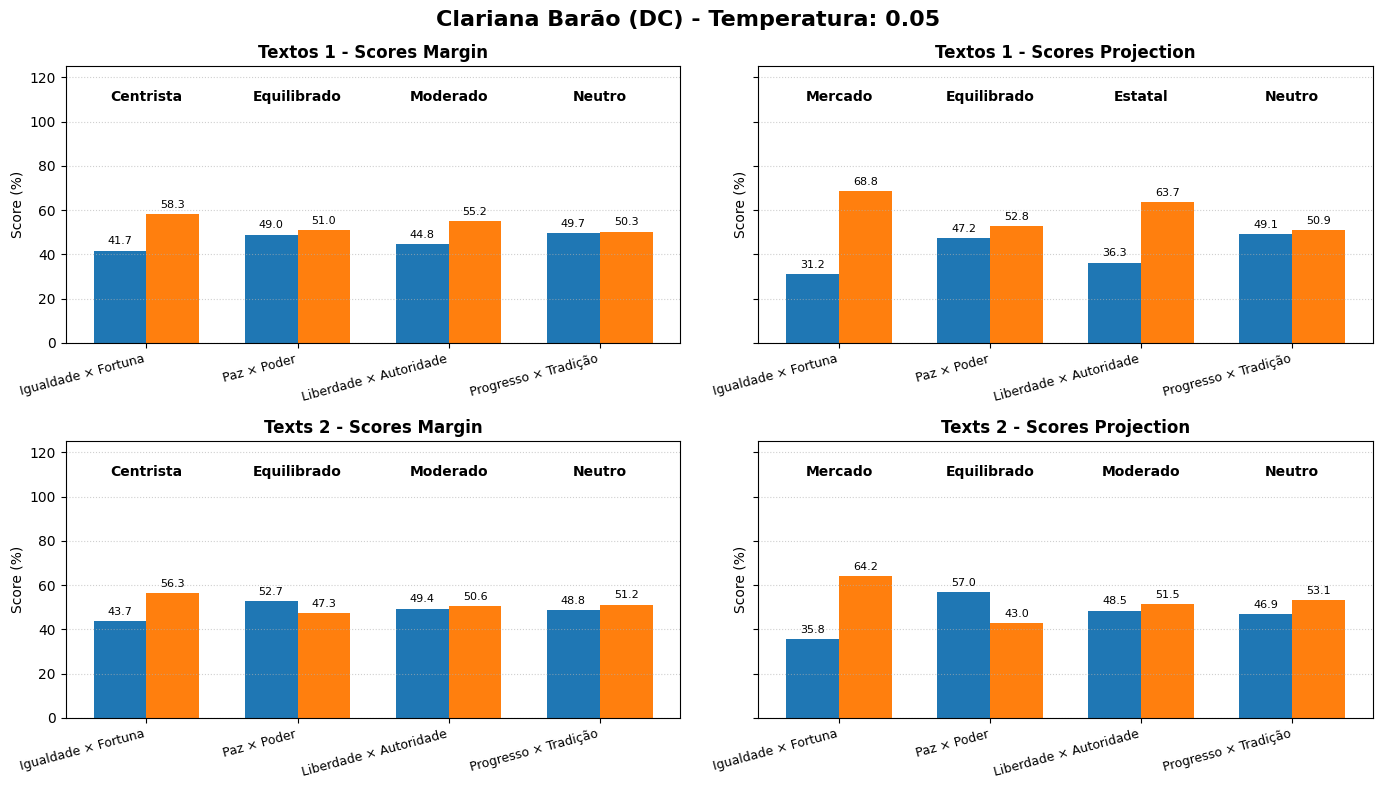

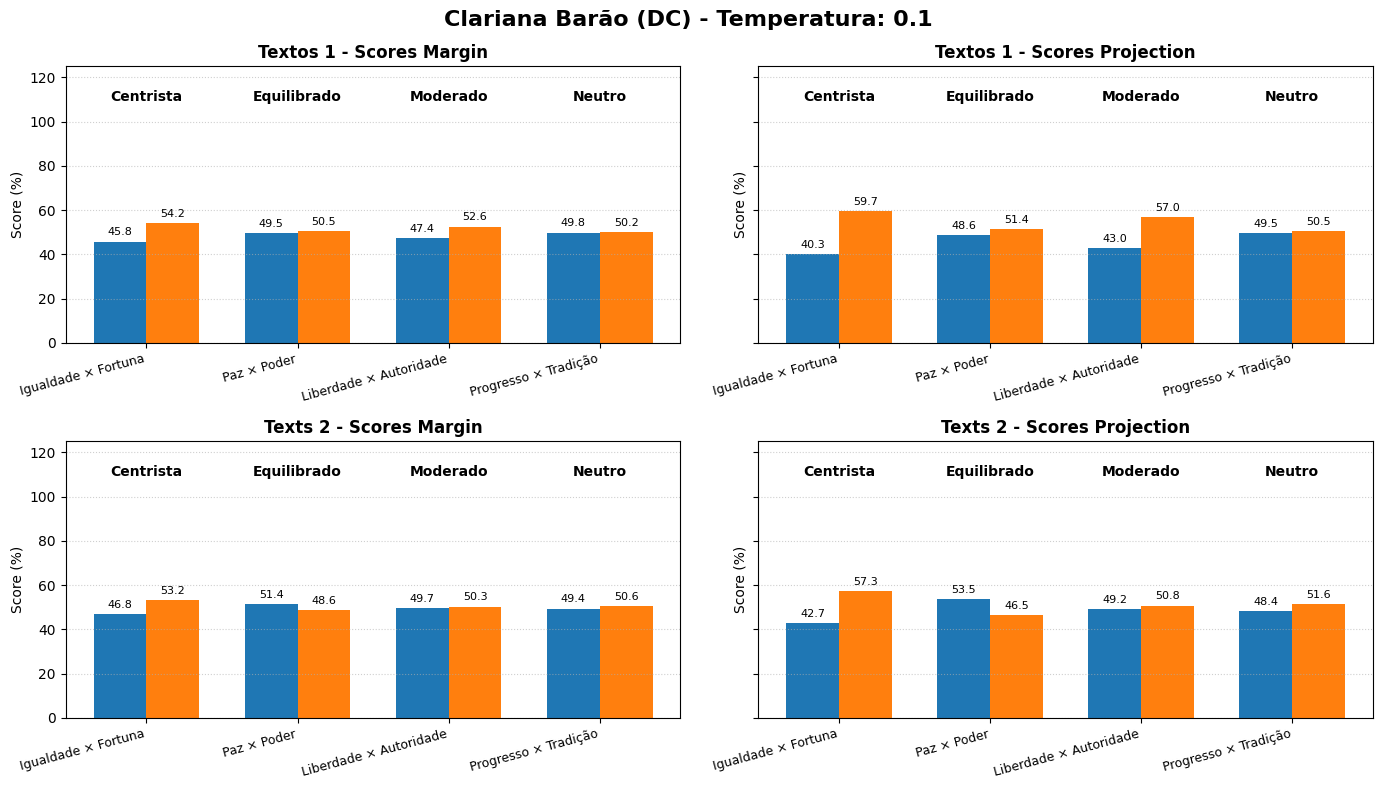

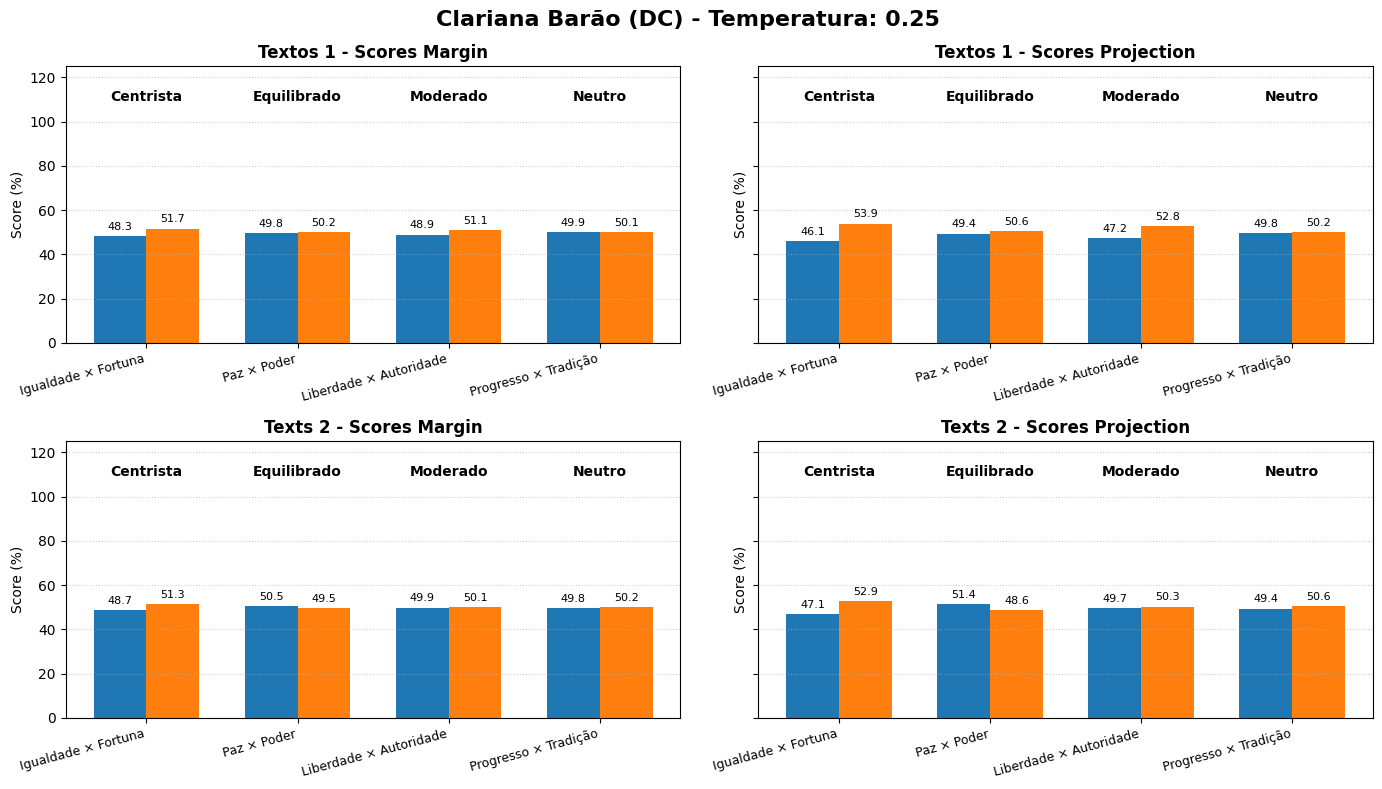

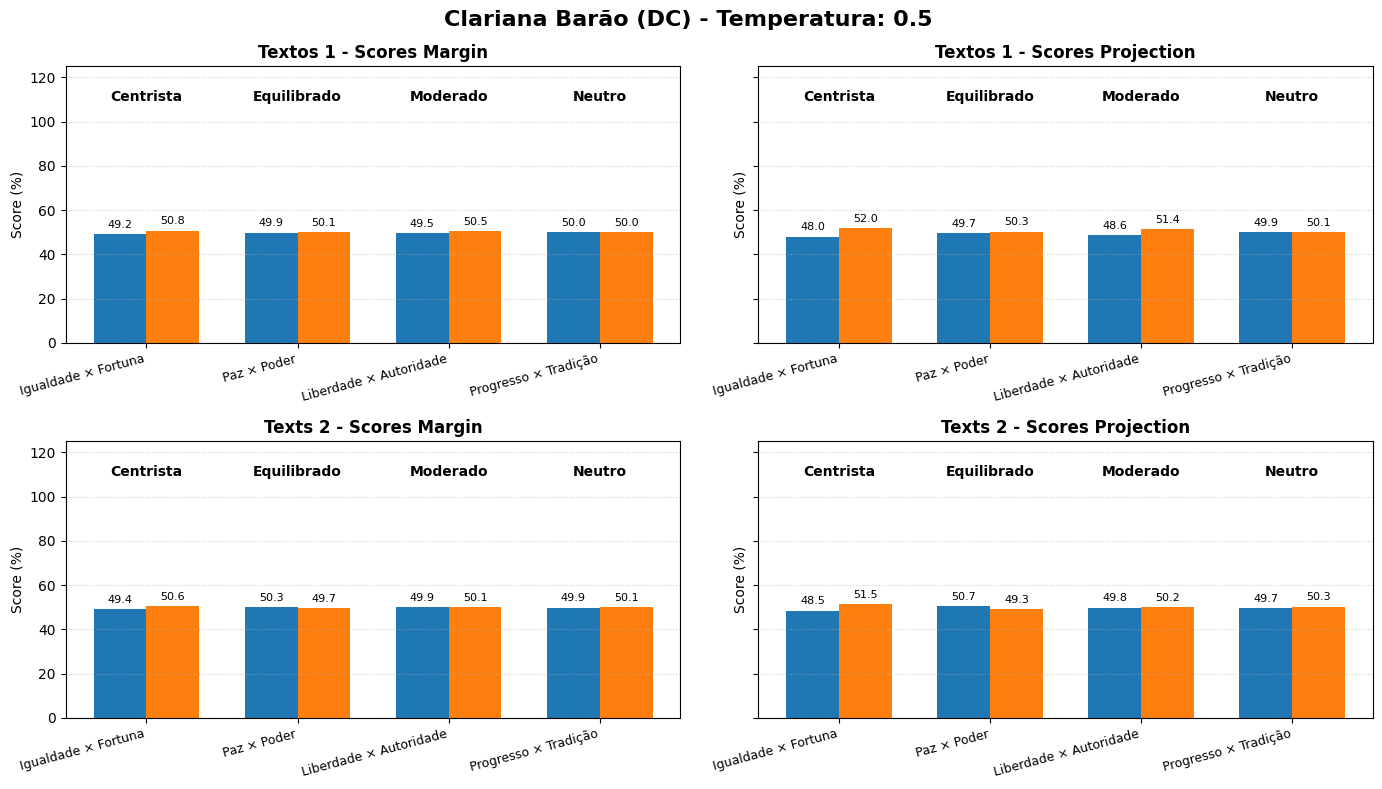

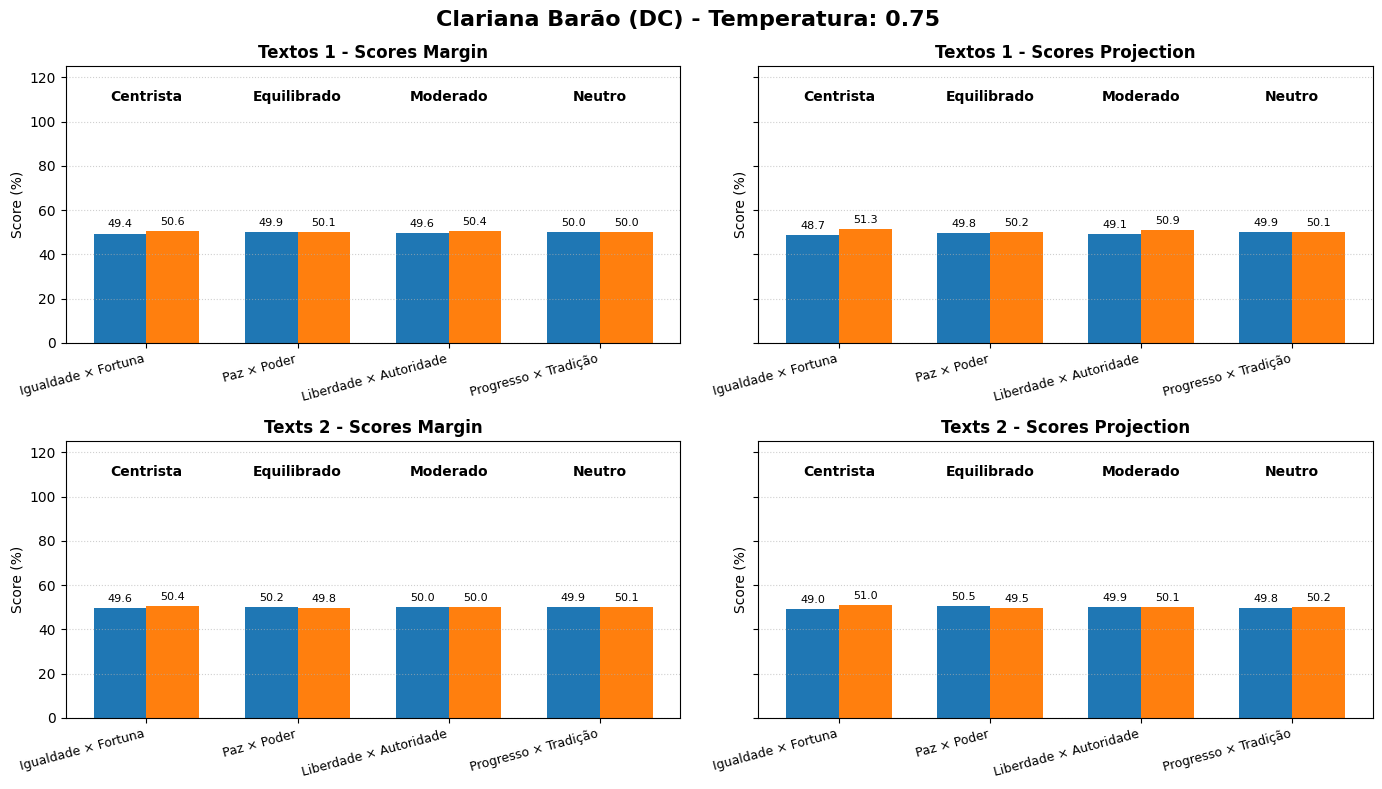

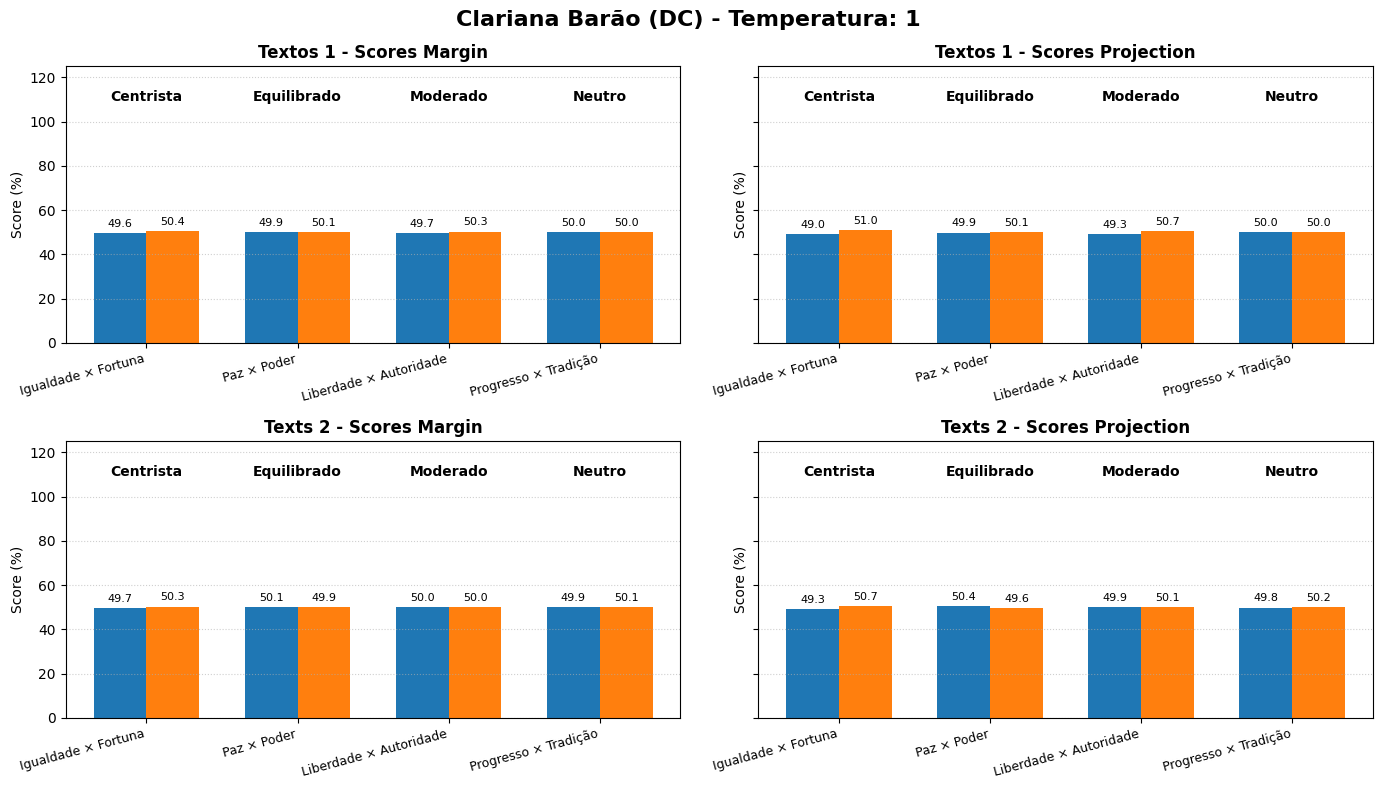

In [ ]:
for temperature in [0.005, 0.01, 0.02, 0.05, 0.1 , 0.25 , 0.5, 0.75, 1]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

    models = [
        (semantic_1, axes[0, 0], axes[0, 1], "Textos 1"),
        (semantic_2, axes[1, 0], axes[1, 1], "Texts 2"),
    ]

    for semantic, ax_margin, ax_proj, model_name in models:
        semantic.temperature = temperature
        details = semantic.predict(texto)

        result_m = details_to_result(details, "score_margin")
        result_p = details_to_result(details, "score_projection")

        values_m = Quiz8Values.calculate_8values(result_m, IDEOLOGIES)
        values_p = Quiz8Values.calculate_8values(result_p, IDEOLOGIES)

        grafico_scores(
            values_m.scores.model_dump(),
            values_m.labels.to_list(),
            f"{model_name} - Scores Margin",
            ax_margin,
        )
        grafico_scores(
            values_p.scores.model_dump(),
            values_p.labels.to_list(),
            f"{model_name} - Scores Projection",
            ax_proj,
        )

    fig.suptitle(
        f"{plano['candidato']} - Temperatura: {temperature}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


### Similaridade

In [ ]:
MODEL_NAME = "intfloat/multilingual-e5-base"

AXES = {
    "economic": ("equality", "wealth"),
    "diplomatic": ("peace", "might"),
    "state": ("liberty", "authority"),
    "society": ("progress", "tradition"),
}

EFFECT_TO_AXIS = {
    "econ": "economic",
    "dipl": "diplomatic",
    "govt": "state",
    "scty": "society",
}


model = SentenceTransformer(
    MODEL_NAME
)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
POSITION_PREDICTIONS = {}
POSITION_RESULTS = {}

#### Métodos Gerais

In [ ]:
def normalize(vector):

    vector = np.asarray(
        vector,
        dtype=np.float32,
    )

    norm = np.linalg.norm(
        vector
    )

    if norm == 0:
        raise ValueError(
            "Vetor com norma zero."
        )

    return vector / norm

In [ ]:
def evaluate_positioning(
    df,
    experiment_id,
    decision_column="score",
    ranking_column="score",
):

    df = df.copy()

    df["expected_sign"] = np.where(
        df["effect"] > 0,
        1,
        -1,
    )

    df["predicted_sign"] = np.where(
        df[decision_column] > 0,
        1,
        -1,
    )

    rows = []

    for axis, group in df.groupby("axis"):

        rho, p_value = spearmanr(
            group["effect"],
            group[ranking_column],
        )

        rows.append({
            "experiment": experiment_id,
            "axis": axis,
            "n": len(group),

            "accuracy": accuracy_score(
                group["expected_sign"],
                group["predicted_sign"],
            ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    group["expected_sign"],
                    group["predicted_sign"],
                ),

            "mcc": matthews_corrcoef(
                group["expected_sign"],
                group["predicted_sign"],
            ),

            "spearman": rho,
            "p_value": p_value,
        })

    return pd.DataFrame(rows)

In [ ]:
def run_position_experiment(
    experiment_id,
    scorer,
    strongest_only=False,
):

    rows = []

    for question in QUESTIONS:

        text_embedding = model.encode(
            f"query: {question.question}",
            normalize_embeddings=True,
        )

        effects = (
            question.effect.model_dump()
        )

        for (
            effect_name,
            effect_value,
        ) in effects.items():

            # Neste experimento estamos
            # avaliando posição, não relevância.
            if effect_value == 0:
                continue

            if (
                strongest_only
                and
                abs(effect_value) != 10
            ):
                continue

            axis = EFFECT_TO_AXIS[
                effect_name
            ]

            score = scorer(
                text_embedding,
                axis,
            )

            rows.append({
                "id": question.id,
                "question": question.question,
                "axis": axis,
                "effect": effect_value,
                "score": score,
            })

    df = pd.DataFrame(rows)

    result = evaluate_positioning(
        df,
        experiment_id,
    )

    POSITION_PREDICTIONS[
        experiment_id
    ] = df

    POSITION_RESULTS[
        experiment_id
    ] = result

    return result

In [ ]:
def position_results():

    if not POSITION_RESULTS:
        return pd.DataFrame()

    return pd.concat(
        POSITION_RESULTS.values(),
        ignore_index=True,
    )

In [ ]:
def position_comparison(
    metric="accuracy",
):

    df = position_results()

    return (
        df.pivot(
            index="experiment",
            columns="axis",
            values=metric,
        )
    )

#### B0 — Single Axis

Uma descrição geral de cada polo é suficiente para recuperar a direção política indicada pelo 8values?

In [ ]:
def create_single_axis_embeddings(
    textos_eixos,
    model,
):

    axes = {}

    for axis, (
        positive_name,
        negative_name,
    ) in AXES.items():

        positive_text = (
            textos_eixos[
                axis
            ][
                positive_name
            ]
        )

        negative_text = (
            textos_eixos[
                axis
            ][
                negative_name
            ]
        )

        positive_embedding, negative_embedding = (
            model.encode(
                [
                    f"passage: {positive_text}",
                    f"passage: {negative_text}",
                ],
                normalize_embeddings=True,
            )
        )

        positive_embedding = normalize(
            positive_embedding
        )

        negative_embedding = normalize(
            negative_embedding
        )

        direction = normalize(
            positive_embedding
            -
            negative_embedding
        )

        center = (
            positive_embedding
            +
            negative_embedding
        ) / 2

        axes[axis] = {

            "positive_name":
                positive_name,

            "negative_name":
                negative_name,

            "positive":
                positive_embedding,

            "negative":
                negative_embedding,

            "direction":
                direction,

            "center":
                center,

            "pole_distance":
                float(
                    np.linalg.norm(
                        positive_embedding
                        -
                        negative_embedding
                    )
                ),
        }

    return axes

In [ ]:
SINGLE_AXIS_EMBEDDINGS = (
    create_single_axis_embeddings(
        TEXTOS_EIXOS_2,
        model,
    )
)

In [ ]:
def score_b0(
    text_embedding,
    axis,
):

    data = (
        SINGLE_AXIS_EMBEDDINGS[
            axis
        ]
    )

    return float(
        np.dot(
            text_embedding
            -
            data["center"],

            data["direction"],
        )
    )

In [ ]:
result_b0 = run_position_experiment(
    "B0_single_axis",
    score_b0,
)

display(result_b0)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B0_single_axis,diplomatic,24,0.666667,0.666667,0.384900,0.277388,0.189417
1,B0_single_axis,economic,22,0.409091,0.380342,-0.244600,-0.169876,0.449770
2,B0_single_axis,society,33,0.606061,0.633333,0.324799,0.350546,0.045494
3,B0_single_axis,state,37,0.540541,0.592949,0.185897,0.045029,0.791291


#### B1 — Multiple Centroids

Usar várias descrições de cada polo melhora a representação em relação a uma única descrição geral?

In [ ]:
PAIRED_ANCHORS = {

    "economic": [

        (
            "Defende ampliar a atuação do Estado na economia.",
            "Defende reduzir a atuação do Estado na economia."
        ),

        (
            "Defende tributação progressiva para reduzir desigualdades.",
            "Defende redução de impostos e menor progressividade tributária."
        ),

        (
            "Defende ampliar políticas de redistribuição de renda.",
            "Defende reduzir políticas redistributivas e priorizar mecanismos de mercado."
        ),

        (
            "Defende fortalecer empresas públicas.",
            "Defende privatizar empresas públicas."
        ),

        (
            "Defende maior regulação estatal da economia.",
            "Defende desregulamentação dos mercados."
        ),
    ],

    "diplomatic": [

        (
            "Defende maior cooperação internacional.",
            "Defende priorizar os interesses nacionais."
        ),

        (
            "Defende fortalecer instituições multilaterais.",
            "Defende preservar a soberania nacional diante de instituições internacionais."
        ),

        (
            "Defende maior integração entre países.",
            "Defende maior autonomia política nacional."
        ),

        (
            "Defende compartilhar decisões por meio de instituições internacionais.",
            "Defende manter decisões políticas fundamentais sob controle nacional."
        ),

        (
            "Defende maior solidariedade internacional.",
            "Defende fortalecer identidade e independência nacionais."
        ),
    ],

    "state": [

        (
            "Defende amplas liberdades civis.",
            "Defende maior autoridade estatal em nome da ordem."
        ),

        (
            "Defende ampla liberdade de expressão.",
            "Defende restrições à expressão quando necessárias à ordem."
        ),

        (
            "Defende pluralismo político e limites ao governo.",
            "Defende maior concentração de poder político."
        ),

        (
            "Defende limites à vigilância estatal.",
            "Defende ampliar a vigilância estatal em nome da segurança."
        ),

        (
            "Defende maior autonomia dos indivíduos.",
            "Defende maior controle estatal sobre comportamentos."
        ),
    ],

    "society": [

        (
            "Defende reformar costumes e instituições diante de novas necessidades sociais.",
            "Defende preservar costumes e instituições historicamente consolidados."
        ),

        (
            "Defende revisar tradições consideradas inadequadas.",
            "Defende preservar tradições como referência social."
        ),

        (
            "Defende mudanças sociais amplas.",
            "Defende mudanças sociais graduais."
        ),

        (
            "Defende adaptação das normas sociais a novos valores.",
            "Defende preservação de normas e valores tradicionais."
        ),

        (
            "Defende maior abertura à transformação dos costumes.",
            "Defende maior preservação dos costumes tradicionais."
        ),
    ],
}

In [ ]:
def create_multiple_axis_embeddings(
    paired_anchors,
    model
):

    embeddings = {}

    for axis, pairs in paired_anchors.items():

        positive_texts = [
            pair[0]
            for pair in pairs
        ]

        negative_texts = [
            pair[1]
            for pair in pairs
        ]

        positive_vectors = model.encode(
            [
                f"passage: {text}"
                for text in positive_texts
            ],
            normalize_embeddings=True,
        )

        negative_vectors = model.encode(
            [
                f"passage: {text}"
                for text in negative_texts
            ],
            normalize_embeddings=True,
        )

        positive_embedding = normalize(
            positive_vectors.mean(
                axis=0
            )
        )

        negative_embedding = normalize(
            negative_vectors.mean(
                axis=0
            )
        )

        direction = normalize(
            positive_embedding
            - negative_embedding
        )

        center = (
            positive_embedding
            + negative_embedding
        ) / 2

        embeddings[axis] = {

            "positive":
                positive_embedding,

            "negative":
                negative_embedding,

            "direction":
                direction,

            "center":
                center,
        }

    return embeddings

In [ ]:
MULTIPLE_AXIS_EMBEDDINGS = (
    create_multiple_axis_embeddings(
        PAIRED_ANCHORS,
        model
    )
)

In [ ]:
def score_b1(
    text_embedding,
    axis,
):

    data = (
        MULTIPLE_AXIS_EMBEDDINGS[
            axis
        ]
    )

    return float(
        np.dot(
            text_embedding
            -
            data["center"],

            data["direction"],
        )
    )

In [ ]:
result_b1 = run_position_experiment(
    "B1_multiple_centroids",
    score_b1,
)

display(result_b1)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B1_multiple_centroids,diplomatic,24,0.625000,0.625000,0.307794,0.314564,0.134372
1,B1_multiple_centroids,economic,22,0.409091,0.414530,-0.168790,-0.064686,0.774883
2,B1_multiple_centroids,society,33,0.575758,0.566667,0.135873,0.106665,0.554651
3,B1_multiple_centroids,state,37,0.351351,0.500000,0.000000,0.125627,0.458769


#### B2 - Paired Directions

Em vez de misturar todas as âncoras antes de formar o eixo, preservar os contrastes positivo/negativo individualmente melhora a estimativa de posição?

In [ ]:
def create_paired_axis_embeddings(
    paired_anchors,
    model,
):

    result = {}

    for axis, pairs in (
        paired_anchors.items()
    ):

        texts = []

        for positive, negative in pairs:

            texts.extend([
                f"passage: {positive}",
                f"passage: {negative}",
            ])

        vectors = model.encode(
            texts,
            normalize_embeddings=True,
        )

        pair_embeddings = []

        for i, (
            positive_text,
            negative_text,
        ) in enumerate(pairs):

            positive = vectors[
                i * 2
            ]

            negative = vectors[
                i * 2 + 1
            ]

            direction = normalize(
                positive
                -
                negative
            )

            center = (
                positive
                +
                negative
            ) / 2

            pair_embeddings.append({
                "positive_text":
                    positive_text,

                "negative_text":
                    negative_text,

                "positive":
                    positive,

                "negative":
                    negative,

                "direction":
                    direction,

                "center":
                    center,
            })

        result[axis] = (
            pair_embeddings
        )

    return result

In [ ]:
PAIRED_AXIS_EMBEDDINGS = (
    create_paired_axis_embeddings(
        PAIRED_ANCHORS,
        model,
    )
)

In [ ]:
def score_b2(
    text_embedding,
    axis,
):

    pairs = (
        PAIRED_AXIS_EMBEDDINGS[
            axis
        ]
    )

    scores = []

    for pair in pairs:

        score = float(
            np.dot(
                text_embedding
                -
                pair["center"],

                pair["direction"],
            )
        )

        scores.append(
            score
        )

    return float(
        np.median(
            scores
        )
    )

In [ ]:
result_b2 = run_position_experiment(
    "B2_paired_median",
    score_b2,
)

display(result_b2)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B2_paired_median,diplomatic,24,0.583333,0.583333,0.192450,0.323143,0.123506
1,B2_paired_median,economic,22,0.590909,0.568376,0.139771,-0.030832,0.891660
2,B2_paired_median,society,33,0.606061,0.627778,0.285720,0.207790,0.245903
3,B2_paired_median,state,37,0.351351,0.500000,0.000000,0.124114,0.464242


#### Comparação

In [ ]:
display(
    position_results()
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B0_single_axis,diplomatic,24,0.666667,0.666667,0.384900,0.277388,0.189417
1,B0_single_axis,economic,22,0.409091,0.380342,-0.244600,-0.169876,0.449770
2,B0_single_axis,society,33,0.606061,0.633333,0.324799,0.350546,0.045494
3,B0_single_axis,state,37,0.540541,0.592949,0.185897,0.045029,0.791291
4,B1_multiple_centroids,diplomatic,24,0.625000,0.625000,0.307794,0.314564,0.134372
5,B1_multiple_centroids,economic,22,0.409091,0.414530,-0.168790,-0.064686,0.774883
6,B1_multiple_centroids,society,33,0.575758,0.566667,0.135873,0.106665,0.554651
7,B1_multiple_centroids,state,37,0.351351,0.500000,0.000000,0.125627,0.458769
8,B2_paired_median,diplomatic,24,0.583333,0.583333,0.192450,0.323143,0.123506
9,B2_paired_median,economic,22,0.590909,0.568376,0.139771,-0.030832,0.891660


In [ ]:
display(
    position_comparison(
        "accuracy"
    )
)

axis,diplomatic,economic,society,state
experiment,,,,
B0_single_axis,0.666667,0.409091,0.606061,0.540541
B1_multiple_centroids,0.625000,0.409091,0.575758,0.351351
B2_paired_median,0.583333,0.590909,0.606061,0.351351


#### B3 - Minimal-pair stance test

Quando mantemos o tópico praticamente constante e alteramos apenas a posição defendida, o método consegue inverter corretamente o sinal


##### B3a - Anchor-aligned minimal pairs

O eixo construído responde corretamente a mudanças de posição semelhantes às utilizadas em sua própria construção?

In [ ]:
MINIMAL_PAIRS = {

    "economic": [

        (
            "O Estado deve ampliar sua participação na economia.",
            "O Estado deve reduzir sua participação na economia.",
        ),

        (
            "O governo deve aumentar a tributação progressiva para reduzir desigualdades.",
            "O governo deve reduzir a tributação progressiva e diminuir os impostos.",
        ),

        (
            "As empresas estatais devem ser fortalecidas.",
            "As empresas estatais devem ser privatizadas.",
        ),

        (
            "O governo deve ampliar políticas de redistribuição de renda.",
            "O governo deve reduzir políticas de redistribuição de renda.",
        ),

        (
            "Os mercados devem ser submetidos a maior regulação estatal.",
            "Os mercados devem ter menor regulação estatal.",
        ),
    ],


    "diplomatic": [

        (
            "O país deve ampliar a cooperação com instituições internacionais.",
            "O país deve priorizar sua soberania diante de instituições internacionais.",
        ),

        (
            "As decisões internacionais devem ser tomadas de forma multilateral.",
            "As decisões políticas fundamentais devem permanecer sob controle nacional.",
        ),

        (
            "O país deve ampliar sua integração política com outras nações.",
            "O país deve preservar maior autonomia política diante de outras nações.",
        ),

        (
            "Instituições multilaterais devem ter maior participação na solução de conflitos internacionais.",
            "Cada país deve preservar sua autonomia na solução de conflitos internacionais.",
        ),

        (
            "A política externa deve priorizar a cooperação entre os países.",
            "A política externa deve priorizar os interesses nacionais.",
        ),
    ],


    "state": [

        (
            "O Estado deve proteger amplamente as liberdades civis.",
            "O Estado deve limitar liberdades civis quando necessário para preservar a ordem.",
        ),

        (
            "A liberdade de expressão deve ser protegida mesmo diante de opiniões controversas.",
            "A liberdade de expressão pode ser restringida para preservar a ordem social.",
        ),

        (
            "A vigilância estatal deve ser limitada para proteger a privacidade.",
            "A vigilância estatal deve ser ampliada para aumentar a segurança.",
        ),

        (
            "O poder do governo deve possuir fortes limites institucionais.",
            "O governo deve possuir maior autoridade para tomar decisões.",
        ),

        (
            "Os indivíduos devem possuir maior autonomia sobre suas escolhas pessoais.",
            "O Estado deve exercer maior controle sobre comportamentos individuais.",
        ),
    ],


    "society": [

        (
            "A sociedade deve adaptar suas tradições às novas necessidades sociais.",
            "A sociedade deve preservar suas tradições diante das mudanças sociais.",
        ),

        (
            "As normas sociais devem acompanhar novos valores.",
            "As normas sociais tradicionais devem ser preservadas.",
        ),

        (
            "Costumes tradicionais devem ser revistos quando entrarem em conflito com novas demandas sociais.",
            "Costumes tradicionais devem ser preservados como referência para a sociedade.",
        ),

        (
            "Mudanças sociais amplas são necessárias para acompanhar a transformação da sociedade.",
            "Mudanças sociais devem ocorrer de forma gradual para preservar a estabilidade.",
        ),

        (
            "A sociedade deve estar aberta à transformação dos costumes.",
            "A sociedade deve priorizar a preservação dos costumes tradicionais.",
        ),
    ],
}

In [ ]:
def comparison_table(
    df,
    metric,
):

    return (
        df.pivot(
            index="experiment",
            columns="axis",
            values=metric,
        )
    )

In [ ]:
def build_minimal_pair_dataset(
    minimal_pairs,
):
    rows = []

    sample_id = 0

    for axis, pairs in minimal_pairs.items():

        positive_name, negative_name = (
            AXES[axis]
        )

        for pair_id, (
            positive_text,
            negative_text,
        ) in enumerate(
            pairs,
            start=1,
        ):

            # -------------------------
            # Polo positivo
            # -------------------------

            sample_id += 1

            rows.append({
                "id": sample_id,
                "pair_id": pair_id,
                "axis": axis,
                "text": positive_text,
                "expected_pole": positive_name,
                "effect": 1,
            })

            # -------------------------
            # Polo negativo
            # -------------------------

            sample_id += 1

            rows.append({
                "id": sample_id,
                "pair_id": pair_id,
                "axis": axis,
                "text": negative_text,
                "expected_pole": negative_name,
                "effect": -1,
            })

    return pd.DataFrame(rows)

In [ ]:
df_minimal_pairs = (
    build_minimal_pair_dataset(
        MINIMAL_PAIRS
    )
)

display(
    df_minimal_pairs
)

,id,pair_id,axis,text,expected_pole,effect
0,1,1,economic,O Estado deve ampliar sua participação na econ...,equality,1
1,2,1,economic,O Estado deve reduzir sua participação na econ...,wealth,-1
2,3,2,economic,O governo deve aumentar a tributação progressi...,equality,1
3,4,2,economic,O governo deve reduzir a tributação progressiv...,wealth,-1
4,5,3,economic,As empresas estatais devem ser fortalecidas.,equality,1
5,6,3,economic,As empresas estatais devem ser privatizadas.,wealth,-1
6,7,4,economic,O governo deve ampliar políticas de redistribu...,equality,1
7,8,4,economic,O governo deve reduzir políticas de redistribu...,wealth,-1
8,9,5,economic,Os mercados devem ser submetidos a maior regul...,equality,1
9,10,5,economic,Os mercados devem ter menor regulação estatal.,wealth,-1


In [ ]:
def run_position_dataset(
    df,
    scorer,
    experiment_id,
):

    rows = []

    texts = (
        df["text"]
        .tolist()
    )

    embeddings = model.encode(
        [
            f"query: {text}"
            for text in texts
        ],
        normalize_embeddings=True,
    )

    for (
        (_, row),
        embedding,
    ) in zip(
        df.iterrows(),
        embeddings,
    ):

        score = scorer(
            embedding,
            row["axis"],
        )

        result = row.to_dict()

        result["score"] = (
            score
        )

        rows.append(
            result
        )

    predictions = (
        pd.DataFrame(rows)
    )

    evaluation = (
        evaluate_positioning(
            predictions,
            experiment_id,
        )
    )

    return (
        predictions,
        evaluation,
    )

In [ ]:
b3_b0_predictions, (
    b3_b0_results
) = run_position_dataset(

    df_minimal_pairs,

    score_b0,

    "B3_B0_single_axis",
)

display(
    b3_b0_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B3_B0_single_axis,diplomatic,10,1.0,1.0,1.000000,0.870388,0.001053
1,B3_B0_single_axis,economic,10,0.6,0.6,0.218218,0.174078,0.630536
2,B3_B0_single_axis,society,10,0.7,0.7,0.500000,0.870388,0.001053
3,B3_B0_single_axis,state,10,0.6,0.6,0.333333,0.382971,0.274686


In [ ]:
b3_b1_predictions, (
    b3_b1_results
) = run_position_dataset(

    df_minimal_pairs,

    score_b1,

    "B3_B1_multiple_centroids",
)

display(
    b3_b1_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B3_B1_multiple_centroids,diplomatic,10,0.9,0.9,0.816497,0.870388,0.001053
1,B3_B1_multiple_centroids,economic,10,1.0,1.0,1.000000,0.870388,0.001053
2,B3_B1_multiple_centroids,society,10,0.9,0.9,0.816497,0.870388,0.001053
3,B3_B1_multiple_centroids,state,10,0.5,0.5,0.000000,0.661495,0.037241


In [ ]:
b3_b2_predictions, (
    b3_b2_results
) = run_position_dataset(

    df_minimal_pairs,

    score_b2,

    "B3_B2_paired_median",
)

display(
    b3_b2_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B3_B2_paired_median,diplomatic,10,0.9,0.9,0.816497,0.870388,0.001053
1,B3_B2_paired_median,economic,10,1.0,1.0,1.000000,0.870388,0.001053
2,B3_B2_paired_median,society,10,0.8,0.8,0.654654,0.661495,0.037241
3,B3_B2_paired_median,state,10,0.5,0.5,0.000000,0.591864,0.071461


In [ ]:
B3_RESULTS = pd.concat(
    [
        b3_b0_results,
        b3_b1_results,
        b3_b2_results,
    ],
    ignore_index=True,
)

display(
    B3_RESULTS
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B3_B0_single_axis,diplomatic,10,1.0,1.0,1.000000,0.870388,0.001053
1,B3_B0_single_axis,economic,10,0.6,0.6,0.218218,0.174078,0.630536
2,B3_B0_single_axis,society,10,0.7,0.7,0.500000,0.870388,0.001053
3,B3_B0_single_axis,state,10,0.6,0.6,0.333333,0.382971,0.274686
4,B3_B1_multiple_centroids,diplomatic,10,0.9,0.9,0.816497,0.870388,0.001053
5,B3_B1_multiple_centroids,economic,10,1.0,1.0,1.000000,0.870388,0.001053
6,B3_B1_multiple_centroids,society,10,0.9,0.9,0.816497,0.870388,0.001053
7,B3_B1_multiple_centroids,state,10,0.5,0.5,0.000000,0.661495,0.037241
8,B3_B2_paired_median,diplomatic,10,0.9,0.9,0.816497,0.870388,0.001053
9,B3_B2_paired_median,economic,10,1.0,1.0,1.000000,0.870388,0.001053


In [ ]:
def evaluate_minimal_pair_ordering(
    df_predictions,
    experiment_id,
):

    rows = []

    for (
        axis,
        pair_id,
    ), group in df_predictions.groupby(
        [
            "axis",
            "pair_id",
        ]
    ):

        positive = group[
            group["effect"] > 0
        ]

        negative = group[
            group["effect"] < 0
        ]

        if (
            len(positive) != 1
            or
            len(negative) != 1
        ):
            continue

        positive_score = float(
            positive.iloc[0][
                "score"
            ]
        )

        negative_score = float(
            negative.iloc[0][
                "score"
            ]
        )

        separation = (
            positive_score
            -
            negative_score
        )

        rows.append({
            "experiment":
                experiment_id,

            "axis":
                axis,

            "pair_id":
                pair_id,

            "positive_score":
                positive_score,

            "negative_score":
                negative_score,

            "separation":
                separation,

            "correct_order":
                separation > 0,
        })

    return pd.DataFrame(
        rows
    )

In [ ]:
b3_order_b0 = (
    evaluate_minimal_pair_ordering(
        b3_b0_predictions,
        "B0_single_axis",
    )
)

b3_order_b1 = (
    evaluate_minimal_pair_ordering(
        b3_b1_predictions,
        "B1_multiple_centroids",
    )
)

b3_order_b2 = (
    evaluate_minimal_pair_ordering(
        b3_b2_predictions,
        "B2_paired_median",
    )
)

In [ ]:
B3_ORDERING = pd.concat(
    [
        b3_order_b0,
        b3_order_b1,
        b3_order_b2,
    ],
    ignore_index=True,
)

In [ ]:
B3_ORDERING_SUMMARY = (
    B3_ORDERING
    .groupby(
        [
            "experiment",
            "axis",
        ]
    )
    .agg(

        n_pairs=(
            "correct_order",
            "size",
        ),

        ordering_accuracy=(
            "correct_order",
            "mean",
        ),

        mean_separation=(
            "separation",
            "mean",
        ),

        median_separation=(
            "separation",
            "median",
        ),
    )
    .reset_index()
)

display(
    B3_ORDERING_SUMMARY
)

,experiment,axis,n_pairs,ordering_accuracy,mean_separation,median_separation
0,B0_single_axis,diplomatic,5,1.0,0.076512,0.077563
1,B0_single_axis,economic,5,0.6,0.011756,0.003529
2,B0_single_axis,society,5,1.0,0.051636,0.042181
3,B0_single_axis,state,5,0.8,0.028413,0.035232
4,B1_multiple_centroids,diplomatic,5,1.0,0.086771,0.087277
5,B1_multiple_centroids,economic,5,1.0,0.106847,0.115721
6,B1_multiple_centroids,society,5,1.0,0.105598,0.120761
7,B1_multiple_centroids,state,5,1.0,0.041247,0.039672
8,B2_paired_median,diplomatic,5,1.0,0.071932,0.069884
9,B2_paired_median,economic,5,1.0,0.060601,0.059556


##### B3b - Independent minimal pairs

O método generaliza para expressões políticas que não são paráfrases das âncoras utilizadas para construir o eixo?

In [ ]:
# ============================================================
# B3b — Independent Minimal Pairs
#
# Objetivo:
# Avaliar se os métodos B0, B1 e B2 conseguem distinguir
# posições políticas opostas em frases que NÃO reutilizam
# diretamente a formulação das âncoras.
#
# Cada tupla:
# (
#     texto do polo positivo,
#     texto do polo negativo
# )
#
# AXES:
# economic   -> equality / wealth
# diplomatic -> peace / might
# state      -> liberty / authority
# society    -> progress / tradition
# ============================================================


INDEPENDENT_MINIMAL_PAIRS = {

    # ========================================================
    # ECONOMIC
    # equality (+) ↔ wealth (-)
    # ========================================================

    "economic": [

        # Papel do setor público
        (
            "Áreas consideradas essenciais deveriam permanecer sob responsabilidade pública para garantir acesso universal.",
            "Áreas consideradas essenciais poderiam ser transferidas à iniciativa privada para aumentar a eficiência."
        ),

        # Tributação
        (
            "Pessoas com renda muito elevada deveriam contribuir proporcionalmente mais para financiar políticas públicas.",
            "A cobrança de impostos deveria ser reduzida mesmo para as maiores faixas de renda para estimular investimentos."
        ),

        # Redistribuição
        (
            "Parte maior dos recursos arrecadados deveria ser destinada a programas voltados à redução das diferenças de renda.",
            "A distribuição de renda deveria depender principalmente da atividade econômica e das escolhas individuais."
        ),

        # Regulação
        (
            "Empresas que atuam em setores estratégicos deveriam estar sujeitas a regras públicas mais rigorosas.",
            "Empresas deveriam ter maior liberdade para definir suas atividades sem interferência excessiva do poder público."
        ),

        # Serviços públicos
        (
            "O acesso a serviços essenciais não deveria depender da capacidade financeira de cada cidadão.",
            "A oferta de serviços essenciais pode ser organizada predominantemente por mecanismos de mercado."
        ),

        # Política industrial — formulação indireta
        (
            "O poder público deveria utilizar investimentos e incentivos para orientar o desenvolvimento de setores considerados estratégicos.",
            "A escolha dos setores que crescerão deveria ser determinada principalmente pelas decisões de empresas e consumidores."
        ),

        # Privatização — sem usar diretamente 'privatizar'
        (
            "Empresas controladas pelo governo podem ser importantes para garantir objetivos sociais e estratégicos.",
            "Atividades empresariais atualmente controladas pelo governo deveriam ser transferidas para investidores privados."
        ),

        # Desigualdade
        (
            "Reduzir diferenças econômicas significativas entre os cidadãos deve ser uma prioridade das políticas públicas.",
            "Diferenças de renda são aceitáveis quando resultam do funcionamento livre da economia."
        ),
    ],


    # ========================================================
    # DIPLOMATIC
    # peace (+) ↔ might (-)
    #
    # Atenção: suas âncoras atuais também misturam
    # cooperação/multilateralismo com soberania nacional.
    # Mantemos aqui essa mesma operacionalização para que
    # o teste seja comparável com B0–B2.
    # ========================================================

    "diplomatic": [

        # Organizações internacionais
        (
            "Problemas que atravessam fronteiras deveriam ser enfrentados por meio de decisões coordenadas entre diversos países.",
            "Mesmo diante de problemas internacionais, o país deve preservar sua liberdade para decidir conforme seus próprios interesses."
        ),

        # Tratados
        (
            "Compromissos internacionais podem justificar que os países aceitem regras comuns em determinadas áreas.",
            "Nenhum compromisso externo deveria limitar de forma significativa a capacidade do país de definir suas próprias políticas."
        ),

        # Conflitos
        (
            "Diante de disputas internacionais, soluções negociadas entre várias nações devem ser priorizadas.",
            "Diante de disputas internacionais, a defesa firme dos interesses nacionais deve ter prioridade."
        ),

        # Integração
        (
            "Uma integração maior com outros países pode beneficiar a solução de desafios compartilhados.",
            "Uma dependência menor de decisões externas fortalece a capacidade do país de defender seus interesses."
        ),

        # Política externa
        (
            "A política externa deveria buscar construir consensos e compromissos com outros governos.",
            "A política externa deveria evitar compromissos que reduzam a autonomia estratégica do país."
        ),

        # Instituições multilaterais — indireto
        (
            "Decisões sobre desafios globais ganham legitimidade quando são construídas coletivamente entre diferentes países.",
            "Governos nacionais devem possuir a palavra final mesmo quando organismos internacionais defendem outra solução."
        ),

        # Solidariedade internacional
        (
            "Países com mais recursos deveriam contribuir para enfrentar crises humanitárias que ocorram fora de suas fronteiras.",
            "Os recursos nacionais devem ser destinados prioritariamente aos próprios cidadãos antes de compromissos externos."
        ),

        # Soberania
        (
            "Em alguns temas, aceitar decisões conjuntas pode ser necessário para alcançar objetivos internacionais comuns.",
            "Decisões fundamentais nunca deveriam ser transferidas para organismos externos ao Estado nacional."
        ),
    ],


    # ========================================================
    # STATE
    # liberty (+) ↔ authority (-)
    # ========================================================

    "state": [

        # Vigilância
        (
            "Cidadãos não deveriam ter suas comunicações monitoradas sem autorização judicial.",
            "Em situações de ameaça, autoridades deveriam poder monitorar comunicações mesmo com menos restrições legais."
        ),

        # Manifestação
        (
            "Protestos devem permanecer permitidos mesmo quando causam transtornos à rotina das cidades.",
            "Manifestações que prejudicam seriamente a ordem pública deveriam poder ser interrompidas pelas autoridades."
        ),

        # Expressão
        (
            "O governo não deveria impedir a divulgação de opiniões apenas porque elas são consideradas ofensivas ou controversas.",
            "Determinados discursos deveriam poder ser proibidos quando representarem risco significativo para a estabilidade social."
        ),

        # Poder executivo
        (
            "Decisões importantes do governo devem permanecer sujeitas a controles de outras instituições.",
            "Em períodos de crise, o chefe do governo deveria possuir maior liberdade para decidir sem tantas limitações institucionais."
        ),

        # Privacidade
        (
            "A proteção da vida privada deve limitar a quantidade de informações que o governo pode coletar sobre os cidadãos.",
            "A prevenção de ameaças pode justificar uma coleta mais ampla de informações pessoais pelas autoridades."
        ),

        # Polícia
        (
            "O exercício do poder policial deve estar sujeito a limites rigorosos para proteger direitos individuais.",
            "A polícia deveria receber poderes mais amplos quando isso facilitar a manutenção da segurança."
        ),

        # Comportamento individual
        (
            "Adultos deveriam poder tomar decisões pessoais mesmo quando o governo considera essas escolhas inadequadas.",
            "O governo pode restringir determinadas escolhas pessoais quando considerar que elas prejudicam a sociedade."
        ),

        # Ordem vs direitos
        (
            "A preservação de direitos individuais deve continuar sendo prioridade mesmo em momentos de instabilidade.",
            "Em situações de grande instabilidade, restaurar a ordem pode exigir temporariamente a redução de algumas garantias individuais."
        ),
    ],


    # ========================================================
    # SOCIETY
    # progress (+) ↔ tradition (-)
    # ========================================================

    "society": [

        # Família
        (
            "As leis relacionadas à família devem acompanhar as mudanças nas formas como as pessoas organizam suas relações.",
            "As leis relacionadas à família devem preservar modelos que historicamente estruturaram a sociedade."
        ),

        # Normas sociais
        (
            "Práticas sociais antigas devem poder ser revistas quando deixam de refletir as necessidades atuais.",
            "Práticas sociais transmitidas entre gerações merecem ser preservadas mesmo diante de pressões por mudança."
        ),

        # Mudança cultural
        (
            "Transformações culturais podem representar avanços necessários para adaptar a sociedade a novas realidades.",
            "Transformações culturais rápidas podem enfraquecer referências importantes para a estabilidade da sociedade."
        ),

        # Valores
        (
            "Valores sociais devem poder evoluir à medida que surgem novas experiências e formas de vida.",
            "Valores consolidados ao longo do tempo devem continuar orientando a organização da sociedade."
        ),

        # Instituições
        (
            "Instituições tradicionais devem ser reformuladas quando não acompanham mais as mudanças da população.",
            "Instituições tradicionais devem ser protegidas porque oferecem continuidade entre diferentes gerações."
        ),

        # Costumes — indireto
        (
            "O fato de uma prática existir há muito tempo não é motivo suficiente para impedir sua revisão.",
            "A continuidade de costumes antigos possui valor próprio e deve ser considerada antes de modificá-los."
        ),

        # Transformação gradual vs ampla
        (
            "Mudanças profundas podem ser necessárias quando estruturas antigas deixam de responder às demandas sociais.",
            "Mudanças sociais devem ocorrer com cautela para evitar a ruptura de estruturas que funcionaram durante gerações."
        ),

        # Novas formas sociais
        (
            "Novas formas de organização social devem receber espaço mesmo quando diferem das convenções históricas.",
            "As convenções sociais tradicionais continuam sendo referências importantes para orientar novas gerações."
        ),
    ],
}


# ============================================================
# 1. CRIAR DATASET
# ============================================================

df_b3b = build_minimal_pair_dataset(
    INDEPENDENT_MINIMAL_PAIRS
)

# ============================================================
# 2. EXECUTAR B0
# ============================================================

b3b_b0_predictions, b3b_b0_results = (
    run_position_dataset(
        df_b3b,
        score_b0,
        "B3b_B0_single_axis",
    )
)


# ============================================================
# 3. EXECUTAR B1
# ============================================================

b3b_b1_predictions, b3b_b1_results = (
    run_position_dataset(
        df_b3b,
        score_b1,
        "B3b_B1_multiple_centroids",
    )
)


# ============================================================
# 4. EXECUTAR B2
# ============================================================

b3b_b2_predictions, b3b_b2_results = (
    run_position_dataset(
        df_b3b,
        score_b2,
        "B3b_B2_paired_median",
    )
)


# ============================================================
# 5. RESULTADOS DE CLASSIFICAÇÃO
# ============================================================

B3B_RESULTS = pd.concat(
    [
        b3b_b0_results,
        b3b_b1_results,
        b3b_b2_results,
    ],
    ignore_index=True,
)

display(
    B3B_RESULTS
)


# ============================================================
# 6. AVALIAR ORDENAÇÃO DOS PARES
# ============================================================

b3b_order_b0 = (
    evaluate_minimal_pair_ordering(
        b3b_b0_predictions,
        "B0_single_axis",
    )
)

b3b_order_b1 = (
    evaluate_minimal_pair_ordering(
        b3b_b1_predictions,
        "B1_multiple_centroids",
    )
)

b3b_order_b2 = (
    evaluate_minimal_pair_ordering(
        b3b_b2_predictions,
        "B2_paired_median",
    )
)


B3B_ORDERING = pd.concat(
    [
        b3b_order_b0,
        b3b_order_b1,
        b3b_order_b2,
    ],
    ignore_index=True,
)


# ============================================================
# 7. RESUMO POR EIXO
# ============================================================

B3B_ORDERING_SUMMARY = (
    B3B_ORDERING
    .groupby(
        [
            "experiment",
            "axis",
        ]
    )
    .agg(
        n_pairs=(
            "correct_order",
            "size",
        ),

        ordering_accuracy=(
            "correct_order",
            "mean",
        ),

        mean_separation=(
            "separation",
            "mean",
        ),

        median_separation=(
            "separation",
            "median",
        ),

        std_separation=(
            "separation",
            "std",
        ),
    )
    .reset_index()
)

display(
    B3B_ORDERING_SUMMARY
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B3b_B0_single_axis,diplomatic,16,0.9375,0.9375,0.881917,0.867722,0.000013
1,B3b_B0_single_axis,economic,16,0.6875,0.6875,0.404520,0.460977,0.072318
2,B3b_B0_single_axis,society,16,0.5625,0.5625,0.258199,0.813489,0.000127
3,B3b_B0_single_axis,state,16,0.5000,0.5000,0.000000,0.325396,0.218766
4,B3b_B1_multiple_centroids,diplomatic,16,0.8750,0.8750,0.774597,0.867722,0.000013
5,B3b_B1_multiple_centroids,economic,16,0.6875,0.6875,0.480384,0.515210,0.041113
6,B3b_B1_multiple_centroids,society,16,0.8750,0.8750,0.774597,0.732140,0.001261
7,B3b_B1_multiple_centroids,state,16,0.5000,0.5000,0.000000,0.542326,0.029981
8,B3b_B2_paired_median,diplomatic,16,0.6875,0.6875,0.480384,0.840606,0.000045
9,B3b_B2_paired_median,economic,16,0.8125,0.8125,0.674200,0.569442,0.021309


,experiment,axis,n_pairs,ordering_accuracy,mean_separation,median_separation,std_separation
0,B0_single_axis,diplomatic,8,1.000,0.056480,0.053219,0.017297
1,B0_single_axis,economic,8,1.000,0.031318,0.030367,0.015112
2,B0_single_axis,society,8,1.000,0.038391,0.037585,0.014267
3,B0_single_axis,state,8,0.750,0.012564,0.010694,0.014343
4,B1_multiple_centroids,diplomatic,8,1.000,0.062352,0.063811,0.016533
5,B1_multiple_centroids,economic,8,0.750,0.018551,0.010134,0.023976
6,B1_multiple_centroids,society,8,1.000,0.059781,0.061389,0.023253
7,B1_multiple_centroids,state,8,0.625,0.013763,0.012772,0.018972
8,B2_paired_median,diplomatic,8,1.000,0.034527,0.031067,0.014443
9,B2_paired_median,economic,8,0.875,0.013547,0.007341,0.016268


#### B4 - Center calibration

A baixa classificação absoluta ocorre porque o ponto de decisão score = 0 não representa adequadamente a fronteira entre os polos?

In [ ]:
def get_threshold_candidates(scores):

    scores = np.sort(
        np.unique(
            np.asarray(
                scores,
                dtype=float,
            )
        )
    )

    if len(scores) == 1:
        return np.array([
            scores[0]
        ])

    # Pontos médios entre scores consecutivos
    middle = (
        scores[:-1]
        +
        scores[1:]
    ) / 2

    # Permite também testar classificações
    # nas extremidades
    epsilon = 1e-8

    candidates = np.concatenate([
        [scores[0] - epsilon],
        middle,
        [scores[-1] + epsilon],
    ])

    return candidates

In [ ]:
def find_best_threshold(
    train_df,
):

    y_true = np.where(
        train_df["effect"] > 0,
        1,
        -1,
    )

    scores = (
        train_df["score"]
        .to_numpy()
    )

    candidates = (
        get_threshold_candidates(
            scores
        )
    )

    results = []

    for threshold in candidates:

        y_pred = np.where(
            scores > threshold,
            1,
            -1,
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        )

        mcc = matthews_corrcoef(
            y_true,
            y_pred,
        )

        accuracy = accuracy_score(
            y_true,
            y_pred,
        )

        results.append({
            "threshold":
                float(threshold),

            "balanced_accuracy":
                float(
                    balanced_accuracy
                ),

            "accuracy":
                float(
                    accuracy
                ),

            "mcc":
                float(
                    mcc
                ),
        })

    results = pd.DataFrame(
        results
    )

    # Melhor balanced accuracy
    best_ba = (
        results[
            "balanced_accuracy"
        ].max()
    )

    best = results[
        results[
            "balanced_accuracy"
        ] == best_ba
    ]

    # Desempate pelo MCC
    best_mcc = (
        best["mcc"].max()
    )

    best = best[
        best["mcc"]
        ==
        best_mcc
    ]

    # Segundo desempate:
    # threshold mais próximo de zero
    best = (
        best
        .assign(
            abs_threshold=lambda x:
                x["threshold"].abs()
        )
        .sort_values(
            "abs_threshold"
        )
        .iloc[0]
    )

    return {
        "threshold":
            float(
                best["threshold"]
            ),

        "train_accuracy":
            float(
                best["accuracy"]
            ),

        "train_balanced_accuracy":
            float(
                best[
                    "balanced_accuracy"
                ]
            ),

        "train_mcc":
            float(
                best["mcc"]
            ),
    }

In [ ]:
def leave_one_pair_out_calibration(
    predictions,
    experiment_id,
):

    prediction_rows = []
    threshold_rows = []

    for axis, axis_df in (
        predictions.groupby("axis")
    ):

        pair_ids = sorted(
            axis_df[
                "pair_id"
            ].unique()
        )

        for test_pair_id in pair_ids:

            train_df = axis_df[
                axis_df["pair_id"]
                !=
                test_pair_id
            ].copy()

            test_df = axis_df[
                axis_df["pair_id"]
                ==
                test_pair_id
            ].copy()

            # -------------------------
            # Aprende threshold
            # apenas no treino
            # -------------------------

            calibration = (
                find_best_threshold(
                    train_df
                )
            )

            threshold = (
                calibration[
                    "threshold"
                ]
            )

            # -------------------------
            # Aplica no conjunto teste
            # -------------------------

            for _, row in (
                test_df.iterrows()
            ):

                raw_score = float(
                    row["score"]
                )

                # Mantemos o score original
                # para ranking/ordenação
                result = (
                    row.to_dict()
                )

                result[
                    "raw_score"
                ] = raw_score

                result[
                    "threshold"
                ] = threshold

                # score > threshold
                # equivale a:
                #
                # raw_score - threshold > 0

                result[
                    "calibrated_score"
                ] = (
                    raw_score
                    -
                    threshold
                )

                result[
                    "test_pair_id"
                ] = test_pair_id

                prediction_rows.append(
                    result
                )

            # -------------------------
            # Guarda informações
            # sobre o threshold
            # -------------------------

            threshold_rows.append({

                "experiment":
                    experiment_id,

                "axis":
                    axis,

                "test_pair_id":
                    test_pair_id,

                "threshold":
                    threshold,

                "train_accuracy":
                    calibration[
                        "train_accuracy"
                    ],

                "train_balanced_accuracy":
                    calibration[
                        "train_balanced_accuracy"
                    ],

                "train_mcc":
                    calibration[
                        "train_mcc"
                    ],
            })

    return (
        pd.DataFrame(
            prediction_rows
        ),

        pd.DataFrame(
            threshold_rows
        ),
    )

In [ ]:
(
    b4_b0_predictions,
    b4_b0_thresholds,
) = leave_one_pair_out_calibration(

    b3b_b0_predictions,

    "B4_B0_calibrated",
)

In [ ]:
b4_b0_results = (
    evaluate_positioning(

        b4_b0_predictions,

        "B4_B0_calibrated",

        decision_column=
            "calibrated_score",

        ranking_column=
            "raw_score",
    )
)

display(
    b4_b0_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B4_B0_calibrated,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
1,B4_B0_calibrated,economic,16,0.5625,0.5625,0.134840,0.460977,0.072318
2,B4_B0_calibrated,society,16,0.8125,0.8125,0.629941,0.813489,0.000127
3,B4_B0_calibrated,state,16,0.7500,0.7500,0.500000,0.325396,0.218766


In [ ]:
(
    b4_b1_predictions,
    b4_b1_thresholds,
) = leave_one_pair_out_calibration(

    b3b_b1_predictions,

    "B4_B1_calibrated",
)

In [ ]:
b4_b1_results = (
    evaluate_positioning(

        b4_b1_predictions,

        "B4_B1_calibrated",

        decision_column=
            "calibrated_score",

        ranking_column=
            "raw_score",
    )
)

display(
    b4_b1_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B4_B1_calibrated,diplomatic,16,0.8750,0.8750,0.750000,0.867722,0.000013
1,B4_B1_calibrated,economic,16,0.7500,0.7500,0.516398,0.515210,0.041113
2,B4_B1_calibrated,society,16,0.8125,0.8125,0.629941,0.732140,0.001261
3,B4_B1_calibrated,state,16,0.8125,0.8125,0.674200,0.542326,0.029981


In [ ]:
(
    b4_b2_predictions,
    b4_b2_thresholds,
) = leave_one_pair_out_calibration(

    b3b_b2_predictions,

    "B4_B2_calibrated",
)

In [ ]:
b4_b2_results = (
    evaluate_positioning(

        b4_b2_predictions,

        "B4_B2_calibrated",

        decision_column=
            "calibrated_score",

        ranking_column=
            "raw_score",
    )
)

display(
    b4_b2_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B4_B2_calibrated,diplomatic,16,0.8750,0.8750,0.750000,0.840606,0.000045
1,B4_B2_calibrated,economic,16,0.7500,0.7500,0.516398,0.569442,0.021309
2,B4_B2_calibrated,society,16,0.7500,0.7500,0.500000,0.786373,0.000303
3,B4_B2_calibrated,state,16,0.5625,0.5625,0.125988,0.325396,0.218766


In [ ]:
B4_RESULTS = pd.concat(
    [
        b4_b0_results,
        b4_b1_results,
        b4_b2_results,
    ],
    ignore_index=True,
)

display(
    B4_RESULTS
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B4_B0_calibrated,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
1,B4_B0_calibrated,economic,16,0.5625,0.5625,0.134840,0.460977,0.072318
2,B4_B0_calibrated,society,16,0.8125,0.8125,0.629941,0.813489,0.000127
3,B4_B0_calibrated,state,16,0.7500,0.7500,0.500000,0.325396,0.218766
4,B4_B1_calibrated,diplomatic,16,0.8750,0.8750,0.750000,0.867722,0.000013
5,B4_B1_calibrated,economic,16,0.7500,0.7500,0.516398,0.515210,0.041113
6,B4_B1_calibrated,society,16,0.8125,0.8125,0.629941,0.732140,0.001261
7,B4_B1_calibrated,state,16,0.8125,0.8125,0.674200,0.542326,0.029981
8,B4_B2_calibrated,diplomatic,16,0.8750,0.8750,0.750000,0.840606,0.000045
9,B4_B2_calibrated,economic,16,0.7500,0.7500,0.516398,0.569442,0.021309


In [ ]:
B3B_B4_RESULTS = pd.concat(
    [
        B3B_RESULTS,
        B4_RESULTS,
    ],
    ignore_index=True,
)

display(
    comparison_table(
        B3B_B4_RESULTS,
        "accuracy",
    )
)

axis,diplomatic,economic,society,state
experiment,,,,
B3b_B0_single_axis,0.9375,0.6875,0.5625,0.5000
B3b_B1_multiple_centroids,0.8750,0.6875,0.8750,0.5000
B3b_B2_paired_median,0.6875,0.8125,0.8750,0.5000
B4_B0_calibrated,1.0000,0.5625,0.8125,0.7500
B4_B1_calibrated,0.8750,0.7500,0.8125,0.8125
B4_B2_calibrated,0.8750,0.7500,0.7500,0.5625


In [ ]:
B4_THRESHOLDS = pd.concat(
    [
        b4_b0_thresholds,
        b4_b1_thresholds,
        b4_b2_thresholds,
    ],
    ignore_index=True,
)

In [ ]:
B4_THRESHOLD_SUMMARY = (
    B4_THRESHOLDS
    .groupby(
        [
            "experiment",
            "axis",
        ]
    )
    .agg(

        mean_threshold=(
            "threshold",
            "mean",
        ),

        std_threshold=(
            "threshold",
            "std",
        ),

        min_threshold=(
            "threshold",
            "min",
        ),

        max_threshold=(
            "threshold",
            "max",
        ),

        mean_train_balanced_accuracy=(
            "train_balanced_accuracy",
            "mean",
        ),
    )
    .reset_index()
)

display(
    B4_THRESHOLD_SUMMARY
)

,experiment,axis,mean_threshold,std_threshold,min_threshold,max_threshold,mean_train_balanced_accuracy
0,B4_B0_calibrated,diplomatic,0.013231,0.002252,0.008558,0.016907,1.000000
1,B4_B0_calibrated,economic,-0.003136,0.008493,-0.011061,0.010434,0.767857
2,B4_B0_calibrated,society,-0.018343,0.004886,-0.021833,-0.010448,0.937500
3,B4_B0_calibrated,state,0.017351,0.001281,0.015910,0.020352,0.750000
4,B4_B1_calibrated,diplomatic,-0.034623,0.004680,-0.042409,-0.025023,1.000000
5,B4_B1_calibrated,economic,-0.008269,0.000170,-0.008689,-0.008171,0.812500
6,B4_B1_calibrated,society,0.001978,0.009174,-0.007968,0.023601,0.883929
7,B4_B1_calibrated,state,0.055639,0.000316,0.055029,0.056210,0.812500
8,B4_B2_calibrated,diplomatic,-0.016397,0.002937,-0.023508,-0.013896,0.946429
9,B4_B2_calibrated,economic,-0.000667,0.000656,-0.001661,0.000745,0.821429


In [ ]:
def show_calibration_errors(
    df,
):

    result = df.copy()

    result[
        "expected_sign"
    ] = np.where(
        result["effect"] > 0,
        1,
        -1,
    )

    result[
        "predicted_sign"
    ] = np.where(
        result[
            "calibrated_score"
        ] > 0,
        1,
        -1,
    )

    result[
        "correct"
    ] = (
        result[
            "expected_sign"
        ]
        ==
        result[
            "predicted_sign"
        ]
    )

    return result[
        [
            "axis",
            "pair_id",
            "effect",
            "raw_score",
            "threshold",
            "calibrated_score",
            "correct",
            "text",
        ]
    ]

In [ ]:
display(
    show_calibration_errors(
        b4_b2_predictions
    )
)

,axis,pair_id,effect,raw_score,threshold,calibrated_score,correct,text
0,diplomatic,1,1,-0.007250,-0.015629,0.008378,True,Problemas que atravessam fronteiras deveriam s...
1,diplomatic,1,-1,-0.037146,-0.015629,-0.021518,True,"Mesmo diante de problemas internacionais, o pa..."
2,diplomatic,2,1,-0.010716,-0.013896,0.003180,True,Compromissos internacionais podem justificar q...
3,diplomatic,2,-1,-0.026463,-0.013896,-0.012567,True,Nenhum compromisso externo deveria limitar de ...
4,diplomatic,3,1,-0.020595,-0.015629,-0.004966,False,"Diante de disputas internacionais, soluções ne..."
...,...,...,...,...,...,...,...,...
59,state,6,-1,0.016048,0.031309,-0.015261,True,A polícia deveria receber poderes mais amplos ...
60,state,7,1,0.036618,0.028927,0.007692,True,Adultos deveriam poder tomar decisões pessoais...
61,state,7,-1,0.064529,0.028927,0.035602,False,O governo pode restringir determinadas escolha...
62,state,8,1,0.010813,0.028927,-0.018114,False,A preservação de direitos individuais deve con...


#### B5 - Trasholds in 8Values

In [ ]:
def fit_final_thresholds(
    predictions,
    method_name,
):
    """
    Aprende um threshold final para cada eixo utilizando
    todo o conjunto B3b.

    predictions deve conter:
        axis
        effect
        score
    """

    thresholds = {}
    rows = []

    for axis, group in predictions.groupby("axis"):

        calibration = find_best_threshold(
            group
        )

        threshold = calibration[
            "threshold"
        ]

        thresholds[axis] = threshold

        rows.append({
            "method": method_name,
            "axis": axis,
            "threshold": threshold,
            "train_accuracy":
                calibration["train_accuracy"],
            "train_balanced_accuracy":
                calibration[
                    "train_balanced_accuracy"
                ],
            "train_mcc":
                calibration["train_mcc"],
        })

    return (
        thresholds,
        pd.DataFrame(rows),
    )

In [ ]:
(
    B5_THRESHOLDS_B0,
    b5_thresholds_b0_df,
) = fit_final_thresholds(
    b3b_b0_predictions,
    "B0_single_axis",
)


(
    B5_THRESHOLDS_B1,
    b5_thresholds_b1_df,
) = fit_final_thresholds(
    b3b_b1_predictions,
    "B1_multiple_centroids",
)


(
    B5_THRESHOLDS_B2,
    b5_thresholds_b2_df,
) = fit_final_thresholds(
    b3b_b2_predictions,
    "B2_paired_median",
)

In [ ]:
B5_THRESHOLDS = pd.concat(
    [
        b5_thresholds_b0_df,
        b5_thresholds_b1_df,
        b5_thresholds_b2_df,
    ],
    ignore_index=True,
)

display(
    B5_THRESHOLDS
)

,method,axis,threshold,train_accuracy,train_balanced_accuracy,train_mcc
0,B0_single_axis,diplomatic,0.013397,1.0000,1.0000,1.000000
1,B0_single_axis,economic,-0.006979,0.7500,0.7500,0.577350
2,B0_single_axis,society,-0.020803,0.9375,0.9375,0.881917
3,B0_single_axis,state,0.017091,0.7500,0.7500,0.500000
4,B1_multiple_centroids,diplomatic,-0.034925,1.0000,1.0000,1.000000
5,B1_multiple_centroids,economic,-0.008216,0.8125,0.8125,0.629941
6,B1_multiple_centroids,society,0.000032,0.8750,0.8750,0.774597
7,B1_multiple_centroids,state,0.055646,0.8125,0.8125,0.674200
8,B2_paired_median,diplomatic,-0.015629,0.9375,0.9375,0.881917
9,B2_paired_median,economic,-0.000737,0.8125,0.8125,0.674200


In [ ]:
def apply_axis_thresholds(
    predictions,
    thresholds,
):

    df = predictions.copy()

    df["raw_score"] = (
        df["score"]
    )

    df["threshold"] = (
        df["axis"]
        .map(thresholds)
    )

    if df["threshold"].isna().any():

        missing_axes = (
            df.loc[
                df["threshold"].isna(),
                "axis",
            ]
            .unique()
        )

        raise ValueError(
            f"Threshold não encontrado "
            f"para os eixos: {missing_axes}"
        )

    df["calibrated_score"] = (
        df["raw_score"]
        -
        df["threshold"]
    )

    return df

In [ ]:
b0_8values_predictions = (
    POSITION_PREDICTIONS[
        "B0_single_axis"
    ]
)

b1_8values_predictions = (
    POSITION_PREDICTIONS[
        "B1_multiple_centroids"
    ]
)

b2_8values_predictions = (
    POSITION_PREDICTIONS[
        "B2_paired_median"
    ]
)

In [ ]:
b5_b0_predictions = (
    apply_axis_thresholds(
        b0_8values_predictions,
        B5_THRESHOLDS_B0,
    )
)

In [ ]:
b5_b1_predictions = (
    apply_axis_thresholds(
        b1_8values_predictions,
        B5_THRESHOLDS_B1,
    )
)

In [ ]:
b5_b2_predictions = (
    apply_axis_thresholds(
        b2_8values_predictions,
        B5_THRESHOLDS_B2,
    )
)

In [ ]:
b5_b0_results = (
    evaluate_positioning(
        b5_b0_predictions,
        "B5_B0_calibrated_transfer",
        decision_column=
            "calibrated_score",
        ranking_column=
            "raw_score",
    )
)

In [ ]:
b5_b1_results = (
    evaluate_positioning(
        b5_b1_predictions,
        "B5_B1_calibrated_transfer",
        decision_column=
            "calibrated_score",
        ranking_column=
            "raw_score",
    )
)

In [ ]:
b5_b2_results = (
    evaluate_positioning(
        b5_b2_predictions,
        "B5_B2_calibrated_transfer",
        decision_column=
            "calibrated_score",
        ranking_column=
            "raw_score",
    )
)

In [ ]:
B5_RESULTS = pd.concat(
    [
        b5_b0_results,
        b5_b1_results,
        b5_b2_results,
    ],
    ignore_index=True,
)

display(
    B5_RESULTS
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B5_B0_calibrated_transfer,diplomatic,24,0.625000,0.625000,0.258199,0.277388,0.189417
1,B5_B0_calibrated_transfer,economic,22,0.500000,0.457265,-0.094356,-0.169876,0.449770
2,B5_B0_calibrated_transfer,society,33,0.696970,0.688889,0.384974,0.350546,0.045494
3,B5_B0_calibrated_transfer,state,37,0.540541,0.469551,-0.065463,0.045029,0.791291
4,B5_B1_calibrated_transfer,diplomatic,24,0.541667,0.541667,0.091670,0.314564,0.134372
5,B5_B1_calibrated_transfer,economic,22,0.590909,0.568376,0.139771,-0.064686,0.774883
6,B5_B1_calibrated_transfer,society,33,0.575758,0.566667,0.135873,0.106665,0.554651
7,B5_B1_calibrated_transfer,state,37,0.486486,0.498397,-0.003070,0.125627,0.458769
8,B5_B2_calibrated_transfer,diplomatic,24,0.583333,0.583333,0.166667,0.323143,0.123506
9,B5_B2_calibrated_transfer,economic,22,0.590909,0.568376,0.139771,-0.030832,0.891660


In [ ]:
ORIGINAL_POSITION_RESULTS = pd.concat(
    [
        POSITION_RESULTS[
            "B0_single_axis"
        ],

        POSITION_RESULTS[
            "B1_multiple_centroids"
        ],

        POSITION_RESULTS[
            "B2_paired_median"
        ],
    ],
    ignore_index=True,
)

In [ ]:
B5_COMPARISON = pd.concat(
    [
        ORIGINAL_POSITION_RESULTS,
        B5_RESULTS,
    ],
    ignore_index=True,
)

#### B6  - Debiased Axes

A tentativa empírica demonstra formalmente que a premissa de decomposição linear do BBBG (feita com GloVe em dados bipartidários) não transfere satisfatoriamente para sentence transformers densos em tarefas multidimensionais contínuas

In [ ]:
TOPICOS_NEUTROS = {
    "saude": "Políticas públicas de saúde, atendimento médico hospitalar, leitos e remédios.",
    "educacao": "Sistema educacional, escolas, professores, universidades e ensino técnico.",
    "seguranca": "Segurança pública, policiamento, combate ao crime, sistema penal e forças de segurança.",
    "economia_geral": "Atividade econômica, produção, comércio, indústria, emprego e renda.",
    "tributacao": "Arrecadação fiscal, impostos, taxas governamentais e política orçamentária.",
    "meio_ambiente": "Meio ambiente, sustentabilidade, recursos naturais, florestas e clima.",
    "infraestrutura": "Transporte, rodovias, ferrovias, energia, saneamento básico e portos.",
    "relacoes_exteriores": "Comércio exterior, diplomacia, tratados internacionais e política externa.",
}

In [ ]:
def remove_topic_context(text_vector, topic_vectors):
    """
    Subtrai as projeções do text_vector sobre o subespaço gerado pelos vetores de tópico.
    text_vector: vetor 1D (D,) normalizado.
    topic_vectors: matriz 2D (K, D) onde cada linha é um vetor de tópico ortonormal.
    """
    v = text_vector.copy()
    for t in topic_vectors:
        # projeção escalar sobre a direção do tópico: proj = (v . t) * t
        v = v - np.dot(v, t) * t

    # Renormaliza o resíduo posicional (f no artigo)
    norm = np.linalg.norm(v)
    if norm < 1e-8:
        return text_vector # caso de colapso trivial
    return v / norm

In [ ]:
class ContextFilter:
    def __init__(self, model, topicos: dict):
        self.model = model
        self.topic_matrix = self._build_basis(topicos)

    def _build_basis(self, topicos: dict):
        texts = [f"passage: {desc}" for desc in topicos.values()]
        embeddings = self.model.encode(texts, normalize_embeddings=True)

        # Opcional: Ortogonalização de Gram-Schmidt para criar uma base limpa dos tópicos
        basis = []
        for vec in embeddings:
            w = vec.copy()
            for b in basis:
                w = w - np.dot(w, b) * b
            norm = np.linalg.norm(w)
            if norm > 1e-4:
                basis.append(w / norm)
        return np.array(basis)

    def filter_text_embedding(self, text_embedding: np.ndarray) -> np.ndarray:
        """Remove a projeção dos temas do embedding de entrada (x -> f)."""
        f = text_embedding.copy()
        for b in self.topic_matrix:
            f = f - np.dot(f, b) * b

        norm = np.linalg.norm(f)
        return f / norm if norm > 1e-6 else text_embedding

In [ ]:
# Inicializa o filtro com o seu modelo SentenceTransformer
context_filter = ContextFilter(model, TOPICOS_NEUTROS)

# Scorer com contexto filtrado para o experimento B2 (Paired Median)
def score_b2_filtered(text_embedding, axis):
    # 1. Filtra o embedding do texto (elimina o viés do tópico substantivo)
    f_embedding = context_filter.filter_text_embedding(text_embedding)

    # 2. Executa a pontuação B2 tradicional sobre o resíduo f
    pairs = PAIRED_AXIS_EMBEDDINGS[axis]
    scores = []

    for pair in pairs:
        score = float(
            np.dot(
                f_embedding - pair["center"],
                pair["direction"],
            )
        )
        scores.append(score)

    return float(np.median(scores))

# Rodar experimento comparativo:
result_b2_filtered = run_position_experiment(
    "B2_paired_median_filtered",
    score_b2_filtered,
)

display(result_b2_filtered)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,B2_paired_median_filtered,diplomatic,24,0.583333,0.583333,0.176777,0.466127,0.021686
1,B2_paired_median_filtered,economic,22,0.409091,0.431624,-0.139771,0.065291,0.772833
2,B2_paired_median_filtered,society,33,0.575758,0.600000,0.232379,0.175094,0.329752
3,B2_paired_median_filtered,state,37,0.378378,0.520833,0.122663,0.132060,0.435897


#### C1 - NLI


Em pares mínimos independentes, o método baseado em NLI apresentou desempenho global superior ao método baseado em projeção semântica calibrada, alcançando 84,4% de acurácia contra 81,3%. O NLI também apresentou maior capacidade de ordenar corretamente os pares de posições opostas, com 90,6% contra 84,4%. Entretanto, os resultados variaram entre as dimensões, com desempenho particularmente elevado nos eixos diplomático e social e menor estabilidade nos eixos econômico e estatal.

In [ ]:
NLI_MODEL_NAME = (
    "MoritzLaurer/"
    "mDeBERTa-v3-base-mnli-xnli"
)


NLI_DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


nli_tokenizer = (
    AutoTokenizer.from_pretrained(
        NLI_MODEL_NAME
    )
)


nli_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        NLI_MODEL_NAME
    )
    .to(NLI_DEVICE)
)


nli_model.eval()


print(
    "Device:",
    NLI_DEVICE
)

print(
    "Labels:",
    nli_model.config.id2label
)

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 4.31MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 16.3MB            

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Device: cuda
Labels: {0: 'entailment', 1: 'neutral', 2: 'contradiction'}


In [ ]:
@torch.inference_mode()
def nli_predict_batch(
    premises,
    hypotheses,
    batch_size=32,
):

    all_probabilities = []

    for start in range(
        0,
        len(premises),
        batch_size,
    ):

        end = (
            start
            +
            batch_size
        )

        batch_premises = (
            premises[
                start:end
            ]
        )

        batch_hypotheses = (
            hypotheses[
                start:end
            ]
        )

        inputs = nli_tokenizer(
            batch_premises,
            batch_hypotheses,

            padding=True,
            truncation=True,
            max_length=512,

            return_tensors="pt",
        )

        inputs = {
            key: value.to(
                NLI_DEVICE
            )
            for key, value
            in inputs.items()
        }

        outputs = nli_model(
            **inputs
        )

        probabilities = (
            torch.softmax(
                outputs.logits,
                dim=-1,
            )
            .cpu()
            .numpy()
        )

        all_probabilities.append(
            probabilities
        )

    return np.concatenate(
        all_probabilities,
        axis=0,
    )

In [ ]:
def get_nli_label_ids(
    model,
):

    label_to_id = {
        str(label).lower():
            int(label_id)

        for label_id, label
        in model.config.id2label.items()
    }

    required = {
        "entailment",
        "neutral",
        "contradiction",
    }

    missing = (
        required
        -
        set(label_to_id)
    )

    if missing:
        raise ValueError(
            f"Labels NLI não encontradas: "
            f"{missing}"
        )

    return label_to_id


NLI_LABEL_IDS = (
    get_nli_label_ids(
        nli_model
    )
)

print(
    NLI_LABEL_IDS
)

{'entailment': 0, 'neutral': 1, 'contradiction': 2}


In [ ]:
def build_nli_jobs(
    df,
    paired_anchors,
):

    dataset = (
        df
        .reset_index(drop=True)
        .copy()
    )

    dataset[
        "sample_index"
    ] = np.arange(
        len(dataset)
    )

    jobs = []

    for row in (
        dataset.itertuples()
    ):

        pairs = (
            paired_anchors[
                row.axis
            ]
        )

        for pair_id, (
            positive_hypothesis,
            negative_hypothesis,
        ) in enumerate(
            pairs,
            start=1,
        ):

            jobs.append({
                "sample_index":
                    row.sample_index,

                "axis":
                    row.axis,

                "pair_id":
                    pair_id,

                "pole":
                    "positive",

                "premise":
                    row.text,

                "hypothesis":
                    positive_hypothesis,
            })

            jobs.append({
                "sample_index":
                    row.sample_index,

                "axis":
                    row.axis,

                "pair_id":
                    pair_id,

                "pole":
                    "negative",

                "premise":
                    row.text,

                "hypothesis":
                    negative_hypothesis,
            })

    return (
        dataset,
        pd.DataFrame(jobs),
    )

In [ ]:
def run_nli_jobs(
    jobs,
    batch_size=32,
):

    jobs = jobs.copy()

    probabilities = (
        nli_predict_batch(

            jobs[
                "premise"
            ].tolist(),

            jobs[
                "hypothesis"
            ].tolist(),

            batch_size=
                batch_size,
        )
    )

    entailment_id = (
        NLI_LABEL_IDS[
            "entailment"
        ]
    )

    neutral_id = (
        NLI_LABEL_IDS[
            "neutral"
        ]
    )

    contradiction_id = (
        NLI_LABEL_IDS[
            "contradiction"
        ]
    )

    jobs[
        "entailment"
    ] = probabilities[
        :,
        entailment_id
    ]

    jobs[
        "neutral"
    ] = probabilities[
        :,
        neutral_id
    ]

    jobs[
        "contradiction"
    ] = probabilities[
        :,
        contradiction_id
    ]

    return jobs

In [ ]:
def calculate_nli_stance_scores(
    dataset,
    jobs,
):

    # ---------------------------------
    # Separa positivo e negativo
    # ---------------------------------

    positive = (
        jobs[
            jobs["pole"]
            ==
            "positive"
        ][
            [
                "sample_index",
                "pair_id",
                "entailment",
                "neutral",
                "contradiction",
            ]
        ]
        .rename(
            columns={
                "entailment":
                    "positive_entailment",

                "neutral":
                    "positive_neutral",

                "contradiction":
                    "positive_contradiction",
            }
        )
    )


    negative = (
        jobs[
            jobs["pole"]
            ==
            "negative"
        ][
            [
                "sample_index",
                "pair_id",
                "entailment",
                "neutral",
                "contradiction",
            ]
        ]
        .rename(
            columns={
                "entailment":
                    "negative_entailment",

                "neutral":
                    "negative_neutral",

                "contradiction":
                    "negative_contradiction",
            }
        )
    )


    # ---------------------------------
    # Junta cada par
    # ---------------------------------

    pair_scores = (
        positive.merge(
            negative,

            on=[
                "sample_index",
                "pair_id",
            ],
        )
    )


    # ---------------------------------
    # Score NLI do par
    # ---------------------------------

    pair_scores[
        "pair_score"
    ] = (
        pair_scores[
            "positive_entailment"
        ]
        -
        pair_scores[
            "negative_entailment"
        ]
    )


    # ---------------------------------
    # Agrega os pares
    # ---------------------------------

    aggregated = (
        pair_scores
        .groupby(
            "sample_index"
        )
        .agg(

            score=(
                "pair_score",
                "median",
            ),

            mean_score=(
                "pair_score",
                "mean",
            ),

            min_score=(
                "pair_score",
                "min",
            ),

            max_score=(
                "pair_score",
                "max",
            ),

            std_score=(
                "pair_score",
                "std",
            ),

            mean_positive_entailment=(
                "positive_entailment",
                "mean",
            ),

            mean_negative_entailment=(
                "negative_entailment",
                "mean",
            ),
        )
        .reset_index()
    )


    predictions = (
        dataset.merge(
            aggregated,
            on="sample_index",
        )
    )

    return (
        predictions,
        pair_scores,
    )

In [ ]:
c1_dataset, c1_jobs = (
    build_nli_jobs(
        df_b3b,
        PAIRED_ANCHORS,
    )
)

In [ ]:
c1_jobs = (
    run_nli_jobs(
        c1_jobs,
        batch_size=32,
    )
)

In [ ]:
(
    c1_predictions,
    c1_pair_scores,
) = calculate_nli_stance_scores(
    c1_dataset,
    c1_jobs,
)

In [ ]:
display(
    c1_predictions[
        [
            "axis",
            "pair_id",
            "effect",
            "text",
            "score",
            "mean_positive_entailment",
            "mean_negative_entailment",
        ]
    ]
)

/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,axis,pair_id,effect,text,score,mean_positive_entailment,mean_negative_entailment
0,economic,1,1,Áreas consideradas essenciais deveriam permane...,0.000021,0.088152,0.017626
1,economic,1,-1,Áreas consideradas essenciais poderiam ser tra...,-0.006828,0.000695,0.035850
2,economic,2,1,Pessoas com renda muito elevada deveriam contr...,0.347168,0.404664,0.003411
3,economic,2,-1,A cobrança de impostos deveria ser reduzida me...,-0.535156,0.261087,0.513891
4,economic,3,1,Parte maior dos recursos arrecadados deveria s...,-0.111389,0.031573,0.380435
...,...,...,...,...,...,...,...
59,society,6,-1,A continuidade de costumes antigos possui valo...,-0.354004,0.014503,0.470758
60,society,7,1,Mudanças profundas podem ser necessárias quand...,0.817871,0.761230,0.046346
61,society,7,-1,Mudanças sociais devem ocorrer com cautela par...,-0.382812,0.369430,0.598010
62,society,8,1,Novas formas de organização social devem receb...,0.911133,0.752350,0.000779


In [ ]:
c1_results = (
    evaluate_positioning(
        c1_predictions,
        "C1_NLI_paired",
    )
)

display(
    c1_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C1_NLI_paired,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
1,C1_NLI_paired,economic,16,0.8125,0.8125,0.629941,0.406745,0.117935
2,C1_NLI_paired,society,16,0.9375,0.9375,0.881917,0.867722,0.000013
3,C1_NLI_paired,state,16,0.6250,0.6250,0.288675,0.542326,0.029981


In [ ]:
c1_ordering = (
    evaluate_minimal_pair_ordering(
        c1_predictions,
        "C1_NLI_paired",
    )
)

In [ ]:
C1_ORDERING_SUMMARY = (
    c1_ordering
    .groupby(
        [
            "experiment",
            "axis",
        ]
    )
    .agg(

        n_pairs=(
            "correct_order",
            "size",
        ),

        ordering_accuracy=(
            "correct_order",
            "mean",
        ),

        mean_separation=(
            "separation",
            "mean",
        ),

        median_separation=(
            "separation",
            "median",
        ),

        std_separation=(
            "separation",
            "std",
        ),
    )
    .reset_index()
)

display(
    C1_ORDERING_SUMMARY
)

,experiment,axis,n_pairs,ordering_accuracy,mean_separation,median_separation,std_separation
0,C1_NLI_paired,diplomatic,8,1.000,0.841474,0.993687,0.578112
1,C1_NLI_paired,economic,8,0.750,0.093423,0.005994,0.321979
2,C1_NLI_paired,society,8,1.000,1.057507,1.097443,0.537149
3,C1_NLI_paired,state,8,0.875,0.129795,0.006814,0.341782


In [ ]:
c0_predictions = (
    b4_b1_predictions
    .copy()
)

In [ ]:
c0_results = (
    evaluate_positioning(

        c0_predictions,

        "C0_semantic_axis",

        decision_column=
            "calibrated_score",

        ranking_column=
            "raw_score",
    )
)

In [ ]:
c0_ordering_predictions = (
    c0_predictions.copy()
)

c0_ordering_predictions[
    "score"
] = (
    c0_ordering_predictions[
        "raw_score"
    ]
)

In [ ]:
c0_ordering = (
    evaluate_minimal_pair_ordering(
        c0_ordering_predictions,
        "C0_semantic_axis",
    )
)

In [ ]:
C_RESULTS = pd.concat(
    [
        c0_results,
        c1_results,
    ],
    ignore_index=True,
)

display(
    C_RESULTS
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C0_semantic_axis,diplomatic,16,0.8750,0.8750,0.750000,0.867722,0.000013
1,C0_semantic_axis,economic,16,0.7500,0.7500,0.516398,0.515210,0.041113
2,C0_semantic_axis,society,16,0.8125,0.8125,0.629941,0.732140,0.001261
3,C0_semantic_axis,state,16,0.8125,0.8125,0.674200,0.542326,0.029981
4,C1_NLI_paired,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
5,C1_NLI_paired,economic,16,0.8125,0.8125,0.629941,0.406745,0.117935
6,C1_NLI_paired,society,16,0.9375,0.9375,0.881917,0.867722,0.000013
7,C1_NLI_paired,state,16,0.6250,0.6250,0.288675,0.542326,0.029981


#### C2 — NLI calibrado

A introdução de calibração por eixo não melhorou o método NLI. O desempenho global foi reduzido de 84,4% para 81,3%, principalmente devido à queda no eixo econômico. O eixo estatal também não apresentou melhora, apesar da elevada capacidade de ordenação observada anteriormente. Esses resultados sugerem que as dificuldades restantes não decorrem apenas de um deslocamento global da fronteira de decisão, podendo estar relacionadas à variação dos scores NLI entre diferentes subtemas de uma mesma dimensão.

In [ ]:
(
    c2_predictions,
    c2_thresholds,
) = leave_one_pair_out_calibration(

    c1_predictions,

    "C2_NLI_calibrated",
)

In [ ]:
c2_results = (
    evaluate_positioning(

        c2_predictions,

        "C2_NLI_calibrated",

        decision_column=
            "calibrated_score",

        ranking_column=
            "raw_score",
    )
)

display(
    c2_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C2_NLI_calibrated,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
1,C2_NLI_calibrated,economic,16,0.6875,0.6875,0.377964,0.406745,0.117935
2,C2_NLI_calibrated,society,16,0.9375,0.9375,0.881917,0.867722,0.000013
3,C2_NLI_calibrated,state,16,0.6250,0.6250,0.258199,0.542326,0.029981


In [ ]:
C2_THRESHOLD_SUMMARY = (
    c2_thresholds
    .groupby(
        [
            "experiment",
            "axis",
        ]
    )
    .agg(

        mean_threshold=(
            "threshold",
            "mean",
        ),

        std_threshold=(
            "threshold",
            "std",
        ),

        min_threshold=(
            "threshold",
            "min",
        ),

        max_threshold=(
            "threshold",
            "max",
        ),

        mean_train_accuracy=(
            "train_accuracy",
            "mean",
        ),

        mean_train_balanced_accuracy=(
            "train_balanced_accuracy",
            "mean",
        ),

        mean_train_mcc=(
            "train_mcc",
            "mean",
        ),
    )
    .reset_index()
)

display(
    C2_THRESHOLD_SUMMARY
)

,experiment,axis,mean_threshold,std_threshold,min_threshold,max_threshold,mean_train_accuracy,mean_train_balanced_accuracy,mean_train_mcc
0,C2_NLI_calibrated,diplomatic,0.043770,0.004112,0.039829,0.053619,1.0000,1.0000,1.000000
1,C2_NLI_calibrated,economic,-0.000039,0.000044,-0.000116,0.000047,0.8125,0.8125,0.630552
2,C2_NLI_calibrated,society,-0.023173,0.062192,-0.177090,-0.000766,1.0000,1.0000,1.000000
3,C2_NLI_calibrated,state,0.002657,0.002633,0.000749,0.005836,0.8125,0.8125,0.651216


In [ ]:
C1_C2_RESULTS = pd.concat(
    [
        c1_results,
        c2_results,
    ],
    ignore_index=True,
)

display(
    C1_C2_RESULTS
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C1_NLI_paired,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
1,C1_NLI_paired,economic,16,0.8125,0.8125,0.629941,0.406745,0.117935
2,C1_NLI_paired,society,16,0.9375,0.9375,0.881917,0.867722,0.000013
3,C1_NLI_paired,state,16,0.6250,0.6250,0.288675,0.542326,0.029981
4,C2_NLI_calibrated,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
5,C2_NLI_calibrated,economic,16,0.6875,0.6875,0.377964,0.406745,0.117935
6,C2_NLI_calibrated,society,16,0.9375,0.9375,0.881917,0.867722,0.000013
7,C2_NLI_calibrated,state,16,0.6250,0.6250,0.258199,0.542326,0.029981


#### C3 - NLI into 8Values

In [ ]:
def build_8values_position_dataset(
    questions,
    strongest_only=False,
):
    rows = []

    for question in questions:

        effects = (
            question.effect.model_dump()
        )

        for (
            effect_name,
            effect_value,
        ) in effects.items():

            # Aqui estamos avaliando stance,
            # não relevância.
            if effect_value == 0:
                continue

            if (
                strongest_only
                and
                abs(effect_value) != 10
            ):
                continue

            axis = EFFECT_TO_AXIS[
                effect_name
            ]

            rows.append({
                "id": question.id,
                "question": question.question,

                # Mantemos "text" porque
                # build_nli_jobs() espera essa coluna.
                "text": question.question,

                "axis": axis,
                "effect": effect_value,
            })

    return pd.DataFrame(rows)

In [ ]:
df_c3_8values = (
    build_8values_position_dataset(
        QUESTIONS,
        strongest_only=False,
    )
)

display(
    df_c3_8values
)

display(
    df_c3_8values
    .groupby("axis")
    .size()
)

,id,question,text,axis,effect
0,1,A opressão por corporações é uma preocupação m...,A opressão por corporações é uma preocupação m...,economic,10
1,1,A opressão por corporações é uma preocupação m...,A opressão por corporações é uma preocupação m...,state,-5
2,2,É necessário que o governo intervenha na econo...,É necessário que o governo intervenha na econo...,economic,10
3,3,"Quanto mais livres os mercados, mais livres as...","Quanto mais livres os mercados, mais livres as...",economic,-10
4,4,É melhor manter um orçamento equilibrado do qu...,É melhor manter um orçamento equilibrado do qu...,economic,-10
...,...,...,...,...,...
111,69,Todas as pessoas - independentemente de fatore...,Todas as pessoas - independentemente de fatore...,society,10
112,70,É importante que avancemos os objetivos do meu...,É importante que avancemos os objetivos do meu...,economic,-10
113,70,É importante que avancemos os objetivos do meu...,É importante que avancemos os objetivos do meu...,diplomatic,-10
114,70,É importante que avancemos os objetivos do meu...,É importante que avancemos os objetivos do meu...,state,-10


,0
axis,
diplomatic,24
economic,22
society,33
state,37


In [ ]:
c3_dataset, c3_jobs = (
    build_nli_jobs(
        df_c3_8values,
        PAIRED_ANCHORS,
    )
)

In [ ]:
display(
    c3_jobs.head()
)

print(
    "Quantidade de comparações NLI:",
    len(c3_jobs),
)

,sample_index,axis,pair_id,pole,premise,hypothesis
0,0,economic,1,positive,A opressão por corporações é uma preocupação m...,Defende ampliar a atuação do Estado na economia.
1,0,economic,1,negative,A opressão por corporações é uma preocupação m...,Defende reduzir a atuação do Estado na economia.
2,0,economic,2,positive,A opressão por corporações é uma preocupação m...,Defende tributação progressiva para reduzir de...
3,0,economic,2,negative,A opressão por corporações é uma preocupação m...,Defende redução de impostos e menor progressiv...
4,0,economic,3,positive,A opressão por corporações é uma preocupação m...,Defende ampliar políticas de redistribuição de...


Quantidade de comparações NLI: 1160


In [ ]:
c3_jobs = (
    run_nli_jobs(
        c3_jobs,
        batch_size=32,
    )
)

In [ ]:
(
    c3_predictions,
    c3_pair_scores,
) = calculate_nli_stance_scores(
    c3_dataset,
    c3_jobs,
)

In [ ]:
display(
    c3_predictions[
        [
            "id",
            "axis",
            "effect",
            "score",
            "mean_positive_entailment",
            "mean_negative_entailment",
            "text",
        ]
    ]
)

/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,axis,effect,score,mean_positive_entailment,mean_negative_entailment,text
0,1,economic,10,-0.000233,0.000795,0.000703,A opressão por corporações é uma preocupação m...
1,1,state,-5,0.000026,0.000532,0.000455,A opressão por corporações é uma preocupação m...
2,2,economic,10,0.002920,0.363216,0.000648,É necessário que o governo intervenha na econo...
3,3,economic,-10,-0.006767,0.007583,0.150696,"Quanto mais livres os mercados, mais livres as..."
4,4,economic,-10,-0.000707,0.013361,0.004153,É melhor manter um orçamento equilibrado do qu...
...,...,...,...,...,...,...,...
111,69,society,10,0.000419,0.004543,0.000598,Todas as pessoas - independentemente de fatore...
112,70,economic,-10,-0.000005,0.002323,0.000626,É importante que avancemos os objetivos do meu...
113,70,diplomatic,-10,0.001034,0.200304,0.000585,É importante que avancemos os objetivos do meu...
114,70,state,-10,-0.001657,0.000713,0.001732,É importante que avancemos os objetivos do meu...


In [ ]:
c3_results = (
    evaluate_positioning(
        c3_predictions,
        "C3_NLI_8values",
    )
)

display(
    c3_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C3_NLI_8values,diplomatic,24,0.666667,0.666667,0.338062,0.646286,0.000645
1,C3_NLI_8values,economic,22,0.636364,0.658120,0.316239,0.100959,0.654845
2,C3_NLI_8values,society,33,0.636364,0.627778,0.260424,0.061819,0.732534
3,C3_NLI_8values,state,37,0.513514,0.554487,0.107269,0.182134,0.280628


In [ ]:
c3_strong_predictions = (
    c3_predictions[
        c3_predictions["effect"].abs() == 10
    ]
    .copy()
)

c3_strong_results = (
    evaluate_positioning(
        c3_strong_predictions,
        "C3a_NLI_8values_strong",
    )
)

display(
    c3_strong_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C3a_NLI_8values_strong,diplomatic,21,0.714286,0.709091,0.430076,0.661328,0.001097
1,C3a_NLI_8values_strong,economic,17,0.588235,0.607143,0.214286,0.097590,0.709434
2,C3a_NLI_8values_strong,society,26,0.615385,0.601190,0.218596,0.000000,1.000000
3,C3a_NLI_8values_strong,state,27,0.555556,0.582386,0.167655,0.232263,0.243698


#### C4 — Error Analysis / Anchor Alignment

In [ ]:
def analyze_c4_errors(
    predictions,
    pair_scores,
):
    rows = []

    for _, prediction in predictions.iterrows():

        sample_index = prediction["sample_index"]
        expected_sign = 1 if prediction["effect"] > 0 else -1
        predicted_sign = 1 if prediction["score"] > 0 else -1

        pairs = pair_scores[
            pair_scores["sample_index"] == sample_index
        ]

        pair_signs = np.where(
            pairs["pair_score"] > 0,
            1,
            -1,
        )

        # Quantos dos 5 pares concordam
        # com a decisão final do NLI
        agreement = np.mean(
            pair_signs == predicted_sign
        )

        rows.append({
            "id": prediction["id"],
            "axis": prediction["axis"],
            "effect": prediction["effect"],
            "text": prediction["text"],

            "score": prediction["score"],

            "correct":
                expected_sign == predicted_sign,

            "positive_votes":
                int(np.sum(pair_signs == 1)),

            "negative_votes":
                int(np.sum(pair_signs == -1)),

            "anchor_agreement":
                agreement,
        })

    return pd.DataFrame(rows)

In [ ]:
C4 = analyze_c4_errors(
    c3_predictions,
    c3_pair_scores,
)

In [ ]:
display(
    C4.groupby("axis")
    .agg(
        n=("correct", "size"),
        accuracy=("correct", "mean"),
        mean_anchor_agreement=(
            "anchor_agreement",
            "mean"
        ),
    )
    .reset_index()
)

,axis,n,accuracy,mean_anchor_agreement
0,diplomatic,24,0.666667,0.800000
1,economic,22,0.636364,0.709091
2,society,33,0.636364,0.739394
3,state,37,0.513514,0.681081


In [ ]:
C4_ERRORS = C4[
    ~C4["correct"]
].copy()

display(
    C4_ERRORS[
        [
            "axis",
            "effect",
            "score",
            "positive_votes",
            "negative_votes",
            "anchor_agreement",
            "text",
        ]
    ]
)

,axis,effect,score,positive_votes,negative_votes,anchor_agreement,text
0,economic,10,-0.000233,1,4,0.8,A opressão por corporações é uma preocupação m...
1,state,-5,0.000026,3,2,0.6,A opressão por corporações é uma preocupação m...
8,state,-10,0.000818,3,2,0.6,Tarifas no comércio internacional são importan...
12,economic,-10,0.000448,3,2,0.6,A herança é uma forma legítima de riqueza.
14,economic,10,-0.007717,1,4,0.8,Utilitários básicos como estradas e eletricida...
16,economic,-10,0.013634,3,2,0.6,Aqueles com maior capacidade de pagamento deve...
19,economic,10,-0.006035,2,3,0.6,Os meios de produção deveriam pertencer aos tr...
21,state,-5,0.000151,3,2,0.6,As Nações Unidas deveriam ser abolidas.
27,society,5,-0.000064,2,3,0.6,"Eu apoio uniões regionais, como a União Europeia."
32,diplomatic,-10,0.000584,5,0,1.0,As guerras não precisam ser justificadas para ...


#### C5 — Contradiction-aware NLI

In [ ]:
def calculate_nli_contradiction_scores(
    dataset,
    jobs,
):
    positive = (
        jobs[jobs["pole"] == "positive"]
        [
            [
                "sample_index",
                "pair_id",
                "entailment",
                "contradiction",
            ]
        ]
        .rename(
            columns={
                "entailment": "positive_entailment",
                "contradiction": "positive_contradiction",
            }
        )
    )

    negative = (
        jobs[jobs["pole"] == "negative"]
        [
            [
                "sample_index",
                "pair_id",
                "entailment",
                "contradiction",
            ]
        ]
        .rename(
            columns={
                "entailment": "negative_entailment",
                "contradiction": "negative_contradiction",
            }
        )
    )

    pairs = positive.merge(
        negative,
        on=[
            "sample_index",
            "pair_id",
        ],
    )

    # ----------------------------------------
    # stance de cada hipótese:
    #
    # entailment - contradiction
    # ----------------------------------------

    pairs["positive_stance"] = (
        pairs["positive_entailment"]
        -
        pairs["positive_contradiction"]
    )

    pairs["negative_stance"] = (
        pairs["negative_entailment"]
        -
        pairs["negative_contradiction"]
    )

    # ----------------------------------------
    # score bipolar do par
    # ----------------------------------------

    pairs["pair_score"] = (
        pairs["positive_stance"]
        -
        pairs["negative_stance"]
    )

    # ----------------------------------------
    # agregação dos 5 pares
    # ----------------------------------------

    aggregated = (
        pairs
        .groupby("sample_index")
        .agg(
            score=(
                "pair_score",
                "median",
            ),
            mean_score=(
                "pair_score",
                "mean",
            ),
            score_std=(
                "pair_score",
                "std",
            ),
        )
        .reset_index()
    )

    predictions = (
        dataset.merge(
            aggregated,
            on="sample_index",
        )
    )

    return predictions, pairs

In [ ]:
(
    c5_b3b_predictions,
    c5_b3b_pair_scores,
) = calculate_nli_contradiction_scores(
    c1_dataset,
    c1_jobs,
)

In [ ]:
c5_b3b_results = (
    evaluate_positioning(
        c5_b3b_predictions,
        "C5_NLI_contradiction_B3b",
    )
)

display(
    c5_b3b_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C5_NLI_contradiction_B3b,diplomatic,16,1.0000,1.0000,1.000000,0.867722,0.000013
1,C5_NLI_contradiction_B3b,economic,16,0.8125,0.8125,0.629941,0.488094,0.055096
2,C5_NLI_contradiction_B3b,society,16,0.9375,0.9375,0.881917,0.867722,0.000013
3,C5_NLI_contradiction_B3b,state,16,0.7500,0.7500,0.500000,0.515210,0.041113


In [ ]:
c5_b3b_ordering = (
    evaluate_minimal_pair_ordering(
        c5_b3b_predictions,
        "C5_NLI_contradiction_B3b",
    )
)

display(
    c5_b3b_ordering
    .groupby("axis")
    .agg(
        n_pairs=(
            "correct_order",
            "size",
        ),
        ordering_accuracy=(
            "correct_order",
            "mean",
        ),
        mean_separation=(
            "separation",
            "mean",
        ),
    )
    .reset_index()
)

,axis,n_pairs,ordering_accuracy,mean_separation
0,diplomatic,8,1.000,1.822162
1,economic,8,0.750,0.667672
2,society,8,1.000,2.333206
3,state,8,0.875,0.548209


In [ ]:
(
    c5_8values_predictions,
    c5_8values_pair_scores,
) = calculate_nli_contradiction_scores(
    c3_dataset,
    c3_jobs,
)

In [ ]:
c5_8values_results = (
    evaluate_positioning(
        c5_8values_predictions,
        "C5_NLI_contradiction_8values",
    )
)

display(
    c5_8values_results
)

,experiment,axis,n,accuracy,balanced_accuracy,mcc,spearman,p_value
0,C5_NLI_contradiction_8values,diplomatic,24,0.666667,0.666667,0.384900,0.737796,0.000039
1,C5_NLI_contradiction_8values,economic,22,0.727273,0.717949,0.435897,0.282321,0.203020
2,C5_NLI_contradiction_8values,society,33,0.515152,0.516667,0.033211,0.021083,0.907293
3,C5_NLI_contradiction_8values,state,37,0.567568,0.560897,0.116672,0.023461,0.890378


#### R0 - Similaridade com centroide temático

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

RELEVANCE_RESULTS = {}
RELEVANCE_PREDICTIONS = {}


def evaluate_relevance(
    df,
    experiment_id,
):
    rows = []

    for axis, group in df.groupby("axis"):

        y_true = group[
            "expected_relevance"
        ]

        y_score = group[
            "score"
        ]

        rows.append({
            "experiment": experiment_id,
            "axis": axis,
            "n": len(group),

            "positive_rate":
                y_true.mean(),

            "roc_auc":
                roc_auc_score(
                    y_true,
                    y_score,
                ),

            "average_precision":
                average_precision_score(
                    y_true,
                    y_score,
                ),
        })

    return pd.DataFrame(rows)

In [ ]:
def run_relevance_experiment(
    experiment_id,
    scorer,
):
    rows = []

    for question in QUESTIONS:

        embedding = model.encode(
            f"query: {question.question}",
            normalize_embeddings=True,
        )

        effects = (
            question.effect.model_dump()
        )

        effect_by_axis = {
            EFFECT_TO_AXIS[name]: value
            for name, value
            in effects.items()
        }

        for axis in AXES:

            effect = effect_by_axis[
                axis
            ]

            score = scorer(
                embedding,
                axis,
            )

            rows.append({
                "id": question.id,
                "question": question.question,
                "axis": axis,
                "effect": effect,

                "expected_relevance":
                    int(effect != 0),

                "score": score,
            })

    predictions = pd.DataFrame(
        rows
    )

    results = evaluate_relevance(
        predictions,
        experiment_id,
    )

    RELEVANCE_PREDICTIONS[
        experiment_id
    ] = predictions

    RELEVANCE_RESULTS[
        experiment_id
    ] = results

    return results

In [ ]:
def create_relevance_centroids(
    relevance_anchors,
    model,
):
    result = {}

    for axis, texts in (
        relevance_anchors.items()
    ):

        embeddings = model.encode(
            [
                f"passage: {text}"
                for text in texts
            ],
            normalize_embeddings=True,
        )

        centroid = normalize(
            embeddings.mean(
                axis=0
            )
        )

        result[axis] = centroid

    return result

In [ ]:
R0_CENTROIDS = (
    create_relevance_centroids(
        RELEVANCE_ANCHORS,
        model,
    )
)

In [ ]:
def score_r0(
    text_embedding,
    axis,
):
    return float(
        np.dot(
            text_embedding,
            R0_CENTROIDS[axis],
        )
    )

In [ ]:
r0_results = (
    run_relevance_experiment(
        "R0_centroid_similarity",
        score_r0,
    )
)

display(
    r0_results
)

,experiment,axis,n,positive_rate,roc_auc,average_precision
0,R0_centroid_similarity,diplomatic,70,0.342857,0.856884,0.802819
1,R0_centroid_similarity,economic,70,0.314286,0.839015,0.763782
2,R0_centroid_similarity,society,70,0.471429,0.656020,0.660817
3,R0_centroid_similarity,state,70,0.528571,0.529075,0.626655


In [ ]:
R0_GLOBAL = pd.DataFrame([
    {
        "experiment":
            "R0_centroid_similarity",

        "macro_roc_auc":
            r0_results[
                "roc_auc"
            ].mean(),

        "macro_average_precision":
            r0_results[
                "average_precision"
            ].mean(),
    }
])

display(
    R0_GLOBAL
)

,experiment,macro_roc_auc,macro_average_precision
0,R0_centroid_similarity,0.720248,0.713518


#### R1 — Top-K Anchors

In [ ]:
def create_relevance_anchor_bank(
    relevance_anchors,
    model,
):
    result = {}

    for axis, texts in relevance_anchors.items():

        embeddings = model.encode(
            [
                f"passage: {text}"
                for text in texts
            ],
            normalize_embeddings=True,
        )

        result[axis] = embeddings

    return result

In [ ]:
R1_ANCHOR_BANK = (
    create_relevance_anchor_bank(
        RELEVANCE_ANCHORS,
        model,
    )
)

In [ ]:
def score_r1(
    text_embedding,
    axis,
    top_k=2,
):
    anchors = (
        R1_ANCHOR_BANK[
            axis
        ]
    )

    similarities = (
        anchors
        @
        text_embedding
    )

    k = min(
        top_k,
        len(similarities),
    )

    top_scores = (
        np.sort(
            similarities
        )[-k:]
    )

    return float(
        top_scores.mean()
    )

In [ ]:
r1_results = (
    run_relevance_experiment(
        "R1_top2_anchors",
        score_r1,
    )
)

display(
    r1_results
)

,experiment,axis,n,positive_rate,roc_auc,average_precision
0,R1_top2_anchors,diplomatic,70,0.342857,0.820652,0.752117
1,R1_top2_anchors,economic,70,0.314286,0.888258,0.842425
2,R1_top2_anchors,society,70,0.471429,0.570025,0.562270
3,R1_top2_anchors,state,70,0.528571,0.547912,0.624936


#### R2 — Contrastive Relevance

In [ ]:
def score_r2(
    text_embedding,
    axis,
):
    # Similaridade com todos os eixos
    similarities = {
        current_axis: float(
            np.dot(
                text_embedding,
                centroid,
            )
        )
        for current_axis, centroid
        in R0_CENTROIDS.items()
    }

    target_score = (
        similarities[axis]
    )

    other_scores = [
        score
        for current_axis, score
        in similarities.items()
        if current_axis != axis
    ]

    contrastive_score = (
        target_score
        -
        np.mean(other_scores)
    )

    return float(
        contrastive_score
    )

In [ ]:
r2_results = (
    run_relevance_experiment(
        "R2_contrastive_centroid",
        score_r2,
    )
)

display(
    r2_results
)

,experiment,axis,n,positive_rate,roc_auc,average_precision
0,R2_contrastive_centroid,diplomatic,70,0.342857,0.886775,0.853146
1,R2_contrastive_centroid,economic,70,0.314286,0.869318,0.767445
2,R2_contrastive_centroid,society,70,0.471429,0.809992,0.830063
3,R2_contrastive_centroid,state,70,0.528571,0.637183,0.740534


#### R3 — Threshold de relevância

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)


def find_best_relevance_threshold(
    train_df,
):
    y_true = (
        train_df["expected_relevance"]
        .to_numpy()
    )

    scores = (
        train_df["score"]
        .to_numpy()
    )

    unique_scores = np.sort(
        np.unique(scores)
    )

    if len(unique_scores) == 1:
        candidates = unique_scores
    else:
        candidates = (
            unique_scores[:-1]
            +
            unique_scores[1:]
        ) / 2


    rows = []

    for threshold in candidates:

        y_pred = (
            scores >= threshold
        ).astype(int)

        rows.append({
            "threshold":
                float(threshold),

            "f1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),
        })


    results = pd.DataFrame(rows)

    # Primeiro: maior F1
    best_f1 = (
        results["f1"].max()
    )

    best = results[
        results["f1"] == best_f1
    ]

    # Desempate:
    # maior balanced accuracy
    best_ba = (
        best[
            "balanced_accuracy"
        ].max()
    )

    best = best[
        best[
            "balanced_accuracy"
        ] == best_ba
    ]

    return float(
        best.iloc[0][
            "threshold"
        ]
    )

In [ ]:
from sklearn.model_selection import (
    StratifiedKFold,
)


def cross_validate_relevance_threshold(
    predictions,
    experiment_id,
    n_splits=5,
    random_state=42,
):

    prediction_rows = []
    threshold_rows = []

    for axis, axis_df in (
        predictions.groupby("axis")
    ):

        axis_df = (
            axis_df
            .reset_index(drop=True)
        )

        y = (
            axis_df[
                "expected_relevance"
            ]
            .to_numpy()
        )

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )

        for fold, (
            train_index,
            test_index,
        ) in enumerate(
            skf.split(axis_df, y),
            start=1,
        ):

            train_df = (
                axis_df.iloc[
                    train_index
                ]
            )

            test_df = (
                axis_df.iloc[
                    test_index
                ]
                .copy()
            )

            # Aprende somente no treino
            threshold = (
                find_best_relevance_threshold(
                    train_df
                )
            )

            # Aplica somente no teste
            test_df[
                "threshold"
            ] = threshold

            test_df[
                "predicted_relevance"
            ] = (
                test_df["score"]
                >=
                threshold
            ).astype(int)

            test_df[
                "fold"
            ] = fold

            prediction_rows.append(
                test_df
            )

            threshold_rows.append({
                "experiment":
                    experiment_id,

                "axis":
                    axis,

                "fold":
                    fold,

                "threshold":
                    threshold,
            })


    return (
        pd.concat(
            prediction_rows,
            ignore_index=True,
        ),
        pd.DataFrame(
            threshold_rows
        ),
    )

In [ ]:
r2_predictions = (
    RELEVANCE_PREDICTIONS[
        "R2_contrastive_centroid"
    ]
)

In [ ]:
(
    r3_predictions,
    r3_thresholds,
) = cross_validate_relevance_threshold(
    r2_predictions,
    "R3_contrastive_threshold",
)

In [ ]:
def evaluate_relevance_classification(
    predictions,
    experiment_id,
):
    rows = []

    for axis, group in (
        predictions.groupby("axis")
    ):

        y_true = (
            group[
                "expected_relevance"
            ]
        )

        y_pred = (
            group[
                "predicted_relevance"
            ]
        )

        rows.append({
            "experiment":
                experiment_id,

            "axis":
                axis,

            "n":
                len(group),

            "accuracy":
                accuracy_score(
                    y_true,
                    y_pred,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),

            "precision":
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "recall":
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "f1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "mcc":
                matthews_corrcoef(
                    y_true,
                    y_pred,
                ),
        })

    return pd.DataFrame(rows)

In [ ]:
r3_results = (
    evaluate_relevance_classification(
        r3_predictions,
        "R3_contrastive_threshold",
    )
)

display(
    r3_results
)

,experiment,axis,n,accuracy,balanced_accuracy,precision,recall,f1,mcc
0,R3_contrastive_threshold,diplomatic,70,0.842857,0.810688,0.809524,0.708333,0.755556,0.643623
1,R3_contrastive_threshold,economic,70,0.842857,0.823864,0.739130,0.772727,0.755556,0.640194
2,R3_contrastive_threshold,society,70,0.642857,0.644144,0.611111,0.666667,0.637681,0.287935
3,R3_contrastive_threshold,state,70,0.514286,0.489762,0.523077,0.918919,0.666667,-0.039686


In [ ]:
R3_THRESHOLD_SUMMARY = (
    r3_thresholds
    .groupby("axis")
    .agg(
        mean_threshold=(
            "threshold",
            "mean",
        ),

        std_threshold=(
            "threshold",
            "std",
        ),

        min_threshold=(
            "threshold",
            "min",
        ),

        max_threshold=(
            "threshold",
            "max",
        ),
    )
    .reset_index()
)

display(
    R3_THRESHOLD_SUMMARY
)

,axis,mean_threshold,std_threshold,min_threshold,max_threshold
0,diplomatic,0.005370,0.001219,0.004223,0.007452
1,economic,-0.000296,0.000158,-0.000547,-0.000108
2,society,-0.007580,0.002714,-0.010090,-0.003558
3,state,-0.004225,0.002073,-0.005175,-0.000518


##### R3b - mesmo R2, mas threshold por Balanced Accuracy

In [ ]:
def find_best_relevance_threshold_balanced(
    train_df,
):
    y_true = (
        train_df["expected_relevance"]
        .to_numpy()
    )

    scores = (
        train_df["score"]
        .to_numpy()
    )

    unique_scores = np.sort(
        np.unique(scores)
    )

    candidates = (
        unique_scores[:-1]
        +
        unique_scores[1:]
    ) / 2

    rows = []

    for threshold in candidates:

        y_pred = (
            scores >= threshold
        ).astype(int)

        rows.append({
            "threshold": float(threshold),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),

            "f1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),
        })

    results = pd.DataFrame(rows)

    best_ba = (
        results[
            "balanced_accuracy"
        ].max()
    )

    best = results[
        results[
            "balanced_accuracy"
        ] == best_ba
    ]

    # desempate por F1
    best_f1 = (
        best["f1"].max()
    )

    best = best[
        best["f1"] == best_f1
    ]

    return float(
        best.iloc[0]["threshold"]
    )

In [ ]:
def cross_validate_relevance_threshold(
    predictions,
    experiment_id,
    threshold_finder,
    n_splits=5,
    random_state=42,
):

    prediction_rows = []
    threshold_rows = []

    for axis, axis_df in predictions.groupby("axis"):

        axis_df = (
            axis_df
            .reset_index(drop=True)
        )

        y = axis_df[
            "expected_relevance"
        ].to_numpy()

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )

        for fold, (
            train_index,
            test_index,
        ) in enumerate(
            skf.split(axis_df, y),
            start=1,
        ):

            train_df = axis_df.iloc[
                train_index
            ]

            test_df = (
                axis_df.iloc[
                    test_index
                ]
                .copy()
            )

            threshold = (
                threshold_finder(
                    train_df
                )
            )

            test_df["threshold"] = (
                threshold
            )

            test_df[
                "predicted_relevance"
            ] = (
                test_df["score"]
                >= threshold
            ).astype(int)

            test_df["fold"] = fold

            prediction_rows.append(
                test_df
            )

            threshold_rows.append({
                "experiment":
                    experiment_id,
                "axis":
                    axis,
                "fold":
                    fold,
                "threshold":
                    threshold,
            })

    return (
        pd.concat(
            prediction_rows,
            ignore_index=True,
        ),
        pd.DataFrame(
            threshold_rows
        ),
    )

In [ ]:
(
    r3b_predictions,
    r3b_thresholds,
) = cross_validate_relevance_threshold(
    r2_predictions,
    "R3b_balanced_threshold",
    find_best_relevance_threshold_balanced,
)

In [ ]:
r3b_results = (
    evaluate_relevance_classification(
        r3b_predictions,
        "R3b_balanced_threshold",
    )
)

display(
    r3b_results
)

,experiment,axis,n,accuracy,balanced_accuracy,precision,recall,f1,mcc
0,R3b_balanced_threshold,diplomatic,70,0.800000,0.788043,0.692308,0.750000,0.720000,0.565926
1,R3b_balanced_threshold,economic,70,0.842857,0.823864,0.739130,0.772727,0.755556,0.640194
2,R3b_balanced_threshold,society,70,0.700000,0.690008,0.772727,0.515152,0.618182,0.408628
3,R3b_balanced_threshold,state,70,0.585714,0.599918,0.722222,0.351351,0.472727,0.228241


#### R4 — Strong Relevance

In [ ]:
# ============================================================
# R4 — STRONG RELEVANCE
#
# Mantém o score do R2.
#
# Ground truth:
#   |effect| == 10 -> relevante
#   effect == 0    -> irrelevante
#   ±2 / ±5        -> removidos
# ============================================================


def build_strong_relevance_dataset(
    predictions,
):
    df = predictions.copy()

    # Mantém somente:
    # - efeito forte
    # - ausência de efeito
    df = df[
        (df["effect"].abs() == 10)
        |
        (df["effect"] == 0)
    ].copy()

    # Novo ground truth
    df["expected_relevance"] = (
        df["effect"].abs() == 10
    ).astype(int)

    return df


# ------------------------------------------------------------
# 1. Criar dataset R4 a partir das previsões do R2
# ------------------------------------------------------------

r4_predictions = (
    build_strong_relevance_dataset(
        r2_predictions
    )
)


# ------------------------------------------------------------
# 2. Avaliar
# ------------------------------------------------------------

r4_results = (
    evaluate_relevance(
        r4_predictions,
        "R4_strong_relevance",
    )
)

display(
    r4_results
)

,experiment,axis,n,positive_rate,roc_auc,average_precision
0,R4_strong_relevance,diplomatic,67,0.313433,0.951346,0.902556
1,R4_strong_relevance,economic,65,0.261538,0.860294,0.733813
2,R4_strong_relevance,society,63,0.412698,0.871102,0.867679
3,R4_strong_relevance,state,60,0.450000,0.694725,0.735525


In [ ]:
R4_GLOBAL = pd.DataFrame([
    {
        "experiment":
            "R4_strong_relevance",

        "macro_roc_auc":
            r4_results[
                "roc_auc"
            ].mean(),

        "macro_average_precision":
            r4_results[
                "average_precision"
            ].mean(),
    }
])

display(
    R4_GLOBAL
)

,experiment,macro_roc_auc,macro_average_precision
0,R4_strong_relevance,0.844367,0.809893


##### R4b — threshold para relevância forte

In [ ]:
(
    r4b_predictions,
    r4b_thresholds,
) = cross_validate_relevance_threshold(
    r4_predictions,
    "R4b_strong_balanced_threshold",
    find_best_relevance_threshold_balanced,
)

In [ ]:
r4b_results = (
    evaluate_relevance_classification(
        r4b_predictions,
        "R4b_strong_balanced_threshold",
    )
)

display(r4b_results)

,experiment,axis,n,accuracy,balanced_accuracy,precision,recall,f1,mcc
0,R4b_strong_balanced_threshold,diplomatic,67,0.880597,0.861284,0.809524,0.809524,0.809524,0.722567
1,R4b_strong_balanced_threshold,economic,65,0.846154,0.819853,0.684211,0.764706,0.722222,0.618116
2,R4b_strong_balanced_threshold,society,63,0.793651,0.778586,0.782609,0.692308,0.734694,0.569749
3,R4b_strong_balanced_threshold,state,60,0.616667,0.601010,0.600000,0.444444,0.510638,0.213201


In [ ]:
R4B_THRESHOLD_SUMMARY = (
    r4b_thresholds
    .groupby("axis")
    .agg(
        mean_threshold=("threshold", "mean"),
        std_threshold=("threshold", "std"),
        min_threshold=("threshold", "min"),
        max_threshold=("threshold", "max"),
    )
    .reset_index()
)

display(R4B_THRESHOLD_SUMMARY)

,axis,mean_threshold,std_threshold,min_threshold,max_threshold
0,diplomatic,0.004993,0.000483,0.004223,0.005564
1,economic,-0.000286,0.000174,-0.000547,-0.000057
2,society,-0.003705,0.000388,-0.004395,-0.003459
3,state,0.006807,0.001685,0.004962,0.009465


In [ ]:
def fit_final_balanced_relevance_thresholds(
    predictions,
):
    thresholds = {}

    for axis, group in predictions.groupby("axis"):

        thresholds[axis] = (
            find_best_relevance_threshold_balanced(
                group
            )
        )

    return thresholds

In [ ]:
R4B_FINAL_THRESHOLDS = (
    fit_final_balanced_relevance_thresholds(
        r4_predictions
    )
)

R4B_FINAL_THRESHOLDS

{'diplomatic': 0.005059073368708311,
 'economic': -0.0002756814161936627,
 'society': -0.003557860851287842,
 'state': 0.006202240784963009}

#### D0 — analisar documento

In [ ]:
def chunk_markdown(
    text,
    items_per_chunk=3,
    overlap=1,
):
    lines = [
        line.strip()
        for line in text.splitlines()
    ]

    heading_stack = {}
    sections = []

    current_items = []

    def flush_section():
        nonlocal current_items

        if not current_items:
            return

        context = " > ".join(
            heading_stack[level]
            for level in sorted(
                heading_stack
            )
        )

        sections.append({
            "context": context,
            "items": current_items.copy(),
        })

        current_items = []


    for line in lines:

        if not line:
            continue

        heading_match = re.match(
            r"^(#{1,6})\s+(.*)",
            line,
        )

        if heading_match:

            flush_section()

            level = len(
                heading_match.group(1)
            )

            heading = (
                heading_match
                .group(2)
                .strip()
            )

            heading_stack[level] = (
                heading
            )

            # Remove headings inferiores
            for existing_level in list(
                heading_stack.keys()
            ):
                if existing_level > level:
                    del heading_stack[
                        existing_level
                    ]

            continue

        # limpa bullet
        line = re.sub(
            r"^[-*+]\s+",
            "",
            line,
        )

        current_items.append(
            line
        )


    flush_section()


    chunks = []

    step = max(
        1,
        items_per_chunk - overlap,
    )


    for section_id, section in enumerate(
        sections
    ):

        items = section["items"]

        for start in range(
            0,
            len(items),
            step,
        ):

            window = items[
                start:
                start + items_per_chunk
            ]

            if not window:
                continue

            parts = []

            if section["context"]:
                parts.append(
                    section["context"]
                )

            parts.extend(window)

            chunks.append({
                "chunk_id":
                    len(chunks),

                "paragraph_id":
                    section_id,

                "text":
                    ". ".join(parts),
            })

            if (
                start + items_per_chunk
                >= len(items)
            ):
                break

    return chunks

In [ ]:
def split_sentences(text):
    text = re.sub(r"[\t\r]+", " ", text)
    text = re.sub(r" +", " ", text).strip()

    if not text:
        return []

    return [
        sentence.strip()
        for sentence in re.split(
            r"(?<=[.!?])\s+",
            text,
        )
        if sentence.strip()
    ]


def chunk_text(
    text,
    sentences_per_chunk=3,
    overlap=1,
):
    paragraphs = [
        paragraph.strip()
        for paragraph in re.split(
            r"\n\s*\n+",
            text,
        )
        if paragraph.strip()
    ]

    chunks = []

    step = max(
        1,
        sentences_per_chunk - overlap,
    )

    for paragraph_id, paragraph in enumerate(
        paragraphs
    ):
        sentences = split_sentences(
            paragraph
        )

        for start in range(
            0,
            len(sentences),
            step,
        ):
            window = sentences[
                start:start + sentences_per_chunk
            ]

            if not window:
                continue

            chunks.append({
                "chunk_id": len(chunks),
                "paragraph_id": paragraph_id,
                "text": " ".join(window),
            })

            if (
                start + sentences_per_chunk
                >= len(sentences)
            ):
                break

    return chunks

In [ ]:
def analyze_document_d0(
    text,
    chunks,
    batch_size=32,
):

    chunk_texts = [
        chunk["text"]
        for chunk in chunks
    ]

    embeddings = model.encode(
        [
            f"query: {text}"
            for text in chunk_texts
        ],
        normalize_embeddings=True,
    )


    # ==========================================
    # 2. RELEVÂNCIA — R2 + R4b
    # ==========================================

    relevance_rows = []

    for chunk, embedding in zip(
        chunks,
        embeddings,
    ):

        for axis in AXES:

            relevance_score = score_r2(
                embedding,
                axis,
            )

            threshold = (
                R4B_FINAL_THRESHOLDS[
                    axis
                ]
            )

            is_relevant = (
                relevance_score
                >=
                threshold
            )

            relevance_rows.append({
                "chunk_id":
                    chunk["chunk_id"],

                "paragraph_id":
                    chunk["paragraph_id"],

                "text":
                    chunk["text"],

                "axis":
                    axis,

                "relevance_score":
                    relevance_score,

                "relevance_threshold":
                    threshold,

                "is_relevant":
                    is_relevant,
            })


    relevance_df = pd.DataFrame(
        relevance_rows
    )


    # ==========================================
    # 3. SOMENTE CHUNKS RELEVANTES
    # ==========================================

    relevant_df = (
        relevance_df[
            relevance_df[
                "is_relevant"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )


    if relevant_df.empty:

        return (
            relevance_df,
            pd.DataFrame()
        )


    # ==========================================
    # 4. NLI — C3
    # ==========================================

    nli_dataset, nli_jobs = (
        build_nli_jobs(
            relevant_df,
            PAIRED_ANCHORS,
        )
    )


    nli_jobs = run_nli_jobs(
        nli_jobs,
        batch_size=batch_size,
    )


    stance_df, _ = (
        calculate_nli_stance_scores(
            nli_dataset,
            nli_jobs,
        )
    )


    # ==========================================
    # 5. POLO PREVISTO
    # ==========================================

    stance_df = stance_df.rename(
        columns={
            "score":
                "stance_score"
        }
    )


    stance_df[
        "predicted_pole"
    ] = stance_df.apply(

        lambda row:

            AXES[
                row["axis"]
            ][0]

            if row[
                "stance_score"
            ] > 0

            else

            AXES[
                row["axis"]
            ][1],

        axis=1,
    )


    return (
        relevance_df,
        stance_df,
    )

In [ ]:
chunks = chunk_text(
    md,
    sentences_per_chunk=3,
    overlap=1,
)

d0_relevance, d0_stance = (
    analyze_document_d0(
        md,
        chunks
    )
)

In [ ]:
display(
    d0_relevance
    .groupby("axis")
    .agg(
        total_chunks=(
            "chunk_id",
            "size",
        ),

        relevant_chunks=(
            "is_relevant",
            "sum",
        ),

        mean_relevance=(
            "relevance_score",
            "mean",
        ),
    )
    .reset_index()
)

,axis,total_chunks,relevant_chunks,mean_relevance
0,diplomatic,196,11,-0.001135
1,economic,196,129,0.003990
2,society,196,71,-0.004916
3,state,196,30,0.002061


In [ ]:
display(
    d0_stance[
        [
            "chunk_id",
            "axis",
            "relevance_score",
            "stance_score",
            "predicted_pole",
            "text",
        ]
    ]
    .sort_values(
        [
            "axis",
            "relevance_score",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,chunk_id,axis,relevance_score,stance_score,predicted_pole,text
132,109,diplomatic,0.029976,0.924805,peace,- Cooperação interestadual e internacional
67,59,diplomatic,0.014273,0.283936,peace,- Expansão de conectividade
123,100,diplomatic,0.012075,0.782715,peace,### **4.1 Fronteiras inteligentes e integradas**
194,157,diplomatic,0.007215,0.034241,peace,- Telemedicina integrada à rede
205,166,diplomatic,0.007115,0.039886,peace,- Atendimento multicanal para não excluir quem...
...,...,...,...,...,...,...
88,77,state,0.006717,0.000060,liberty,- Alfabetização na idade adequada
164,133,state,0.006617,-0.001984,authority,- Equipes completas e acesso territorial
35,29,state,0.006617,-0.001556,authority,- Busca ativa de crianças fora da escola
83,74,state,0.006566,-0.000280,authority,Indicadores sugeridos: cobertura; qualidade ob...


In [ ]:
display(
    d0_stance
    .groupby("chunk_id")
    .agg(
        n_axes=(
            "axis",
            "count",
        ),

        axes=(
            "axis",
            lambda x:
                ", ".join(x)
        ),

        text=(
            "text",
            "first",
        ),
    )
    .sort_values(
        "n_axes",
        ascending=False,
    )
)

,n_axes,axes,text
chunk_id,,,
78,3,"economic, state, society",- Recomposição de aprendizagem
77,3,"economic, state, society",- Alfabetização na idade adequada
31,2,"diplomatic, state",### **1.5 Governança transversal de proteção**
11,2,"economic, society",- Protocolos de risco e acompanhamento de rein...
10,2,"diplomatic, society","- Integração entre saúde, assistência, seguran..."
...,...,...,...
188,1,economic,- Pactos com estados e municípios
191,1,economic,Indicadores sugeridos: adesão federativa; meta...
193,1,economic,|Horizonte||Prioridade de gestão|\n|---|---|--...



##### D0a -Chunk contextualizado por seção

In [ ]:
chunks = chunk_markdown(
    md,
    items_per_chunk=3,
    overlap=1,
)

for chunk in chunks[:10]:
    print(
        chunk["text"],
        "\n---"
    )

**PLANO DE GOVERNO**. Proteger Hoje, Transformar o Amanhã. **Versão estruturada para desenvolvimento programático, debate técnico e posterior definição de metas quantitativas.**. Nota metodológica: os indicadores abaixo são propostos para acompanhamento. Metas numéricas finais devem ser calibradas com diagnóstico oficial, linha de base, estimativa fiscal, competências federativas e avaliação jurídica. 
---
**PLANO DE GOVERNO** > **Arquitetura do plano**. O plano organiza a ação pública em seis capítulos integrados. O primeiro - proteção de mulheres e crianças - funciona como eixo transversal. Os demais tratam dos meios necessários para produzir autonomia, oportunidade, liberdade, saúde e capacidade de entrega. 
---
**PLANO DE GOVERNO** > **1. Mulheres e crianças em primeiro lugar** > **1.1 Rede nacional de proteção e resposta à violência**. Objetivo. Transformar o eixo em uma agenda executável, com responsabilidades claras, coordenação federativa e acompanhamento público.. Atendimento 

In [ ]:
chunks = chunk_markdown(
    md,
    items_per_chunk=3,
    overlap=1,
)

d0_relevance, d0_stance = (
    analyze_document_d0(
        md,
        chunks
    )
)

In [ ]:
display(
    d0_relevance
    .groupby("axis")
    .agg(
        total_chunks=("chunk_id", "size"),
        relevant_chunks=("is_relevant", "sum"),
        mean_relevance=("relevance_score", "mean"),
    )
    .reset_index()
)

,axis,total_chunks,relevant_chunks,mean_relevance
0,diplomatic,66,5,-0.001216
1,economic,66,65,0.006847
2,society,66,7,-0.009094
3,state,66,14,0.003464


##### D0b — distribuição dos scores de relevância

In [ ]:
def relevance_score_summary(
    relevance_df,
):
    rows = []

    for axis, group in relevance_df.groupby("axis"):

        threshold = (
            R4B_FINAL_THRESHOLDS[
                axis
            ]
        )

        rows.append({
            "axis": axis,

            "threshold":
                threshold,

            "min":
                group["relevance_score"].min(),

            "q25":
                group["relevance_score"].quantile(0.25),

            "median":
                group["relevance_score"].median(),

            "mean":
                group["relevance_score"].mean(),

            "q75":
                group["relevance_score"].quantile(0.75),

            "max":
                group["relevance_score"].max(),

            "above_threshold":
                (
                    group["relevance_score"]
                    >= threshold
                ).mean(),
        })

    return pd.DataFrame(rows)

In [ ]:
D0B_SCORE_SUMMARY = (
    relevance_score_summary(
        d0_relevance
    )
)

display(
    D0B_SCORE_SUMMARY
)

,axis,threshold,min,q25,median,mean,q75,max,above_threshold
0,diplomatic,0.005059,-0.007749,-0.004010,-0.001527,-0.001216,0.000199,0.009854,0.075758
1,economic,-0.000276,-0.000910,0.002857,0.004932,0.006847,0.009137,0.022662,0.984848
2,society,-0.003558,-0.018859,-0.012470,-0.008672,-0.009094,-0.005721,-0.000017,0.106061
3,state,0.006202,-0.001580,0.001107,0.003183,0.003464,0.006006,0.010883,0.212121


In [ ]:
display(
    d0_relevance[
        d0_relevance["axis"]
        == "economic"
    ]
    .sort_values(
        "relevance_score"
    )
    [
        [
            "chunk_id",
            "relevance_score",
            "relevance_threshold",
            "is_relevant",
            "text",
        ]
    ]
    .head(10)
)

,chunk_id,relevance_score,relevance_threshold,is_relevant,text
8,2,-0.000910,-0.000276,False,**PLANO DE GOVERNO** > **1. Mulheres e criança...
128,32,0.000233,-0.000276,True,**PLANO DE GOVERNO** > **4. Segurança - proteg...
136,34,0.000273,-0.000276,True,**PLANO DE GOVERNO** > **4. Segurança - proteg...
152,38,0.001097,-0.000276,True,**PLANO DE GOVERNO** > **4. Segurança - proteg...
132,33,0.001210,-0.000276,True,**PLANO DE GOVERNO** > **4. Segurança - proteg...
16,4,0.001436,-0.000276,True,**PLANO DE GOVERNO** > **1. Mulheres e criança...
12,3,0.001441,-0.000276,True,**PLANO DE GOVERNO** > **1. Mulheres e criança...
192,48,0.001527,-0.000276,True,**PLANO DE GOVERNO** > **5. Saúde - cuidar ant...
112,28,0.001965,-0.000276,True,**PLANO DE GOVERNO** > **3. Educação - prepara...
32,8,0.002149,-0.000276,True,**PLANO DE GOVERNO** > **1. Mulheres e criança...


In [ ]:
display(
    d0_relevance[
        d0_relevance["axis"]
        == "economic"
    ]
    .sort_values(
        "relevance_score",
        ascending=False,
    )
    [
        [
            "chunk_id",
            "relevance_score",
            "relevance_threshold",
            "text",
        ]
    ]
    .head(10)
)

,chunk_id,relevance_score,relevance_threshold,text
52,13,0.022662,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
84,21,0.020134,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
60,15,0.018105,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
48,12,0.017873,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
56,14,0.017302,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
80,20,0.016909,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
228,57,0.016643,-0.000276,**PLANO DE GOVERNO** > **6. Estado que funcion...
68,17,0.015667,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...
28,7,0.015085,-0.000276,**PLANO DE GOVERNO** > **1. Mulheres e criança...
76,19,0.014499,-0.000276,**PLANO DE GOVERNO** > **2. Economia - prosper...


##### D0b/D0c

In [ ]:
def analyze_relevance_scores(
    text,
):
    chunks = chunk_markdown(
        text,
        items_per_chunk=3,
        overlap=1,
    )

    embeddings = model.encode(
        [
            f"query: {chunk['text']}"
            for chunk in chunks
        ],
        normalize_embeddings=True,
    )

    rows = []

    for chunk, embedding in zip(
        chunks,
        embeddings,
    ):

        raw_scores = {
            axis: float(
                np.dot(
                    embedding,
                    R0_CENTROIDS[axis],
                )
            )
            for axis in AXES
        }

        for axis in AXES:

            other_scores = [
                score
                for other_axis, score
                in raw_scores.items()
                if other_axis != axis
            ]

            contrastive_score = (
                raw_scores[axis]
                - np.mean(other_scores)
            )

            rows.append({
                "chunk_id":
                    chunk["chunk_id"],

                "axis":
                    axis,

                "raw_similarity":
                    raw_scores[axis],

                "contrastive_score":
                    contrastive_score,

                "text":
                    chunk["text"],
            })

    return pd.DataFrame(rows)

In [ ]:
d0_scores = (
    analyze_relevance_scores(md)
)

In [ ]:
display(
    d0_scores
    .groupby("axis")
    .agg(
        raw_mean=(
            "raw_similarity",
            "mean",
        ),
        raw_median=(
            "raw_similarity",
            "median",
        ),
        contrastive_mean=(
            "contrastive_score",
            "mean",
        ),
        contrastive_median=(
            "contrastive_score",
            "median",
        ),
    )
    .reset_index()
)

,axis,raw_mean,raw_median,contrastive_mean,contrastive_median
0,diplomatic,0.848103,0.847587,-0.001216,-0.001527
1,economic,0.854151,0.852566,0.006847,0.004932
2,society,0.842194,0.842584,-0.009094,-0.008672
3,state,0.851613,0.851538,0.003464,0.003183


In [ ]:
winners = (
    d0_scores
    .loc[
        d0_scores
        .groupby("chunk_id")[
            "raw_similarity"
        ]
        .idxmax()
    ]
)

display(
    winners["axis"]
    .value_counts()
    .rename_axis("axis")
    .reset_index(
        name="winner_chunks"
    )
)

,axis,winner_chunks
0,economic,32
1,state,29
2,diplomatic,5


##### D0c — Validação manual dos chunks

In [ ]:
manual_validation = (
    d0_relevance[
        [
            "chunk_id",
            "text",
        ]
    ]
    .drop_duplicates(
        "chunk_id"
    )
    .sort_values(
        "chunk_id"
    )
    .reset_index(drop=True)
)

for axis in AXES:
    manual_validation[axis] = None

display(manual_validation)

,chunk_id,text,economic,diplomatic,state,society
0,0,"**PLANO DE GOVERNO**. Proteger Hoje, Transform...",None,None,None,None
1,1,**PLANO DE GOVERNO** > **Arquitetura do plano*...,None,None,None,None
2,2,**PLANO DE GOVERNO** > **1. Mulheres e criança...,None,None,None,None
3,3,**PLANO DE GOVERNO** > **1. Mulheres e criança...,None,None,None,None
4,4,**PLANO DE GOVERNO** > **1. Mulheres e criança...,None,None,None,None
...,...,...,...,...,...,...
61,61,**PLANO DE GOVERNO** > **6. Estado que funcion...,None,None,None,None
62,62,**PLANO DE GOVERNO** > **Matriz de implementaç...,None,None,None,None
63,63,**PLANO DE GOVERNO** > **Matriz de implementaç...,None,None,None,None
64,64,**PLANO DE GOVERNO** > **Matriz de implementaç...,None,None,None,None


In [ ]:
manual_validation.to_csv(
    "d0_manual_validation.csv",
    index=False,
)

##### D0d — Validação externa da relevância.

In [ ]:
# ============================================================
# D0d — VALIDAÇÃO EXTERNA DA RELEVÂNCIA
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)


# ------------------------------------------------------------
# 1. Carregar anotação manual
# ------------------------------------------------------------

manual = pd.read_csv(
   DRIVE_PATH + "d0_manual_validation_avaliado.csv"
)


# wide -> long
manual_long = manual.melt(
    id_vars=[
        "chunk_id",
        "text",
    ],
    value_vars=[
        "economic",
        "diplomatic",
        "state",
        "society",
    ],
    var_name="axis",
    value_name="expected_relevance",
)


# ------------------------------------------------------------
# 2. Juntar com as previsões do D0
# ------------------------------------------------------------

d0_external = (
    d0_relevance[
        [
            "chunk_id",
            "axis",
            "relevance_score",
            "relevance_threshold",
            "is_relevant",
        ]
    ]
    .merge(
        manual_long[
            [
                "chunk_id",
                "axis",
                "expected_relevance",
            ]
        ],
        on=[
            "chunk_id",
            "axis",
        ],
        how="inner",
    )
)


# ------------------------------------------------------------
# 3. Avaliação
# ------------------------------------------------------------

def evaluate_external_relevance(
    df,
    prediction_column="is_relevant",
):
    rows = []

    for axis, group in df.groupby("axis"):

        y_true = (
            group["expected_relevance"]
            .astype(int)
        )

        y_pred = (
            group[prediction_column]
            .astype(int)
        )

        y_score = (
            group["relevance_score"]
        )

        tn, fp, fn, tp = (
            confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1],
            )
            .ravel()
        )

        rows.append({
            "axis": axis,
            "n": len(group),

            "true_positive_rate":
                y_true.mean(),

            "predicted_positive_rate":
                y_pred.mean(),

            "accuracy":
                accuracy_score(
                    y_true,
                    y_pred,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                ),

            "precision":
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "recall":
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "f1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0,
                ),

            "mcc":
                matthews_corrcoef(
                    y_true,
                    y_pred,
                ),

            "roc_auc":
                roc_auc_score(
                    y_true,
                    y_score,
                ),

            "average_precision":
                average_precision_score(
                    y_true,
                    y_score,
                ),

            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

    return pd.DataFrame(rows)


d0d_results = (
    evaluate_external_relevance(
        d0_external
    )
)

display(
    d0d_results
)

,axis,n,true_positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,tp,fp,tn,fn
0,diplomatic,66,0.060606,0.075758,0.984848,0.991935,0.800000,1.0,0.888889,0.887185,1.000000,1.000000,4,1,61,0
1,economic,66,0.242424,0.984848,0.257576,0.510000,0.246154,1.0,0.395062,0.070165,0.885000,0.806889,16,49,1,0
2,society,66,0.106061,0.106061,0.787879,0.440678,0.000000,0.0,0.000000,-0.118644,0.663438,0.159891,0,7,52,7
3,state,66,0.227273,0.212121,0.742424,0.621569,0.428571,0.4,0.413793,0.249239,0.766013,0.469468,6,8,43,9


In [ ]:
D0D_GLOBAL = pd.DataFrame([
    {
        "experiment":
            "D0d_external_validation",

        "macro_balanced_accuracy":
            d0d_results[
                "balanced_accuracy"
            ].mean(),

        "macro_f1":
            d0d_results[
                "f1"
            ].mean(),

        "macro_mcc":
            d0d_results[
                "mcc"
            ].mean(),

        "macro_roc_auc":
            d0d_results[
                "roc_auc"
            ].mean(),

        "macro_average_precision":
            d0d_results[
                "average_precision"
            ].mean(),
    }
])

display(D0D_GLOBAL)

,experiment,macro_balanced_accuracy,macro_f1,macro_mcc,macro_roc_auc,macro_average_precision
0,D0d_external_validation,0.641046,0.424436,0.271986,0.828613,0.609062


##### D0e — calibração no domínio documental

In [ ]:
from sklearn.model_selection import StratifiedKFold


def cross_validate_document_thresholds(
    df,
    random_state=42,
):
    prediction_rows = []
    threshold_rows = []

    for axis, group in df.groupby("axis"):

        group = (
            group
            .copy()
            .reset_index(drop=True)
        )

        # Compatibilidade com a função
        # find_best_relevance_threshold_balanced
        group["score"] = (
            group["relevance_score"]
        )

        y = (
            group["expected_relevance"]
            .astype(int)
            .to_numpy()
        )

        positives = int(y.sum())
        negatives = int(len(y) - y.sum())

        n_splits = min(
            5,
            positives,
            negatives,
        )

        if n_splits < 2:
            continue

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )

        for fold, (
            train_index,
            test_index,
        ) in enumerate(
            skf.split(group, y),
            start=1,
        ):

            train_df = (
                group.iloc[
                    train_index
                ]
            )

            test_df = (
                group.iloc[
                    test_index
                ]
                .copy()
            )

            threshold = (
                find_best_relevance_threshold_balanced(
                    train_df
                )
            )

            test_df["threshold"] = (
                threshold
            )

            test_df[
                "predicted_relevance"
            ] = (
                test_df["score"]
                >= threshold
            ).astype(int)

            test_df["fold"] = fold

            prediction_rows.append(
                test_df
            )

            threshold_rows.append({
                "axis": axis,
                "fold": fold,
                "threshold": threshold,
            })

    return (
        pd.concat(
            prediction_rows,
            ignore_index=True,
        ),
        pd.DataFrame(
            threshold_rows
        ),
    )

In [ ]:
(
    d0e_predictions,
    d0e_thresholds,
) = cross_validate_document_thresholds(
    d0_external
)

In [ ]:
d0e_results = (
    evaluate_external_relevance(
        d0e_predictions,
        prediction_column=
            "predicted_relevance",
    )
)

display(d0e_results)

,axis,n,true_positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,tp,fp,tn,fn
0,diplomatic,66,0.060606,0.060606,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4,0,62,0
1,economic,66,0.242424,0.272727,0.878788,0.856250,0.722222,0.812500,0.764706,0.685603,0.885000,0.806889,13,5,45,3
2,society,66,0.106061,0.378788,0.696970,0.767554,0.240000,0.857143,0.375000,0.339669,0.663438,0.159891,6,19,40,1
3,state,66,0.227273,0.484848,0.590909,0.617647,0.312500,0.666667,0.425532,0.197300,0.766013,0.469468,10,22,29,5


In [ ]:
D0E_THRESHOLD_SUMMARY = (
    d0e_thresholds
    .groupby("axis")
    .agg(
        mean_threshold=(
            "threshold",
            "mean",
        ),
        std_threshold=(
            "threshold",
            "std",
        ),
        min_threshold=(
            "threshold",
            "min",
        ),
        max_threshold=(
            "threshold",
            "max",
        ),
    )
    .reset_index()
)

display(D0E_THRESHOLD_SUMMARY)

,axis,mean_threshold,std_threshold,min_threshold,max_threshold
0,diplomatic,0.006796,0.000339,0.006290,0.007008
1,economic,0.008644,0.000059,0.008608,0.008750
2,society,-0.007437,0.000069,-0.007516,-0.007325
3,state,0.003804,0.001635,0.002103,0.005946


#### D1 — stance nos chunks manualmente relevantes

In [ ]:
manual = pd.read_csv(
    DRIVE_PATH + "d0_manual_validation_avaliado.csv"
)

manual_long = manual.melt(
    id_vars=[
        "chunk_id",
        "text",
    ],
    value_vars=[
        "economic",
        "diplomatic",
        "state",
        "society",
    ],
    var_name="axis",
    value_name="expected_relevance",
)

d1_dataset = (
    manual_long[
        manual_long[
            "expected_relevance"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

d1_dataset["id"] = (
    d1_dataset["chunk_id"]
)

display(
    d1_dataset[
        [
            "chunk_id",
            "axis",
            "text",
        ]
    ]
)

,chunk_id,axis,text
0,6,economic,**PLANO DE GOVERNO** > **1. Mulheres e criança...
1,7,economic,**PLANO DE GOVERNO** > **1. Mulheres e criança...
2,10,economic,**PLANO DE GOVERNO** > **1. Mulheres e criança...
3,11,economic,**PLANO DE GOVERNO** > **1. Mulheres e criança...
4,12,economic,**PLANO DE GOVERNO** > **2. Economia - prosper...
5,13,economic,**PLANO DE GOVERNO** > **2. Economia - prosper...
6,14,economic,**PLANO DE GOVERNO** > **2. Economia - prosper...
7,15,economic,**PLANO DE GOVERNO** > **2. Economia - prosper...
8,16,economic,**PLANO DE GOVERNO** > **2. Economia - prosper...
9,17,economic,**PLANO DE GOVERNO** > **2. Economia - prosper...


In [ ]:
d1_nli_dataset, d1_jobs = (
    build_nli_jobs(
        d1_dataset,
        PAIRED_ANCHORS,
    )
)

d1_jobs = run_nli_jobs(
    d1_jobs,
    batch_size=32,
)

(
    d1_predictions,
    d1_pair_scores,
) = calculate_nli_stance_scores(
    d1_nli_dataset,
    d1_jobs,
)

In [ ]:
d1_predictions[
    "predicted_pole"
] = d1_predictions.apply(
    lambda row:
        AXES[row["axis"]][0]
        if row["score"] > 0
        else AXES[row["axis"]][1],
    axis=1,
)

d1_predictions = (
    d1_predictions.rename(
        columns={
            "score":
                "stance_score"
        }
    )
)

In [ ]:
D1_SUMMARY = (
    d1_predictions
    .groupby("axis")
    .agg(
        n=("chunk_id", "count"),

        mean_score=(
            "stance_score",
            "mean",
        ),

        median_score=(
            "stance_score",
            "median",
        ),

        positive_rate=(
            "stance_score",
            lambda x:
                (x > 0).mean(),
        ),
    )
    .reset_index()
)

display(D1_SUMMARY)

,axis,n,mean_score,median_score,positive_rate
0,diplomatic,4,0.313986,0.130457,0.5000
1,economic,16,0.060287,0.000711,0.9375
2,society,7,0.000941,0.000667,1.0000
3,state,15,-0.002346,-0.000132,0.4000


In [ ]:
def add_d1_anchor_agreement(
    predictions,
    pair_scores,
):
    rows = []

    for _, row in predictions.iterrows():

        pairs = pair_scores[
            pair_scores[
                "sample_index"
            ]
            ==
            row["sample_index"]
        ]

        signs = np.where(
            pairs["pair_score"] > 0,
            1,
            -1,
        )

        predicted_sign = (
            1
            if row["stance_score"] > 0
            else -1
        )

        result = row.to_dict()

        result[
            "positive_votes"
        ] = int(
            np.sum(signs == 1)
        )

        result[
            "negative_votes"
        ] = int(
            np.sum(signs == -1)
        )

        result[
            "anchor_agreement"
        ] = float(
            np.mean(
                signs
                ==
                predicted_sign
            )
        )

        rows.append(result)

    return pd.DataFrame(rows)

In [ ]:
d1_analysis = (
    add_d1_anchor_agreement(
        d1_predictions,
        d1_pair_scores,
    )
)

display(
    d1_analysis[
        [
            "chunk_id",
            "axis",
            "stance_score",
            "predicted_pole",
            "positive_votes",
            "negative_votes",
            "anchor_agreement",
            "text",
        ]
    ]
)

,chunk_id,axis,stance_score,predicted_pole,positive_votes,negative_votes,anchor_agreement,text
0,6,economic,0.000104,equality,3,2,0.6,**PLANO DE GOVERNO** > **1. Mulheres e criança...
1,7,economic,0.932617,equality,3,2,0.6,**PLANO DE GOVERNO** > **1. Mulheres e criança...
2,10,economic,0.000146,equality,4,1,0.8,**PLANO DE GOVERNO** > **1. Mulheres e criança...
3,11,economic,0.001933,equality,4,1,0.8,**PLANO DE GOVERNO** > **1. Mulheres e criança...
4,12,economic,0.000047,equality,3,2,0.6,**PLANO DE GOVERNO** > **2. Economia - prosper...
5,13,economic,-0.000238,wealth,2,3,0.6,**PLANO DE GOVERNO** > **2. Economia - prosper...
6,14,economic,0.000786,equality,3,2,0.6,**PLANO DE GOVERNO** > **2. Economia - prosper...
7,15,economic,0.002426,equality,3,2,0.6,**PLANO DE GOVERNO** > **2. Economia - prosper...
8,16,economic,0.000110,equality,3,2,0.6,**PLANO DE GOVERNO** > **2. Economia - prosper...
9,17,economic,0.000319,equality,4,1,0.8,**PLANO DE GOVERNO** > **2. Economia - prosper...


In [ ]:
def fit_document_thresholds(
    df,
):
    thresholds = {}

    for axis, group in df.groupby("axis"):

        group = group.copy()

        group["score"] = (
            group["relevance_score"]
        )

        thresholds[axis] = (
            find_best_relevance_threshold_balanced(
                group
            )
        )

    return thresholds


DOCUMENT_THRESHOLDS = (
    fit_document_thresholds(
        d0_external
    )
)

DOCUMENT_THRESHOLDS

{'diplomatic': 0.0069436728954315186,
 'economic': 0.008620838324228886,
 'society': -0.00744711359341943,
 'state': 0.0021028518676757812}

In [ ]:
def analyze_document(
    text,
    batch_size=32,
):

    # ========================================================
    # 1. CHUNKING
    # ========================================================

    chunks = chunk_markdown(
        text,
        items_per_chunk=3,
        overlap=1,
    )

    embeddings = model.encode(
        [
            f"query: {chunk['text']}"
            for chunk in chunks
        ],
        normalize_embeddings=True,
    )


    # ========================================================
    # 2. RELEVÂNCIA — R2
    # ========================================================

    relevance_rows = []

    for chunk, embedding in zip(
        chunks,
        embeddings,
    ):

        for axis in AXES:

            relevance_score = (
                score_r2(
                    embedding,
                    axis,
                )
            )

            threshold = (
                DOCUMENT_THRESHOLDS[
                    axis
                ]
            )

            relevance_rows.append({
                "chunk_id":
                    chunk["chunk_id"],

                "axis":
                    axis,

                "text":
                    chunk["text"],

                "relevance_score":
                    relevance_score,

                "threshold":
                    threshold,

                "is_relevant":
                    relevance_score
                    >= threshold,
            })


    relevance_df = pd.DataFrame(
        relevance_rows
    )


    # ========================================================
    # 3. SOMENTE CHUNKS RELEVANTES
    # ========================================================

    relevant_df = (
        relevance_df[
            relevance_df[
                "is_relevant"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    if relevant_df.empty:

        return {
            "relevance":
                relevance_df,

            "stance":
                pd.DataFrame(),

            "summary":
                pd.DataFrame(),
        }


    relevant_df["id"] = (
        relevant_df["chunk_id"]
    )


    # ========================================================
    # 4. STANCE — C3 NLI
    # ========================================================

    nli_dataset, nli_jobs = (
        build_nli_jobs(
            relevant_df,
            PAIRED_ANCHORS,
        )
    )

    nli_jobs = run_nli_jobs(
        nli_jobs,
        batch_size=batch_size,
    )

    stance_df, pair_scores = (
        calculate_nli_stance_scores(
            nli_dataset,
            nli_jobs,
        )
    )

    stance_df = (
        stance_df.rename(
            columns={
                "score":
                    "stance_score"
            }
        )
    )


    stance_df[
        "predicted_pole"
    ] = stance_df.apply(
        lambda row:
            AXES[
                row["axis"]
            ][0]
            if row[
                "stance_score"
            ] > 0
            else
            AXES[
                row["axis"]
            ][1],
        axis=1,
    )


    # ========================================================
    # 5. AGREGAÇÃO DO DOCUMENTO
    # ========================================================

    summary_rows = []

    for axis, group in (
        stance_df.groupby("axis")
    ):

        stance = float(
            group[
                "stance_score"
            ].median()
        )

        positive, negative = (
            AXES[axis]
        )

        summary_rows.append({
            "axis":
                axis,

            "relevant_chunks":
                len(group),

            "stance_median":
                stance,

            "stance_mean":
                group[
                    "stance_score"
                ].mean(),

            "positive_rate":
                (
                    group[
                        "stance_score"
                    ] > 0
                ).mean(),

            "predicted_pole":
                positive
                if stance > 0
                else negative,
        })


    summary_df = pd.DataFrame(
        summary_rows
    )


    return {
        "relevance":
            relevance_df,

        "stance":
            stance_df,

        "pair_scores":
            pair_scores,

        "summary":
            summary_df,
    }

In [ ]:
result = analyze_document(
    md
)

In [ ]:
display(
    result["summary"]
)

/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,axis,relevant_chunks,stance_median,stance_mean,positive_rate,predicted_pole
0,diplomatic,4,0.138672,0.318115,0.500000,peace
1,economic,18,0.000335,0.052094,0.833333,equality
2,society,25,0.000366,0.001285,0.880000,progress
3,state,43,-0.000215,-0.001523,0.232558,authority


/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
